Random Forest

------------------------------------------------------------
DATASET INFORMATION
------------------------------------------------------------
Dataset Shape: (423, 780)

Available Phases:
<StringArray>
['phase1', 'phase2', 'phase3']
Length: 3, dtype: str

Total Features: 777

------------------------------------------------------------
TRAINING FOR PHASE 1
------------------------------------------------------------
Shape: (141, 777)
Class Distribution: [99 42]

Predicted Distribution:
[28  1]

Actual Distribution:
[20  9]

Classification Report:
              precision    recall  f1-score   support

           0       0.71      1.00      0.83        20
           1       1.00      0.11      0.20         9

    accuracy                           0.72        29
   macro avg       0.86      0.56      0.52        29
weighted avg       0.80      0.72      0.64        29

Precision Score: 1.0
Recall Score: 0.1111
F1 Score: 0.2
ROC-AUC Score: 0.6083

Confusion Matrix:
[[20  0]
 [ 8  1]]


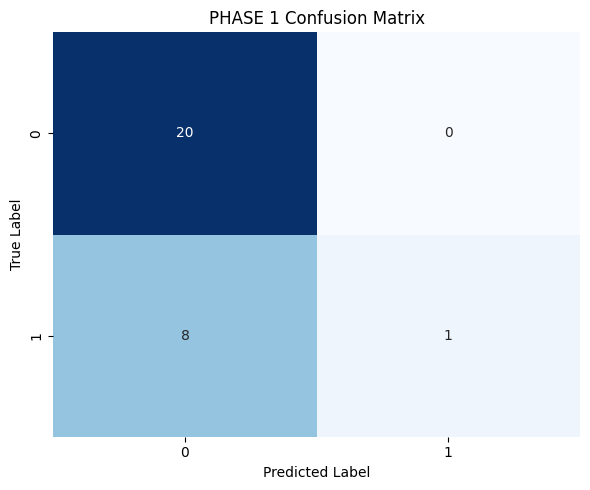


------------------------------------------------------------
TRAINING FOR PHASE 2
------------------------------------------------------------
Shape: (141, 777)
Class Distribution: [99 42]

Predicted Distribution:
[28  1]

Actual Distribution:
[20  9]

Classification Report:
              precision    recall  f1-score   support

           0       0.71      1.00      0.83        20
           1       1.00      0.11      0.20         9

    accuracy                           0.72        29
   macro avg       0.86      0.56      0.52        29
weighted avg       0.80      0.72      0.64        29

Precision Score: 1.0
Recall Score: 0.1111
F1 Score: 0.2
ROC-AUC Score: 0.7139

Confusion Matrix:
[[20  0]
 [ 8  1]]


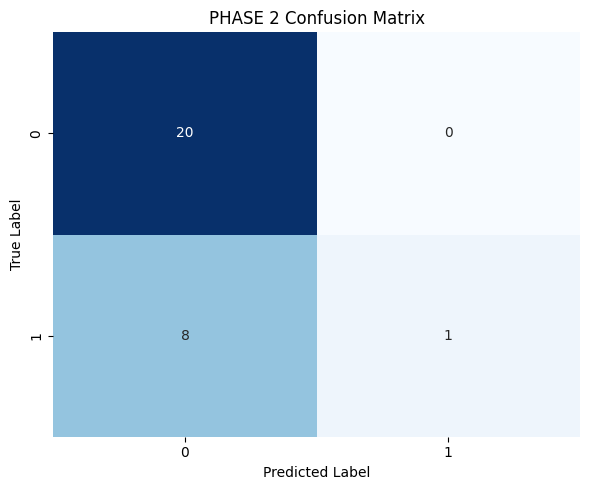


------------------------------------------------------------
TRAINING FOR PHASE 3
------------------------------------------------------------
Shape: (141, 777)
Class Distribution: [99 42]

Predicted Distribution:
[28  1]

Actual Distribution:
[20  9]

Classification Report:
              precision    recall  f1-score   support

           0       0.71      1.00      0.83        20
           1       1.00      0.11      0.20         9

    accuracy                           0.72        29
   macro avg       0.86      0.56      0.52        29
weighted avg       0.80      0.72      0.64        29

Precision Score: 1.0
Recall Score: 0.1111
F1 Score: 0.2
ROC-AUC Score: 0.5306

Confusion Matrix:
[[20  0]
 [ 8  1]]


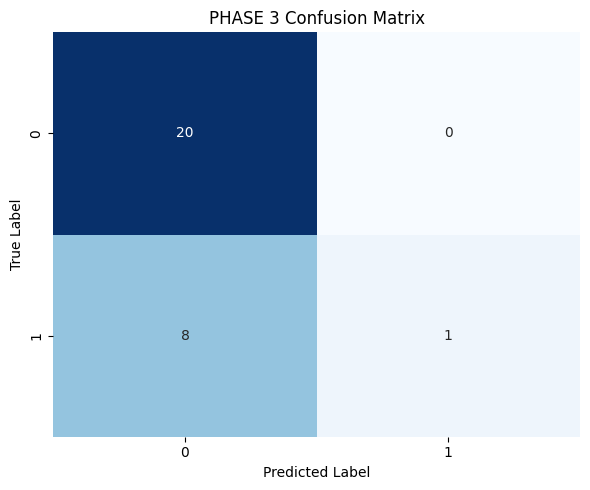


------------------------------------------------------------
FINAL ROC-AUC SCORES
------------------------------------------------------------
Phase 1 ROC-AUC: 0.6083
Phase 1 Precision: 1.0000
Phase 1 Recall: 0.1111
Phase 1 F1 Score: 0.2000

Phase 2 ROC-AUC: 0.7139
Phase 2 Precision: 1.0000
Phase 2 Recall: 0.1111
Phase 2 F1 Score: 0.2000

Phase 3 ROC-AUC: 0.5306
Phase 3 Precision: 1.0000
Phase 3 Recall: 0.1111
Phase 3 F1 Score: 0.2000


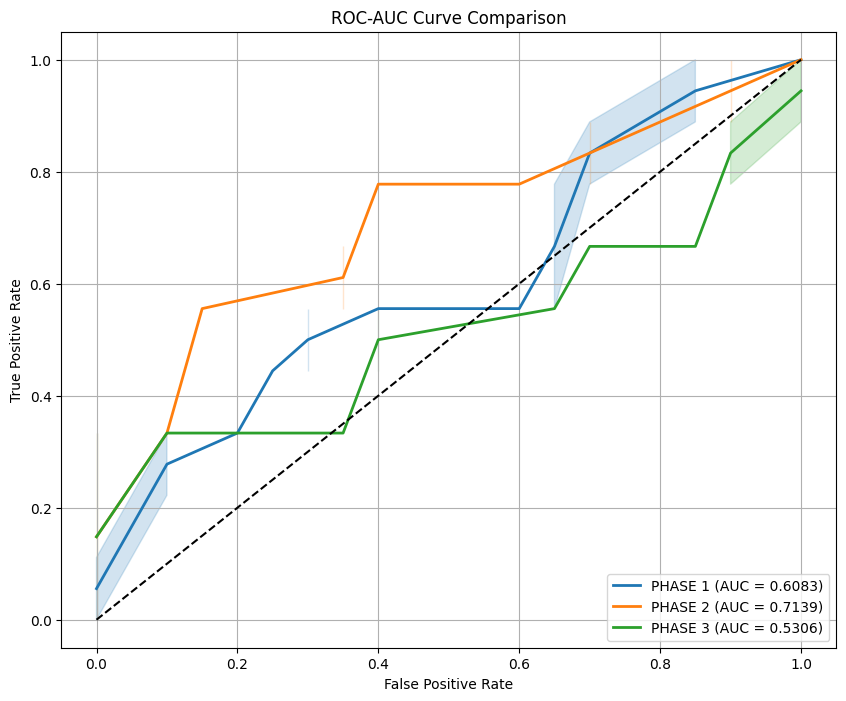

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_curve
)

# load dataset
df = pd.read_csv("../../data/text_features_phasewise.csv")

print("-" * 60)
print("DATASET INFORMATION")
print("-" * 60)

print("Dataset Shape:", df.shape)

# Normalize phase column
df["phase"] = df["phase"].astype(str).str.lower().str.strip()

print("\nAvailable Phases:")
print(df["phase"].unique())

# remove non features columns
remove_cols = [
    "participant_id",
    "phase",
    "label"
]

feature_cols = [col for col in df.columns if col not in remove_cols]

print("\nTotal Features:", len(feature_cols))

# store roc data
roc_data = {}

# training
def train_phase_model(df_phase, phase_name):

    print("\n" + "-" * 60)
    print(f"TRAINING FOR {phase_name}")
    print("-" * 60)

    # drop missing values
    df_phase = df_phase.dropna()

    # features and Labels
    X = df_phase[feature_cols]
    y = df_phase["label"]

    print("Shape:", X.shape)
    print("Class Distribution:", np.bincount(y))


    # train-test Split
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        stratify=y,
        random_state=42
    )

    # feature scaling
    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # random forest Model
    model = RandomForestClassifier(
        n_estimators=400,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    # predictions
    THRESHOLD = 0.40

    y_prob = model.predict_proba(X_test)[:, 1]

    y_pred = (y_prob > THRESHOLD).astype(int)

    # result
    print("\nPredicted Distribution:")
    print(np.bincount(y_pred))

    print("\nActual Distribution:")
    print(np.bincount(y_test))

    # classification report
    print("\nClassification Report:")
    print(classification_report(
        y_test,
        y_pred,
        zero_division=0
    ))

    # precision score
    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    print("Precision Score:", round(precision, 4))

    # recall score
    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    print("Recall Score:", round(recall, 4))

    # f1 score
    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    print("F1 Score:", round(f1, 4))

    # ROC-AUC
    roc = roc_auc_score(y_test, y_prob)

    print("ROC-AUC Score:", round(roc, 4))

    # confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    print("\nConfusion Matrix:")
    print(cm)

    # draw confusion matrix
    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False
    )

    plt.title(f"{phase_name} Confusion Matrix")

    plt.xlabel("Predicted Label")

    plt.ylabel("True Label")

    plt.tight_layout()

    plt.show()

    # roc curve values
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    roc_data[phase_name] = {
        "fpr": fpr,
        "tpr": tpr,
        "auc": roc
    }

    return model, roc, precision, recall, f1

# filter data phases
df_p1 = df[df["phase"] == "phase1"]

df_p2 = df[df["phase"] == "phase2"]

df_p3 = df[df["phase"] == "phase3"]

# model training
model_p1, roc_p1, prec_p1, rec_p1, f1_p1 = train_phase_model(
    df_p1,
    "PHASE 1"
)

model_p2, roc_p2, prec_p2, rec_p2, f1_p2 = train_phase_model(
    df_p2,
    "PHASE 2"
)

model_p3, roc_p3, prec_p3, rec_p3, f1_p3 = train_phase_model(
    df_p3,
    "PHASE 3"
)

# summary
print("\n" + "-" * 60)
print("FINAL ROC-AUC SCORES")
print("-" * 60)

print(f"Phase 1 ROC-AUC: {roc_p1:.4f}")
print(f"Phase 1 Precision: {prec_p1:.4f}")
print(f"Phase 1 Recall: {rec_p1:.4f}")
print(f"Phase 1 F1 Score: {f1_p1:.4f}")

print()

print(f"Phase 2 ROC-AUC: {roc_p2:.4f}")
print(f"Phase 2 Precision: {prec_p2:.4f}")
print(f"Phase 2 Recall: {rec_p2:.4f}")
print(f"Phase 2 F1 Score: {f1_p2:.4f}")

print()

print(f"Phase 3 ROC-AUC: {roc_p3:.4f}")
print(f"Phase 3 Precision: {prec_p3:.4f}")
print(f"Phase 3 Recall: {rec_p3:.4f}")
print(f"Phase 3 F1 Score: {f1_p3:.4f}")

# final roc auc curve
plt.figure(figsize=(10, 8))

for phase_name, values in roc_data.items():

    sns.lineplot(
        x=values["fpr"],
        y=values["tpr"],
        linewidth=2,
        label=f"{phase_name} (AUC = {values['auc']:.4f})"
    )

sns.lineplot(
    x=[0, 1],
    y=[0, 1],
    linestyle="--",
    color="black"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC-AUC Curve Comparison")

plt.legend(loc="lower right")

plt.grid(True)

plt.show()

Random Forest 5 folds

------------------------------------------------------------
DATASET INFORMATION
------------------------------------------------------------
Dataset Shape: (423, 780)

Available Phases:
<StringArray>
['phase1', 'phase2', 'phase3']
Length: 3, dtype: str

Total Features: 777

------------------------------------------------------------
TRAINING FOR PHASE 1
------------------------------------------------------------
Shape: (141, 777)
Class Distribution: [99 42]

----- Fold 1 -----
Fold ROC-AUC: 0.4556

----- Fold 2 -----
Fold ROC-AUC: 0.7812

----- Fold 3 -----
Fold ROC-AUC: 0.7531

----- Fold 4 -----
Fold ROC-AUC: 0.9375

----- Fold 5 -----
Fold ROC-AUC: 0.8041

------------------------------------------------------------
FINAL RESULTS FOR PHASE 1
------------------------------------------------------------

Fold ROC-AUC Scores:
[0.4556 0.7812 0.7531 0.9375 0.8041]

Mean Fold ROC-AUC:
0.7463

Overall ROC-AUC:
0.7143

Classification Report:
              precision    recall  f1-score   

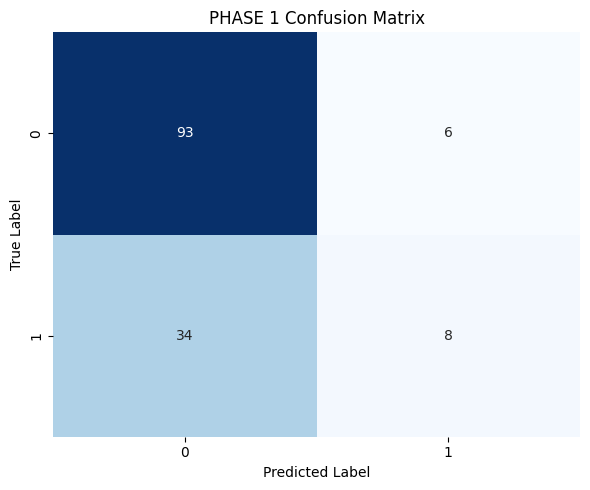


------------------------------------------------------------
TRAINING FOR PHASE 2
------------------------------------------------------------
Shape: (141, 777)
Class Distribution: [99 42]

----- Fold 1 -----
Fold ROC-AUC: 0.55

----- Fold 2 -----
Fold ROC-AUC: 0.6125

----- Fold 3 -----
Fold ROC-AUC: 0.7312

----- Fold 4 -----
Fold ROC-AUC: 0.8813

----- Fold 5 -----
Fold ROC-AUC: 0.7047

------------------------------------------------------------
FINAL RESULTS FOR PHASE 2
------------------------------------------------------------

Fold ROC-AUC Scores:
[0.55   0.6125 0.7312 0.8812 0.7047]

Mean Fold ROC-AUC:
0.6959

Overall ROC-AUC:
0.6842

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.98      0.85        99
           1       0.83      0.24      0.37        42

    accuracy                           0.76       141
   macro avg       0.79      0.61      0.61       141
weighted avg       0.78      0.76      0.71       1

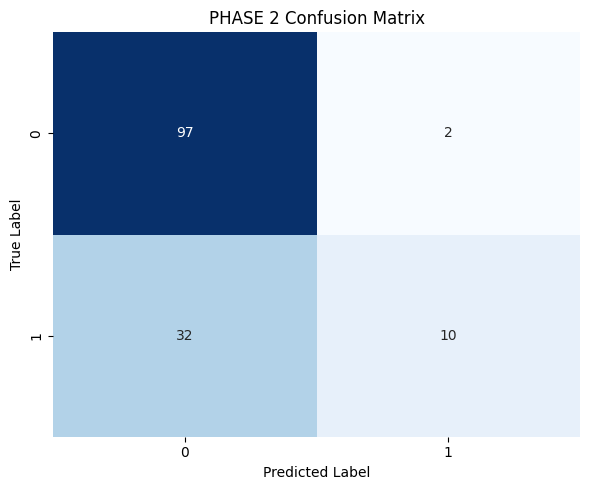


------------------------------------------------------------
TRAINING FOR PHASE 3
------------------------------------------------------------
Shape: (141, 777)
Class Distribution: [99 42]

----- Fold 1 -----
Fold ROC-AUC: 0.6917

----- Fold 2 -----
Fold ROC-AUC: 0.6875

----- Fold 3 -----
Fold ROC-AUC: 0.4781

----- Fold 4 -----
Fold ROC-AUC: 0.5469

----- Fold 5 -----
Fold ROC-AUC: 0.6754

------------------------------------------------------------
FINAL RESULTS FOR PHASE 3
------------------------------------------------------------

Fold ROC-AUC Scores:
[0.6917 0.6875 0.4781 0.5469 0.6754]

Mean Fold ROC-AUC:
0.6159

Overall ROC-AUC:
0.6132

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.98      0.83        99
           1       0.60      0.07      0.13        42

    accuracy                           0.71       141
   macro avg       0.66      0.53      0.48       141
weighted avg       0.68      0.71      0.62      

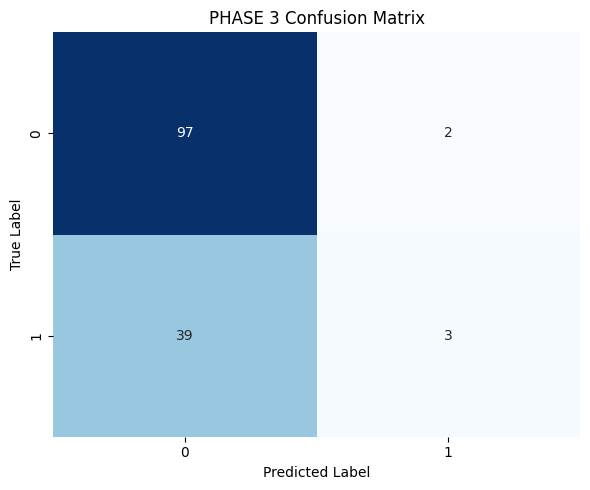


------------------------------------------------------------
FINAL ROC-AUC SCORES
------------------------------------------------------------
Phase 1 ROC-AUC: 0.7143
Phase 1 Precision: 0.5714
Phase 1 Recall: 0.1905
Phase 1 F1 Score: 0.2857

Phase 2 ROC-AUC: 0.6842
Phase 2 Precision: 0.8333
Phase 2 Recall: 0.2381
Phase 2 F1 Score: 0.3704

Phase 3 ROC-AUC: 0.6132
Phase 3 Precision: 0.6000
Phase 3 Recall: 0.0714
Phase 3 F1 Score: 0.1277


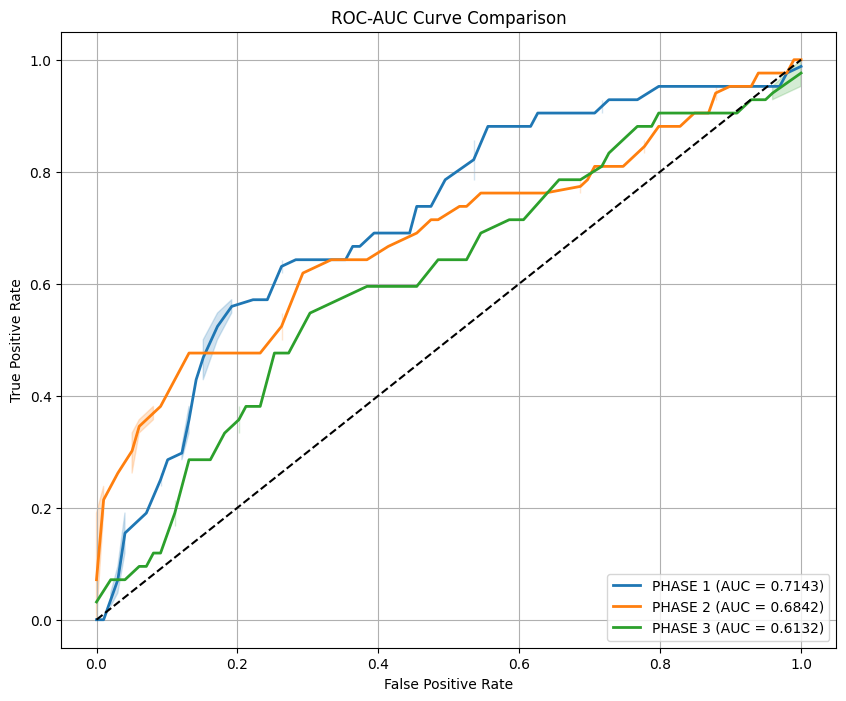

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_curve
)

# load dataset
df = pd.read_csv("../../data/text_features_phasewise.csv")

print("-" * 60)
print("DATASET INFORMATION")
print("-" * 60)

print("Dataset Shape:", df.shape)

df["phase"] = df["phase"].astype(str).str.lower().str.strip()

print("\nAvailable Phases:")
print(df["phase"].unique())

# remove non features columns
remove_cols = [
    "participant_id",
    "phase",
    "label"
]

feature_cols = [col for col in df.columns if col not in remove_cols]

print("\nTotal Features:", len(feature_cols))

# store roc data
roc_data = {}

# 5-fold RF
def train_phase_model(df_phase, phase_name):

    print("\n" + "-" * 60)
    print(f"TRAINING FOR {phase_name}")
    print("-" * 60)

    # drop missing values
    df_phase = df_phase.dropna()

    # features and Labels
    X = df_phase[feature_cols].values
    y = df_phase["label"].values

    print("Shape:", X.shape)
    print("Class Distribution:", np.bincount(y))

    # 5-fold split
    skf = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    # store all predictions
    all_probs = np.zeros(len(y))
    all_preds = np.zeros(len(y))

    fold_aucs = []

    # train each fold
    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):

        print(f"\n----- Fold {fold} -----")

        # split Data
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        # feature Scaling
        scaler = StandardScaler()

        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        # random Forest Model
        model = RandomForestClassifier(
            n_estimators=400,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        )

        # train
        model.fit(X_train, y_train)

        # predict
        THRESHOLD = 0.40

        y_prob = model.predict_proba(X_test)[:, 1]

        y_pred = (y_prob > THRESHOLD).astype(int)

        # store predictions
        all_probs[test_idx] = y_prob
        all_preds[test_idx] = y_pred

        # Fold ROC
        fold_auc = roc_auc_score(y_test, y_prob)

        fold_aucs.append(fold_auc)

        print("Fold ROC-AUC:", round(fold_auc, 4))

    # results
    overall_auc = roc_auc_score(y, all_probs)

    print("\n" + "-" * 60)
    print(f"FINAL RESULTS FOR {phase_name}")
    print("-" * 60)

    print("\nFold ROC-AUC Scores:")
    print(np.round(fold_aucs, 4))

    print("\nMean Fold ROC-AUC:")
    print(round(np.mean(fold_aucs), 4))

    print("\nOverall ROC-AUC:")
    print(round(overall_auc, 4))

    # classification reports
    print("\nClassification Report:")
    print(classification_report(
        y,
        all_preds,
        zero_division=0
    ))

    # precision score
    precision = precision_score(
        y,
        all_preds,
        zero_division=0
    )

    print("Precision Score:", round(precision, 4))

    # recall score
    recall = recall_score(
        y,
        all_preds,
        zero_division=0
    )

    print("Recall Score:", round(recall, 4))

    # f1 score
    f1 = f1_score(
        y,
        all_preds,
        zero_division=0
    )

    print("F1 Score:", round(f1, 4))

    # confusion matrix
    cm = confusion_matrix(y, all_preds)

    print("\nConfusion Matrix:")
    print(cm)

    # draw confusion matrix
    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False
    )

    plt.title(f"{phase_name} Confusion Matrix")

    plt.xlabel("Predicted Label")

    plt.ylabel("True Label")

    plt.tight_layout()

    plt.show()

    # roc curve values
    fpr, tpr, _ = roc_curve(y, all_probs)

    roc_data[phase_name] = {
        "fpr": fpr,
        "tpr": tpr,
        "auc": overall_auc
    }

    return overall_auc, precision, recall, f1

# filter data phases
df_p1 = df[df["phase"] == "phase1"]

df_p2 = df[df["phase"] == "phase2"]

df_p3 = df[df["phase"] == "phase3"]

# train models
roc_p1, prec_p1, rec_p1, f1_p1 = train_phase_model(
    df_p1,
    "PHASE 1"
)

roc_p2, prec_p2, rec_p2, f1_p2 = train_phase_model(
    df_p2,
    "PHASE 2"
)

roc_p3, prec_p3, rec_p3, f1_p3 = train_phase_model(
    df_p3,
    "PHASE 3"
)

# summary
print("\n" + "-" * 60)
print("FINAL ROC-AUC SCORES")
print("-" * 60)

print(f"Phase 1 ROC-AUC: {roc_p1:.4f}")
print(f"Phase 1 Precision: {prec_p1:.4f}")
print(f"Phase 1 Recall: {rec_p1:.4f}")
print(f"Phase 1 F1 Score: {f1_p1:.4f}")

print()

print(f"Phase 2 ROC-AUC: {roc_p2:.4f}")
print(f"Phase 2 Precision: {prec_p2:.4f}")
print(f"Phase 2 Recall: {rec_p2:.4f}")
print(f"Phase 2 F1 Score: {f1_p2:.4f}")

print()

print(f"Phase 3 ROC-AUC: {roc_p3:.4f}")
print(f"Phase 3 Precision: {prec_p3:.4f}")
print(f"Phase 3 Recall: {rec_p3:.4f}")
print(f"Phase 3 F1 Score: {f1_p3:.4f}")

# final roc auc curve
plt.figure(figsize=(10, 8))

for phase_name, values in roc_data.items():

    sns.lineplot(
        x=values["fpr"],
        y=values["tpr"],
        linewidth=2,
        label=f"{phase_name} (AUC = {values['auc']:.4f})"
    )

sns.lineplot(
    x=[0, 1],
    y=[0, 1],
    linestyle="--",
    color="black"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC-AUC Curve Comparison")

plt.legend(loc="lower right")

plt.grid(True)

plt.show()

Random Forest 10 folds

------------------------------------------------------------
DATASET INFORMATION
------------------------------------------------------------
Dataset Shape: (423, 780)

Available Phases:
<StringArray>
['phase1', 'phase2', 'phase3']
Length: 3, dtype: str

Total Features: 777

------------------------------------------------------------
TRAINING FOR PHASE 1
------------------------------------------------------------
Shape: (141, 777)
Class Distribution: [99 42]

----- Fold 1 -----
Fold ROC-AUC: 0.28

----- Fold 2 -----
Fold ROC-AUC: 0.6875

----- Fold 3 -----
Fold ROC-AUC: 0.7

----- Fold 4 -----
Fold ROC-AUC: 0.975

----- Fold 5 -----
Fold ROC-AUC: 0.65

----- Fold 6 -----
Fold ROC-AUC: 0.925

----- Fold 7 -----
Fold ROC-AUC: 0.925

----- Fold 8 -----
Fold ROC-AUC: 0.8375

----- Fold 9 -----
Fold ROC-AUC: 0.9

----- Fold 10 -----
Fold ROC-AUC: 0.8

------------------------------------------------------------
FINAL RESULTS FOR PHASE 1
----------------------------------------------------

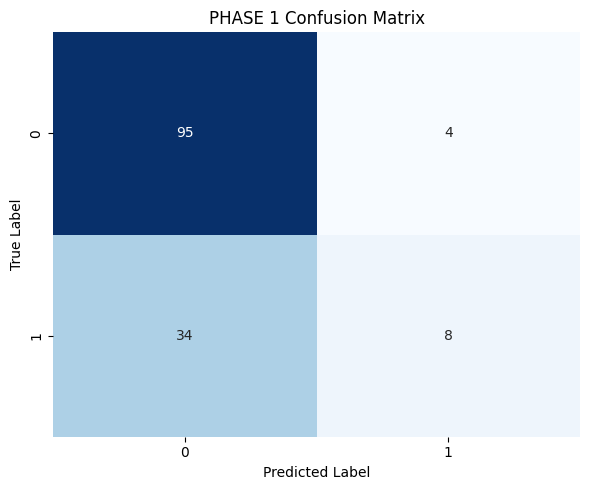


------------------------------------------------------------
TRAINING FOR PHASE 2
------------------------------------------------------------
Shape: (141, 777)
Class Distribution: [99 42]

----- Fold 1 -----
Fold ROC-AUC: 0.56

----- Fold 2 -----
Fold ROC-AUC: 0.65

----- Fold 3 -----
Fold ROC-AUC: 0.7125

----- Fold 4 -----
Fold ROC-AUC: 0.65

----- Fold 5 -----
Fold ROC-AUC: 0.85

----- Fold 6 -----
Fold ROC-AUC: 0.6875

----- Fold 7 -----
Fold ROC-AUC: 0.775

----- Fold 8 -----
Fold ROC-AUC: 0.825

----- Fold 9 -----
Fold ROC-AUC: 0.6375

----- Fold 10 -----
Fold ROC-AUC: 0.7556

------------------------------------------------------------
FINAL RESULTS FOR PHASE 2
------------------------------------------------------------

Fold ROC-AUC Scores:
[0.56   0.65   0.7125 0.65   0.85   0.6875 0.775  0.825  0.6375 0.7556]

Mean Fold ROC-AUC:
0.7103

Overall ROC-AUC:
0.6985

Classification Report:
              precision    recall  f1-score   support

           0       0.76      1.00  

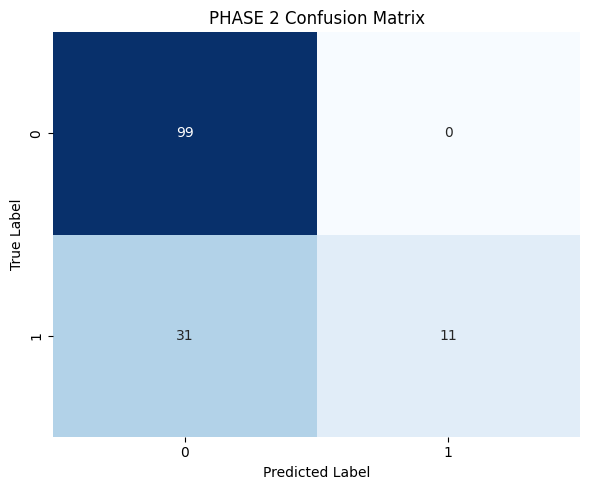


------------------------------------------------------------
TRAINING FOR PHASE 3
------------------------------------------------------------
Shape: (141, 777)
Class Distribution: [99 42]

----- Fold 1 -----
Fold ROC-AUC: 0.47

----- Fold 2 -----
Fold ROC-AUC: 0.8

----- Fold 3 -----
Fold ROC-AUC: 0.625

----- Fold 4 -----
Fold ROC-AUC: 0.4875

----- Fold 5 -----
Fold ROC-AUC: 0.45

----- Fold 6 -----
Fold ROC-AUC: 0.3625

----- Fold 7 -----
Fold ROC-AUC: 0.65

----- Fold 8 -----
Fold ROC-AUC: 0.675

----- Fold 9 -----
Fold ROC-AUC: 0.725

----- Fold 10 -----
Fold ROC-AUC: 0.7111

------------------------------------------------------------
FINAL RESULTS FOR PHASE 3
------------------------------------------------------------

Fold ROC-AUC Scores:
[0.47   0.8    0.625  0.4875 0.45   0.3625 0.65   0.675  0.725  0.7111]

Mean Fold ROC-AUC:
0.5956

Overall ROC-AUC:
0.5771

Classification Report:
              precision    recall  f1-score   support

           0       0.71      1.00    

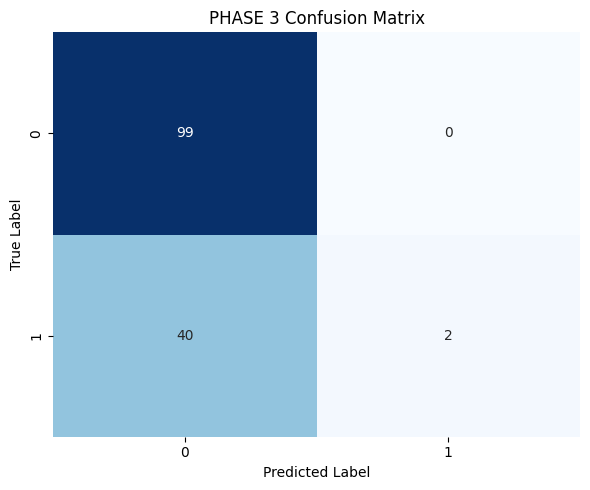


------------------------------------------------------------
FINAL ROC-AUC SCORES
------------------------------------------------------------
Phase 1 ROC-AUC: 0.7454
Phase 1 Precision: 0.6667
Phase 1 Recall: 0.1905
Phase 1 F1 Score: 0.2963

Phase 2 ROC-AUC: 0.6985
Phase 2 Precision: 1.0000
Phase 2 Recall: 0.2619
Phase 2 F1 Score: 0.4151

Phase 3 ROC-AUC: 0.5771
Phase 3 Precision: 1.0000
Phase 3 Recall: 0.0476
Phase 3 F1 Score: 0.0909


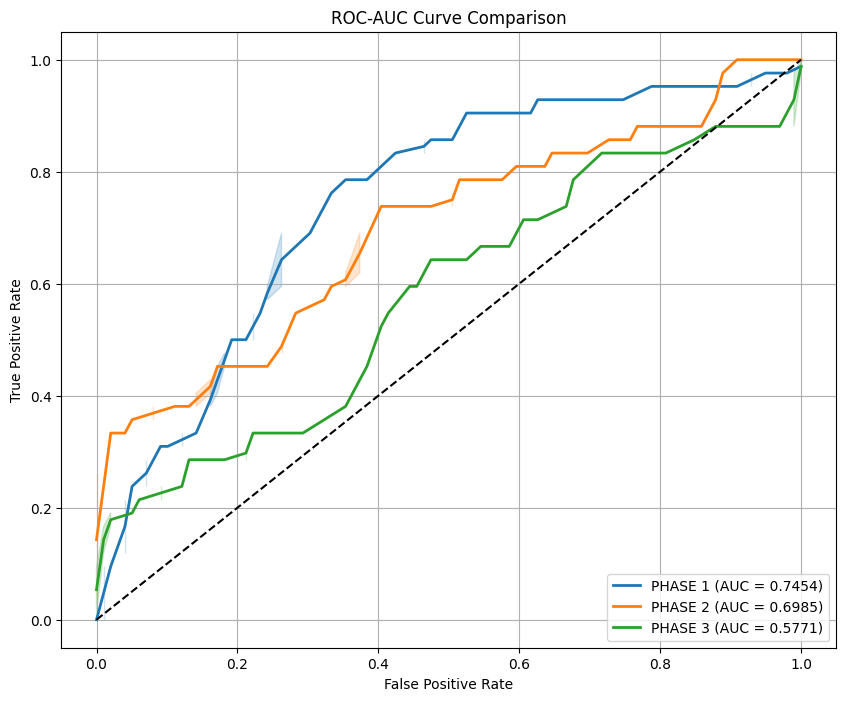

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_curve
)

# load dataset
df = pd.read_csv("../../data/text_features_phasewise.csv")

print("-" * 60)
print("DATASET INFORMATION")
print("-" * 60)

print("Dataset Shape:", df.shape)

# normalize phase column
df["phase"] = df["phase"].astype(str).str.lower().str.strip()

print("\nAvailable Phases:")
print(df["phase"].unique())

# remove non features columns
remove_cols = [
    "participant_id",
    "phase",
    "label"
]

feature_cols = [col for col in df.columns if col not in remove_cols]

print("\nTotal Features:", len(feature_cols))

# store roc data
roc_data = {}

# 10-FOLD RF
def train_phase_model(df_phase, phase_name):

    print("\n" + "-" * 60)
    print(f"TRAINING FOR {phase_name}")
    print("-" * 60)

    # drop missing values
    df_phase = df_phase.dropna()

    # features and labels
    X = df_phase[feature_cols].values
    y = df_phase["label"].values

    print("Shape:", X.shape)
    print("Class Distribution:", np.bincount(y))

    # 10-fold split
    skf = StratifiedKFold(
        n_splits=10,
        shuffle=True,
        random_state=42
    )

    # store all predictions
    all_probs = np.zeros(len(y))
    all_preds = np.zeros(len(y))

    fold_aucs = []

    # train each fold
    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):

        print(f"\n----- Fold {fold} -----")

        # split Data
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        # feature scaling
        scaler = StandardScaler()

        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        # random forest model
        model = RandomForestClassifier(
            n_estimators=400,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        )

        # train
        model.fit(X_train, y_train)

        # predict
        THRESHOLD = 0.40

        y_prob = model.predict_proba(X_test)[:, 1]

        y_pred = (y_prob > THRESHOLD).astype(int)

        # store predictions
        all_probs[test_idx] = y_prob
        all_preds[test_idx] = y_pred

        # Fold ROC
        fold_auc = roc_auc_score(y_test, y_prob)

        fold_aucs.append(fold_auc)

        print("Fold ROC-AUC:", round(fold_auc, 4))

    # results
    overall_auc = roc_auc_score(y, all_probs)

    print("\n" + "-" * 60)
    print(f"FINAL RESULTS FOR {phase_name}")
    print("-" * 60)

    print("\nFold ROC-AUC Scores:")
    print(np.round(fold_aucs, 4))

    print("\nMean Fold ROC-AUC:")
    print(round(np.mean(fold_aucs), 4))

    print("\nOverall ROC-AUC:")
    print(round(overall_auc, 4))

    # classification report
    print("\nClassification Report:")
    print(classification_report(
        y,
        all_preds,
        zero_division=0
    ))

    # precision score
    precision = precision_score(
        y,
        all_preds,
        zero_division=0
    )

    print("Precision Score:", round(precision, 4))

    # recall score
    recall = recall_score(
        y,
        all_preds,
        zero_division=0
    )

    print("Recall Score:", round(recall, 4))

    # f1 score
    f1 = f1_score(
        y,
        all_preds,
        zero_division=0
    )

    print("F1 Score:", round(f1, 4))

    # confusion matrix
    cm = confusion_matrix(y, all_preds)

    print("\nConfusion Matrix:")
    print(cm)

    # draw confusion matrix
    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False
    )

    plt.title(f"{phase_name} Confusion Matrix")

    plt.xlabel("Predicted Label")

    plt.ylabel("True Label")

    plt.tight_layout()

    plt.show()

    # roc curve values
    fpr, tpr, _ = roc_curve(y, all_probs)

    roc_data[phase_name] = {
        "fpr": fpr,
        "tpr": tpr,
        "auc": overall_auc
    }

    return overall_auc, precision, recall, f1

# filter data phases
df_p1 = df[df["phase"] == "phase1"]

df_p2 = df[df["phase"] == "phase2"]

df_p3 = df[df["phase"] == "phase3"]

# train models
roc_p1, prec_p1, rec_p1, f1_p1 = train_phase_model(
    df_p1,
    "PHASE 1"
)

roc_p2, prec_p2, rec_p2, f1_p2 = train_phase_model(
    df_p2,
    "PHASE 2"
)

roc_p3, prec_p3, rec_p3, f1_p3 = train_phase_model(
    df_p3,
    "PHASE 3"
)

# summary
print("\n" + "-" * 60)
print("FINAL ROC-AUC SCORES")
print("-" * 60)

print(f"Phase 1 ROC-AUC: {roc_p1:.4f}")
print(f"Phase 1 Precision: {prec_p1:.4f}")
print(f"Phase 1 Recall: {rec_p1:.4f}")
print(f"Phase 1 F1 Score: {f1_p1:.4f}")

print()

print(f"Phase 2 ROC-AUC: {roc_p2:.4f}")
print(f"Phase 2 Precision: {prec_p2:.4f}")
print(f"Phase 2 Recall: {rec_p2:.4f}")
print(f"Phase 2 F1 Score: {f1_p2:.4f}")

print()

print(f"Phase 3 ROC-AUC: {roc_p3:.4f}")
print(f"Phase 3 Precision: {prec_p3:.4f}")
print(f"Phase 3 Recall: {rec_p3:.4f}")
print(f"Phase 3 F1 Score: {f1_p3:.4f}")

# final roc auc curve
plt.figure(figsize=(10, 8))

for phase_name, values in roc_data.items():

    sns.lineplot(
        x=values["fpr"],
        y=values["tpr"],
        linewidth=2,
        label=f"{phase_name} (AUC = {values['auc']:.4f})"
    )

sns.lineplot(
    x=[0, 1],
    y=[0, 1],
    linestyle="--",
    color="black"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC-AUC Curve Comparison")

plt.legend(loc="lower right")

plt.grid(True)

plt.show()

XGBoost

------------------------------------------------------------
DATASET INFORMATION
------------------------------------------------------------
Dataset Shape: (423, 780)

Available Phases:
<StringArray>
['phase1', 'phase2', 'phase3']
Length: 3, dtype: str

Total Features: 777

------------------------------------------------------------
TRAINING FOR PHASE 1
------------------------------------------------------------
Original Shape: (141, 777)
Class Distribution: [99 42]
Shape After Variance Threshold: (141, 352)
Scale Pos Weight: 2.39

Predicted Distribution:
[22  7]

Actual Distribution:
[20  9]

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.80      0.76        20
           1       0.43      0.33      0.38         9

    accuracy                           0.66        29
   macro avg       0.58      0.57      0.57        29
weighted avg       0.63      0.66      0.64        29

Precision Score: 0.4286
Recall Score: 0.3333
F

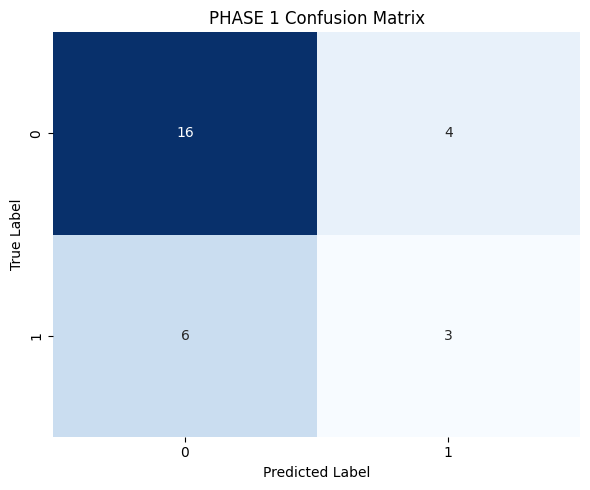


------------------------------------------------------------
TRAINING FOR PHASE 2
------------------------------------------------------------
Original Shape: (141, 777)
Class Distribution: [99 42]
Shape After Variance Threshold: (141, 312)
Scale Pos Weight: 2.39

Predicted Distribution:
[19 10]

Actual Distribution:
[20  9]

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.70      0.72        20
           1       0.40      0.44      0.42         9

    accuracy                           0.62        29
   macro avg       0.57      0.57      0.57        29
weighted avg       0.63      0.62      0.63        29

Precision Score: 0.4
Recall Score: 0.4444
F1 Score: 0.4211
ROC-AUC Score: 0.5833

Confusion Matrix:
[[14  6]
 [ 5  4]]


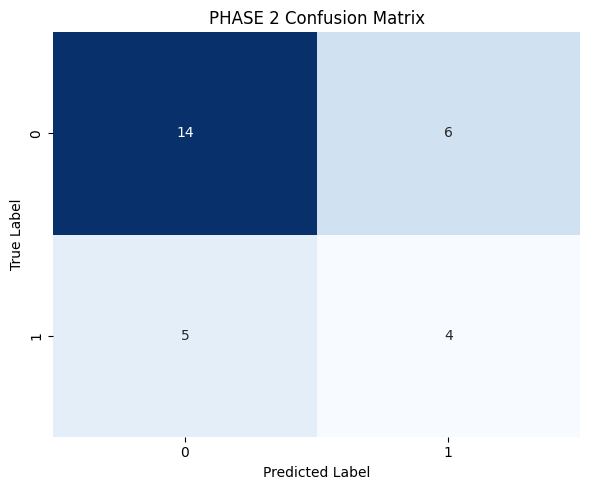


------------------------------------------------------------
TRAINING FOR PHASE 3
------------------------------------------------------------
Original Shape: (141, 777)
Class Distribution: [99 42]
Shape After Variance Threshold: (141, 316)
Scale Pos Weight: 2.39

Predicted Distribution:
[14 15]

Actual Distribution:
[20  9]

Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.45      0.53        20
           1       0.27      0.44      0.33         9

    accuracy                           0.45        29
   macro avg       0.45      0.45      0.43        29
weighted avg       0.53      0.45      0.47        29

Precision Score: 0.2667
Recall Score: 0.4444
F1 Score: 0.3333
ROC-AUC Score: 0.5278

Confusion Matrix:
[[ 9 11]
 [ 5  4]]


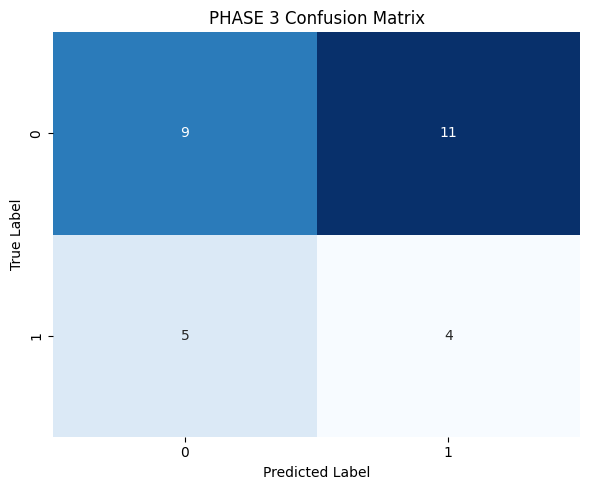


------------------------------------------------------------
FINAL ROC-AUC SCORES
------------------------------------------------------------
Phase 1 ROC-AUC: 0.7389
Phase 1 Precision: 0.4286
Phase 1 Recall: 0.3333
Phase 1 F1 Score: 0.3750

Phase 2 ROC-AUC: 0.5833
Phase 2 Precision: 0.4000
Phase 2 Recall: 0.4444
Phase 2 F1 Score: 0.4211

Phase 3 ROC-AUC: 0.5278
Phase 3 Precision: 0.2667
Phase 3 Recall: 0.4444
Phase 3 F1 Score: 0.3333


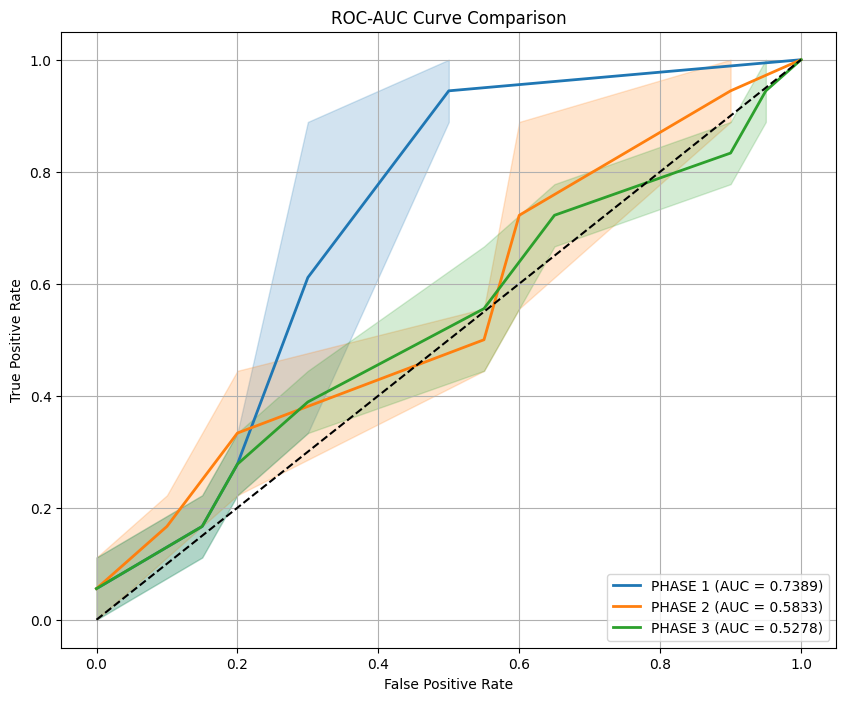

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold

from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_curve
)

from xgboost import XGBClassifier

# load dataset
df = pd.read_csv("../../data/text_features_phasewise.csv")

print("-" * 60)
print("DATASET INFORMATION")
print("-" * 60)
print("Dataset Shape:", df.shape)

# normalize phase column
df["phase"] = df["phase"].astype(str).str.lower().str.strip()

print("\nAvailable Phases:")
print(df["phase"].unique())

# remove non feature columns
remove_cols = [
    "participant_id",
    "phase",
    "label"
]

feature_cols = [col for col in df.columns if col not in remove_cols]

print("\nTotal Features:", len(feature_cols))

# store roc data
roc_data = {}

# training function
def train_phase_model(df_phase, phase_name):

    print("\n" + "-" * 60)
    print(f"TRAINING FOR {phase_name}")
    print("-" * 60)

    # drop missing values
    df_phase = df_phase.dropna()

    # features and labels
    X = df_phase[feature_cols]
    y = df_phase["label"]

    print("Original Shape:", X.shape)
    print("Class Distribution:", np.bincount(y))

    # remove low variance features
    selector = VarianceThreshold(
        threshold=0.0001
    )

    X = selector.fit_transform(X)

    print("Shape After Variance Threshold:", X.shape)

    # train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        stratify=y,
        random_state=42
    )

    # class imbalance handling
    neg = np.sum(y_train == 0)
    pos = np.sum(y_train == 1)

    scale_pos_weight = neg / pos

    print("Scale Pos Weight:", round(scale_pos_weight, 2))

    # XGBoost Model
    model = XGBClassifier(

        # Core
        objective="binary:logistic",
        eval_metric="auc",

        # Smaller trees prevent overfit
        n_estimators=250,
        max_depth=3,

        # Learning
        learning_rate=0.05,

        # Sampling
        subsample=0.7,
        colsample_bytree=0.6,

        # Regularization
        min_child_weight=5,
        gamma=2,

        # Imbalance handling
        scale_pos_weight=scale_pos_weight,

        # Misc
        random_state=42,
        n_jobs=-1
    )

    # train model
    model.fit(X_train, y_train)

    # probabilities
    y_prob = model.predict_proba(X_test)[:, 1]
    THRESHOLD = 0.35

    y_pred = (y_prob > THRESHOLD).astype(int)

    # results
    print("\nPredicted Distribution:")
    print(np.bincount(y_pred))

    print("\nActual Distribution:")
    print(np.bincount(y_test))

    # classification report
    print("\nClassification Report:")
    print(classification_report(
        y_test,
        y_pred,
        zero_division=0
    ))

    # precision score
    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    print("Precision Score:", round(precision, 4))

    # recall score
    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    print("Recall Score:", round(recall, 4))

    # f1 score
    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    print("F1 Score:", round(f1, 4))

    # ROC-AUC
    roc = roc_auc_score(y_test, y_prob)

    print("ROC-AUC Score:", round(roc, 4))

    # confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    print("\nConfusion Matrix:")
    print(cm)

    # draw confusion matrix
    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False
    )

    plt.title(f"{phase_name} Confusion Matrix")

    plt.xlabel("Predicted Label")

    plt.ylabel("True Label")

    plt.tight_layout()

    plt.show()

    # roc curve values
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    roc_data[phase_name] = {
        "fpr": fpr,
        "tpr": tpr,
        "auc": roc
    }

    return model, roc, precision, recall, f1

# filter data phases
df_p1 = df[df["phase"] == "phase1"]

df_p2 = df[df["phase"] == "phase2"]

df_p3 = df[df["phase"] == "phase3"]

# train models
model_p1, roc_p1, prec_p1, rec_p1, f1_p1 = train_phase_model(
    df_p1,
    "PHASE 1"
)

model_p2, roc_p2, prec_p2, rec_p2, f1_p2 = train_phase_model(
    df_p2,
    "PHASE 2"
)

model_p3, roc_p3, prec_p3, rec_p3, f1_p3 = train_phase_model(
    df_p3,
    "PHASE 3"
)

# summary
print("\n" + "-" * 60)
print("FINAL ROC-AUC SCORES")
print("-" * 60)

print(f"Phase 1 ROC-AUC: {roc_p1:.4f}")
print(f"Phase 1 Precision: {prec_p1:.4f}")
print(f"Phase 1 Recall: {rec_p1:.4f}")
print(f"Phase 1 F1 Score: {f1_p1:.4f}")

print()

print(f"Phase 2 ROC-AUC: {roc_p2:.4f}")
print(f"Phase 2 Precision: {prec_p2:.4f}")
print(f"Phase 2 Recall: {rec_p2:.4f}")
print(f"Phase 2 F1 Score: {f1_p2:.4f}")

print()

print(f"Phase 3 ROC-AUC: {roc_p3:.4f}")
print(f"Phase 3 Precision: {prec_p3:.4f}")
print(f"Phase 3 Recall: {rec_p3:.4f}")
print(f"Phase 3 F1 Score: {f1_p3:.4f}")

# final roc auc curve
plt.figure(figsize=(10, 8))

for phase_name, values in roc_data.items():

    sns.lineplot(
        x=values["fpr"],
        y=values["tpr"],
        linewidth=2,
        label=f"{phase_name} (AUC = {values['auc']:.4f})"
    )

sns.lineplot(
    x=[0, 1],
    y=[0, 1],
    linestyle="--",
    color="black"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC-AUC Curve Comparison")

plt.legend(loc="lower right")

plt.grid(True)

plt.show()

XGBoost 5 folds

------------------------------------------------------------
DATASET INFORMATION
------------------------------------------------------------
Dataset Shape: (423, 780)

Available Phases:
<StringArray>
['phase1', 'phase2', 'phase3']
Length: 3, dtype: str

Total Features: 777

------------------------------------------------------------
TRAINING FOR PHASE 1
------------------------------------------------------------
Original Shape: (141, 777)
Class Distribution: [99 42]
Shape After Variance Threshold: (141, 352)
Scale Pos Weight: 2.36

----- Fold 1 -----
Fold ROC-AUC: 0.3944

----- Fold 2 -----
Fold ROC-AUC: 0.7625

----- Fold 3 -----
Fold ROC-AUC: 0.6938

----- Fold 4 -----
Fold ROC-AUC: 0.7375

----- Fold 5 -----
Fold ROC-AUC: 0.6959

------------------------------------------------------------
FINAL RESULTS FOR PHASE 1
------------------------------------------------------------

Fold ROC-AUC Scores:
[0.3944 0.7625 0.6938 0.7375 0.6959]

Mean Fold ROC-AUC:
0.6568

Overall ROC-AUC:
0.

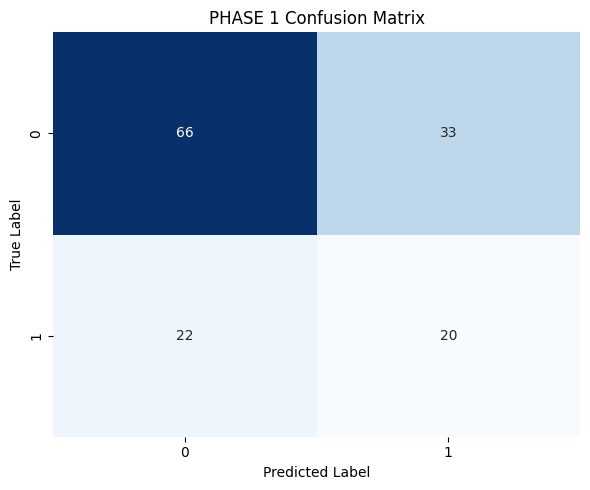


------------------------------------------------------------
TRAINING FOR PHASE 2
------------------------------------------------------------
Original Shape: (141, 777)
Class Distribution: [99 42]
Shape After Variance Threshold: (141, 312)
Scale Pos Weight: 2.36

----- Fold 1 -----
Fold ROC-AUC: 0.6056

----- Fold 2 -----
Fold ROC-AUC: 0.5938

----- Fold 3 -----
Fold ROC-AUC: 0.6125

----- Fold 4 -----
Fold ROC-AUC: 0.8187

----- Fold 5 -----
Fold ROC-AUC: 0.4795

------------------------------------------------------------
FINAL RESULTS FOR PHASE 2
------------------------------------------------------------

Fold ROC-AUC Scores:
[0.6056 0.5938 0.6125 0.8188 0.4795]

Mean Fold ROC-AUC:
0.622

Overall ROC-AUC:
0.6301

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.74      0.75        99
           1       0.43      0.48      0.45        42

    accuracy                           0.66       141
   macro avg       0.60      

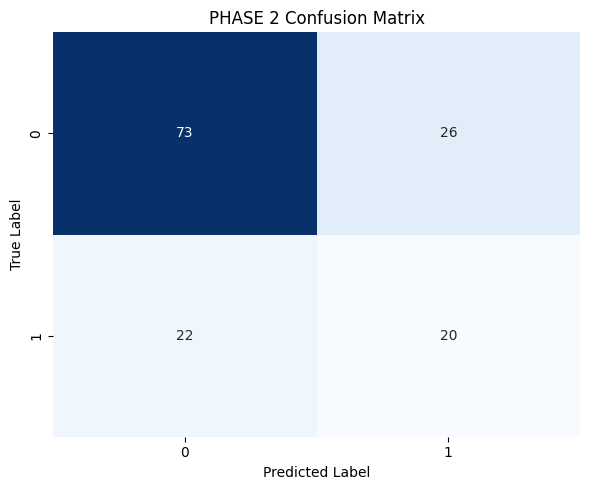


------------------------------------------------------------
TRAINING FOR PHASE 3
------------------------------------------------------------
Original Shape: (141, 777)
Class Distribution: [99 42]
Shape After Variance Threshold: (141, 316)
Scale Pos Weight: 2.36

----- Fold 1 -----
Fold ROC-AUC: 0.7056

----- Fold 2 -----
Fold ROC-AUC: 0.575

----- Fold 3 -----
Fold ROC-AUC: 0.5687

----- Fold 4 -----
Fold ROC-AUC: 0.5188

----- Fold 5 -----
Fold ROC-AUC: 0.655

------------------------------------------------------------
FINAL RESULTS FOR PHASE 3
------------------------------------------------------------

Fold ROC-AUC Scores:
[0.7056 0.575  0.5688 0.5188 0.655 ]

Mean Fold ROC-AUC:
0.6046

Overall ROC-AUC:
0.6041

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.61      0.67        99
           1       0.35      0.50      0.41        42

    accuracy                           0.57       141
   macro avg       0.55      0

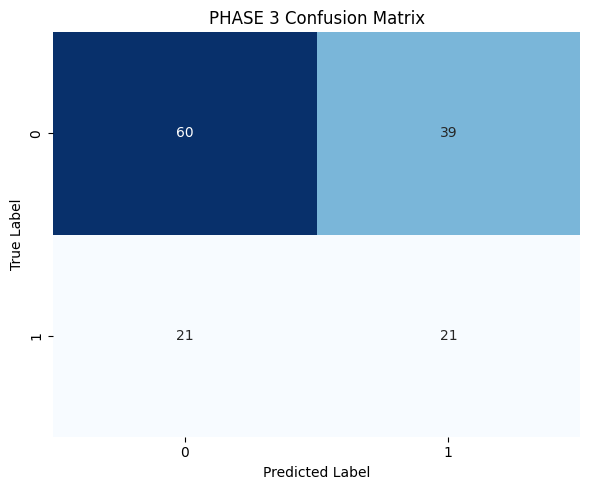


------------------------------------------------------------
FINAL ROC-AUC SCORES
------------------------------------------------------------
Phase 1 ROC-AUC: 0.6496
Phase 1 Precision: 0.3774
Phase 1 Recall: 0.4762
Phase 1 F1 Score: 0.4211

Phase 2 ROC-AUC: 0.6301
Phase 2 Precision: 0.4348
Phase 2 Recall: 0.4762
Phase 2 F1 Score: 0.4545

Phase 3 ROC-AUC: 0.6041
Phase 3 Precision: 0.3500
Phase 3 Recall: 0.5000
Phase 3 F1 Score: 0.4118


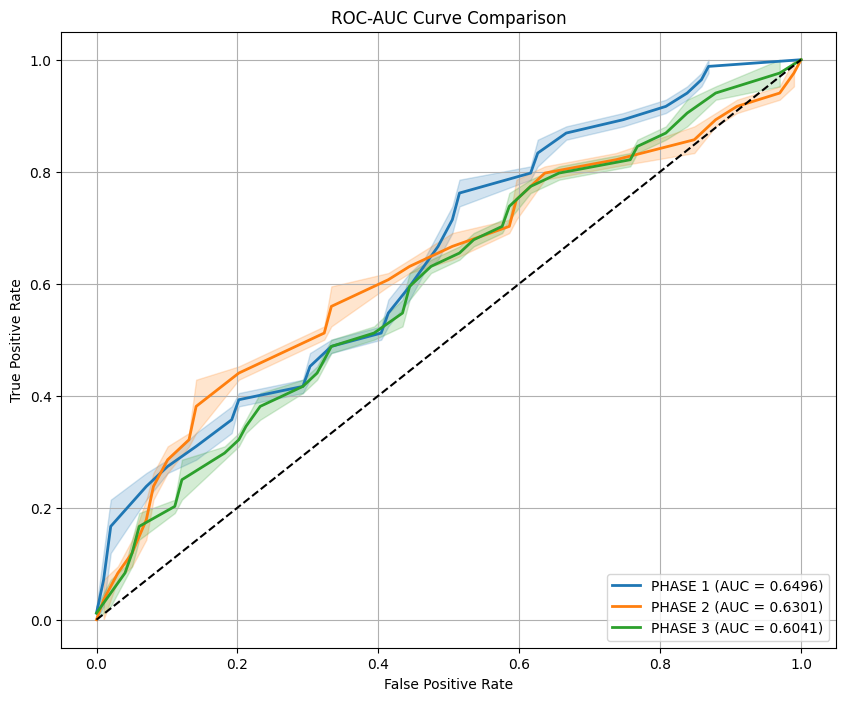

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.feature_selection import VarianceThreshold

from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_curve
)

from xgboost import XGBClassifier

# load dataset
df = pd.read_csv("../../data/text_features_phasewise.csv")

print("-" * 60)
print("DATASET INFORMATION")
print("-" * 60)

print("Dataset Shape:", df.shape)

# normalize phase column
df["phase"] = df["phase"].astype(str).str.lower().str.strip()

print("\nAvailable Phases:")
print(df["phase"].unique())

# remove non feature columns
remove_cols = [
    "participant_id",
    "phase",
    "label"
]

feature_cols = [col for col in df.columns if col not in remove_cols]

print("\nTotal Features:", len(feature_cols))

# store roc data
roc_data = {}

# training function
def train_phase_model(df_phase, phase_name):

    print("\n" + "-" * 60)
    print(f"TRAINING FOR {phase_name}")
    print("-" * 60)

    # drop missing values
    df_phase = df_phase.dropna()

    # features & labels
    X = df_phase[feature_cols]
    y = df_phase["label"].values

    print("Original Shape:", X.shape)
    print("Class Distribution:", np.bincount(y))

    # remove low variance features
    selector = VarianceThreshold(
        threshold=0.0001
    )

    X = selector.fit_transform(X)

    print("Shape After Variance Threshold:", X.shape)

    # class imbalance
    neg = np.sum(y == 0)
    pos = np.sum(y == 1)

    scale_pos_weight = neg / pos

    print("Scale Pos Weight:", round(scale_pos_weight, 2))

    # 5-fold stratified cv
    skf = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    # store predictions
    all_probs = np.zeros(len(y))
    all_preds = np.zeros(len(y))

    fold_aucs = []

    # train each fold
    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):

        print(f"\n----- Fold {fold} -----")

        X_train, X_test = X[train_idx], X[test_idx]

        y_train, y_test = y[train_idx], y[test_idx]

        # xgboost model
        model = XGBClassifier(

            objective="binary:logistic",
            eval_metric="auc",

            # trees
            n_estimators=250,
            max_depth=3,

            # learning
            learning_rate=0.05,

            # sampling
            subsample=0.7,
            colsample_bytree=0.6,

            # regularization
            min_child_weight=5,
            gamma=2,

            # imbalance
            scale_pos_weight=scale_pos_weight,

            # misc
            random_state=42,
            n_jobs=-1
        )

        # train
        model.fit(X_train, y_train)

        # predict
        y_prob = model.predict_proba(X_test)[:, 1]

        THRESHOLD = 0.35

        y_pred = (y_prob > THRESHOLD).astype(int)

        # store fold predictions
        all_probs[test_idx] = y_prob
        all_preds[test_idx] = y_pred

        # fold auc
        fold_auc = roc_auc_score(y_test, y_prob)

        fold_aucs.append(fold_auc)

        print("Fold ROC-AUC:", round(fold_auc, 4))

    # final results
    overall_auc = roc_auc_score(y, all_probs)

    print("\n" + "-" * 60)
    print(f"FINAL RESULTS FOR {phase_name}")
    print("-" * 60)

    print("\nFold ROC-AUC Scores:")
    print(np.round(fold_aucs, 4))

    print("\nMean Fold ROC-AUC:")
    print(round(np.mean(fold_aucs), 4))

    print("\nOverall ROC-AUC:")
    print(round(overall_auc, 4))

    # classification report
    print("\nClassification Report:")
    print(classification_report(
        y,
        all_preds,
        zero_division=0
    ))

    # precision score
    precision = precision_score(
        y,
        all_preds,
        zero_division=0
    )

    print("Precision Score:", round(precision, 4))

    # recall score
    recall = recall_score(
        y,
        all_preds,
        zero_division=0
    )

    print("Recall Score:", round(recall, 4))

    # f1 score
    f1 = f1_score(
        y,
        all_preds,
        zero_division=0
    )

    print("F1 Score:", round(f1, 4))

    # confusion matrix
    cm = confusion_matrix(y, all_preds)

    print("\nConfusion Matrix:")
    print(cm)

    # draw confusion matrix
    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False
    )

    plt.title(f"{phase_name} Confusion Matrix")

    plt.xlabel("Predicted Label")

    plt.ylabel("True Label")

    plt.tight_layout()

    plt.show()

    # roc curve values
    fpr, tpr, _ = roc_curve(y, all_probs)

    roc_data[phase_name] = {
        "fpr": fpr,
        "tpr": tpr,
        "auc": overall_auc
    }

    return overall_auc, precision, recall, f1

# filter data phase-wise
df_p1 = df[df["phase"] == "phase1"]

df_p2 = df[df["phase"] == "phase2"]

df_p3 = df[df["phase"] == "phase3"]

# train models
roc_p1, prec_p1, rec_p1, f1_p1 = train_phase_model(
    df_p1,
    "PHASE 1"
)

roc_p2, prec_p2, rec_p2, f1_p2 = train_phase_model(
    df_p2,
    "PHASE 2"
)

roc_p3, prec_p3, rec_p3, f1_p3 = train_phase_model(
    df_p3,
    "PHASE 3"
)

# final summary
print("\n" + "-" * 60)
print("FINAL ROC-AUC SCORES")
print("-" * 60)

print(f"Phase 1 ROC-AUC: {roc_p1:.4f}")
print(f"Phase 1 Precision: {prec_p1:.4f}")
print(f"Phase 1 Recall: {rec_p1:.4f}")
print(f"Phase 1 F1 Score: {f1_p1:.4f}")

print()

print(f"Phase 2 ROC-AUC: {roc_p2:.4f}")
print(f"Phase 2 Precision: {prec_p2:.4f}")
print(f"Phase 2 Recall: {rec_p2:.4f}")
print(f"Phase 2 F1 Score: {f1_p2:.4f}")

print()

print(f"Phase 3 ROC-AUC: {roc_p3:.4f}")
print(f"Phase 3 Precision: {prec_p3:.4f}")
print(f"Phase 3 Recall: {rec_p3:.4f}")
print(f"Phase 3 F1 Score: {f1_p3:.4f}")

# final roc auc curve
plt.figure(figsize=(10, 8))

for phase_name, values in roc_data.items():

    sns.lineplot(
        x=values["fpr"],
        y=values["tpr"],
        linewidth=2,
        label=f"{phase_name} (AUC = {values['auc']:.4f})"
    )

sns.lineplot(
    x=[0, 1],
    y=[0, 1],
    linestyle="--",
    color="black"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC-AUC Curve Comparison")

plt.legend(loc="lower right")

plt.grid(True)

plt.show()

XGBoost 10 folds

------------------------------------------------------------
DATASET INFORMATION
------------------------------------------------------------
Dataset Shape: (423, 780)

Available Phases:
<StringArray>
['phase1', 'phase2', 'phase3']
Length: 3, dtype: str

Total Features: 777

------------------------------------------------------------
TRAINING FOR PHASE 1
------------------------------------------------------------
Original Shape: (141, 777)
Class Distribution: [99 42]
Shape After Variance Threshold: (141, 352)
Scale Pos Weight: 2.36

----- Fold 1 -----
Fold ROC-AUC: 0.4

----- Fold 2 -----
Fold ROC-AUC: 0.5

----- Fold 3 -----
Fold ROC-AUC: 0.825

----- Fold 4 -----
Fold ROC-AUC: 0.925

----- Fold 5 -----
Fold ROC-AUC: 0.75

----- Fold 6 -----
Fold ROC-AUC: 0.725

----- Fold 7 -----
Fold ROC-AUC: 0.85

----- Fold 8 -----
Fold ROC-AUC: 0.7

----- Fold 9 -----
Fold ROC-AUC: 0.575

----- Fold 10 -----
Fold ROC-AUC: 0.7778

------------------------------------------------------------
FINA

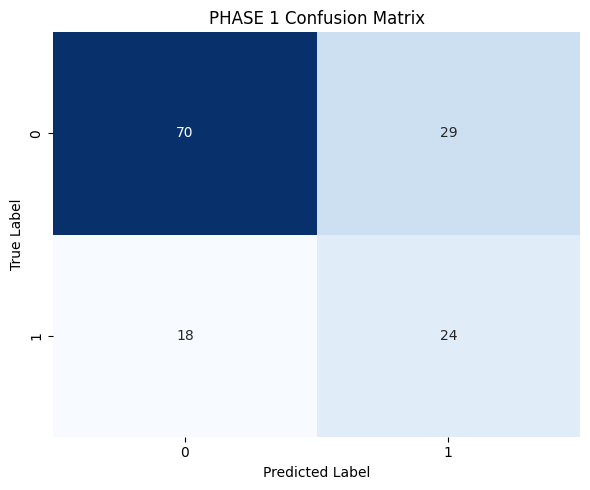


------------------------------------------------------------
TRAINING FOR PHASE 2
------------------------------------------------------------
Original Shape: (141, 777)
Class Distribution: [99 42]
Shape After Variance Threshold: (141, 312)
Scale Pos Weight: 2.36

----- Fold 1 -----
Fold ROC-AUC: 0.74

----- Fold 2 -----
Fold ROC-AUC: 0.625

----- Fold 3 -----
Fold ROC-AUC: 0.575

----- Fold 4 -----
Fold ROC-AUC: 0.425

----- Fold 5 -----
Fold ROC-AUC: 0.825

----- Fold 6 -----
Fold ROC-AUC: 0.725

----- Fold 7 -----
Fold ROC-AUC: 0.725

----- Fold 8 -----
Fold ROC-AUC: 0.725

----- Fold 9 -----
Fold ROC-AUC: 0.675

----- Fold 10 -----
Fold ROC-AUC: 0.6667

------------------------------------------------------------
FINAL RESULTS FOR PHASE 2
------------------------------------------------------------

Fold ROC-AUC Scores:
[0.74   0.625  0.575  0.425  0.825  0.725  0.725  0.725  0.675  0.6667]

Mean Fold ROC-AUC:
0.6707

Overall ROC-AUC:
0.6494

Classification Report:
              p

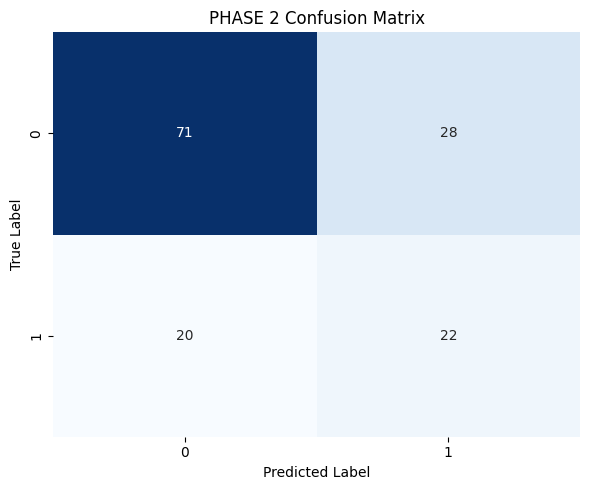


------------------------------------------------------------
TRAINING FOR PHASE 3
------------------------------------------------------------
Original Shape: (141, 777)
Class Distribution: [99 42]
Shape After Variance Threshold: (141, 316)
Scale Pos Weight: 2.36

----- Fold 1 -----
Fold ROC-AUC: 0.64

----- Fold 2 -----
Fold ROC-AUC: 0.925

----- Fold 3 -----
Fold ROC-AUC: 0.6

----- Fold 4 -----
Fold ROC-AUC: 0.45

----- Fold 5 -----
Fold ROC-AUC: 0.325

----- Fold 6 -----
Fold ROC-AUC: 0.7

----- Fold 7 -----
Fold ROC-AUC: 0.45

----- Fold 8 -----
Fold ROC-AUC: 0.675

----- Fold 9 -----
Fold ROC-AUC: 0.775

----- Fold 10 -----
Fold ROC-AUC: 0.5556

------------------------------------------------------------
FINAL RESULTS FOR PHASE 3
------------------------------------------------------------

Fold ROC-AUC Scores:
[0.64   0.925  0.6    0.45   0.325  0.7    0.45   0.675  0.775  0.5556]

Mean Fold ROC-AUC:
0.6096

Overall ROC-AUC:
0.6085

Classification Report:
              precisi

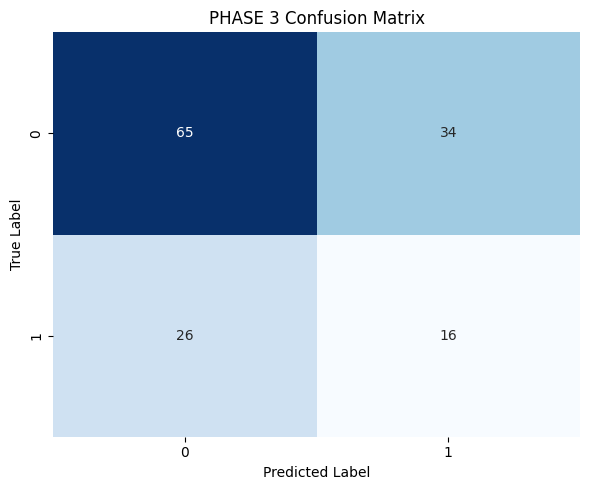


------------------------------------------------------------
FINAL ROC-AUC SCORES
------------------------------------------------------------
Phase 1 ROC-AUC: 0.6859
Phase 1 Precision: 0.4528
Phase 1 Recall: 0.5714
Phase 1 F1 Score: 0.5053

Phase 2 ROC-AUC: 0.6494
Phase 2 Precision: 0.4400
Phase 2 Recall: 0.5238
Phase 2 F1 Score: 0.4783

Phase 3 ROC-AUC: 0.6085
Phase 3 Precision: 0.3200
Phase 3 Recall: 0.3810
Phase 3 F1 Score: 0.3478


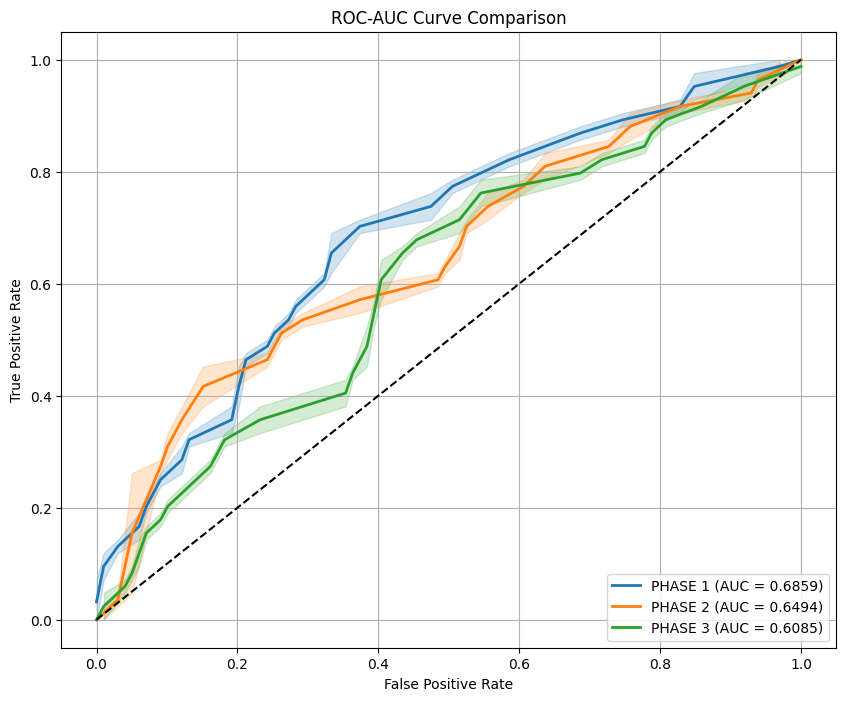

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.feature_selection import VarianceThreshold

from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_curve
)

from xgboost import XGBClassifier

# load dataset
df = pd.read_csv("../../data/text_features_phasewise.csv")

print("-" * 60)
print("DATASET INFORMATION")
print("-" * 60)

print("Dataset Shape:", df.shape)

# normalize phase column
df["phase"] = df["phase"].astype(str).str.lower().str.strip()

print("\nAvailable Phases:")
print(df["phase"].unique())

# remove non-feature columns
remove_cols = [
    "participant_id",
    "phase",
    "label"
]

feature_cols = [col for col in df.columns if col not in remove_cols]

print("\nTotal Features:", len(feature_cols))

# store roc data
roc_data = {}

# training function
def train_phase_model(df_phase, phase_name):

    print("\n" + "-" * 60)
    print(f"TRAINING FOR {phase_name}")
    print("-" * 60)

    # drop missing values
    df_phase = df_phase.dropna()

    # features & labels
    X = df_phase[feature_cols]
    y = df_phase["label"].values

    print("Original Shape:", X.shape)
    print("Class Distribution:", np.bincount(y))

    # remove low variance features
    selector = VarianceThreshold(
        threshold=0.0001
    )

    X = selector.fit_transform(X)

    print("Shape After Variance Threshold:", X.shape)

    # class imbalance
    neg = np.sum(y == 0)
    pos = np.sum(y == 1)

    scale_pos_weight = neg / pos

    print("Scale Pos Weight:", round(scale_pos_weight, 2))

    # 10-fold stratified cv
    skf = StratifiedKFold(
        n_splits=10,
        shuffle=True,
        random_state=42
    )

    # store predictions
    all_probs = np.zeros(len(y))
    all_preds = np.zeros(len(y))

    fold_aucs = []

    # train each fold
    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):

        print(f"\n----- Fold {fold} -----")

        X_train, X_test = X[train_idx], X[test_idx]

        y_train, y_test = y[train_idx], y[test_idx]

        # xgboost model
        model = XGBClassifier(

            objective="binary:logistic",
            eval_metric="auc",

            # trees
            n_estimators=250,
            max_depth=3,

            # learning
            learning_rate=0.05,

            # sampling
            subsample=0.7,
            colsample_bytree=0.6,

            # regularization
            min_child_weight=5,
            gamma=2,

            # imbalance
            scale_pos_weight=scale_pos_weight,

            # misc
            random_state=42,
            n_jobs=-1
        )

        # train
        model.fit(X_train, y_train)

        # predict
        y_prob = model.predict_proba(X_test)[:, 1]

        THRESHOLD = 0.35

        y_pred = (y_prob > THRESHOLD).astype(int)

        # store fold predictions
        all_probs[test_idx] = y_prob
        all_preds[test_idx] = y_pred

        # fold auc
        fold_auc = roc_auc_score(y_test, y_prob)

        fold_aucs.append(fold_auc)

        print("Fold ROC-AUC:", round(fold_auc, 4))

    # final results
    overall_auc = roc_auc_score(y, all_probs)

    print("\n" + "-" * 60)
    print(f"FINAL RESULTS FOR {phase_name}")
    print("-" * 60)

    print("\nFold ROC-AUC Scores:")
    print(np.round(fold_aucs, 4))

    print("\nMean Fold ROC-AUC:")
    print(round(np.mean(fold_aucs), 4))

    print("\nOverall ROC-AUC:")
    print(round(overall_auc, 4))

    # classification report
    print("\nClassification Report:")
    print(classification_report(
        y,
        all_preds,
        zero_division=0
    ))

    # precision score
    precision = precision_score(
        y,
        all_preds,
        zero_division=0
    )

    print("Precision Score:", round(precision, 4))

    # recall score
    recall = recall_score(
        y,
        all_preds,
        zero_division=0
    )

    print("Recall Score:", round(recall, 4))

    # f1 score
    f1 = f1_score(
        y,
        all_preds,
        zero_division=0
    )

    print("F1 Score:", round(f1, 4))

    # confusion matrix
    cm = confusion_matrix(y, all_preds)

    print("\nConfusion Matrix:")
    print(cm)

    # draw confusion matrix
    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False
    )

    plt.title(f"{phase_name} Confusion Matrix")

    plt.xlabel("Predicted Label")

    plt.ylabel("True Label")

    plt.tight_layout()

    plt.show()

    # roc curve values
    fpr, tpr, _ = roc_curve(y, all_probs)

    roc_data[phase_name] = {
        "fpr": fpr,
        "tpr": tpr,
        "auc": overall_auc
    }

    return overall_auc, precision, recall, f1

# filter data phase-wise
df_p1 = df[df["phase"] == "phase1"]

df_p2 = df[df["phase"] == "phase2"]

df_p3 = df[df["phase"] == "phase3"]

# train models
roc_p1, prec_p1, rec_p1, f1_p1 = train_phase_model(
    df_p1,
    "PHASE 1"
)

roc_p2, prec_p2, rec_p2, f1_p2 = train_phase_model(
    df_p2,
    "PHASE 2"
)

roc_p3, prec_p3, rec_p3, f1_p3 = train_phase_model(
    df_p3,
    "PHASE 3"
)

# final summary
print("\n" + "-" * 60)
print("FINAL ROC-AUC SCORES")
print("-" * 60)

print(f"Phase 1 ROC-AUC: {roc_p1:.4f}")
print(f"Phase 1 Precision: {prec_p1:.4f}")
print(f"Phase 1 Recall: {rec_p1:.4f}")
print(f"Phase 1 F1 Score: {f1_p1:.4f}")

print()

print(f"Phase 2 ROC-AUC: {roc_p2:.4f}")
print(f"Phase 2 Precision: {prec_p2:.4f}")
print(f"Phase 2 Recall: {rec_p2:.4f}")
print(f"Phase 2 F1 Score: {f1_p2:.4f}")

print()

print(f"Phase 3 ROC-AUC: {roc_p3:.4f}")
print(f"Phase 3 Precision: {prec_p3:.4f}")
print(f"Phase 3 Recall: {rec_p3:.4f}")
print(f"Phase 3 F1 Score: {f1_p3:.4f}")

# final roc auc curve
plt.figure(figsize=(10, 8))

for phase_name, values in roc_data.items():

    sns.lineplot(
        x=values["fpr"],
        y=values["tpr"],
        linewidth=2,
        label=f"{phase_name} (AUC = {values['auc']:.4f})"
    )

sns.lineplot(
    x=[0, 1],
    y=[0, 1],
    linestyle="--",
    color="black"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC-AUC Curve Comparison")

plt.legend(loc="lower right")

plt.grid(True)

plt.show()

SVM

------------------------------------------------------------
DATASET INFORMATION
------------------------------------------------------------
Dataset Shape: (423, 780)

Available Phases:
<StringArray>
['phase1', 'phase2', 'phase3']
Length: 3, dtype: str

Total Features: 777

------------------------------------------------------------
TRAINING FOR PHASE 1
------------------------------------------------------------
Original Shape: (141, 777)
Class Distribution: [99 42]

Shape After Variance Threshold: (141, 8)
Shape After SelectKBest: (141, 8)

Probability Range:
Min: 0.15258636509779322
Max: 0.3677908849026237
Mean: 0.2988667533511449

Predicted Distribution:
[ 4 25]

Actual Distribution:
[20  9]

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.15      0.25        20
           1       0.32      0.89      0.47         9

    accuracy                           0.38        29
   macro avg       0.54      0.52      0.36        

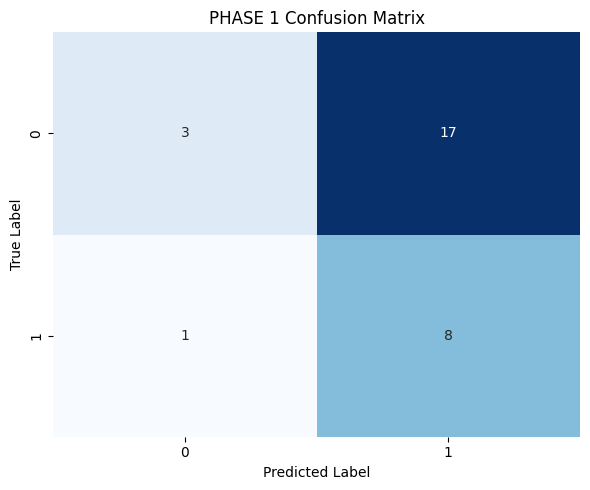


------------------------------------------------------------
TRAINING FOR PHASE 2
------------------------------------------------------------
Original Shape: (141, 777)
Class Distribution: [99 42]

Shape After Variance Threshold: (141, 8)
Shape After SelectKBest: (141, 8)

Probability Range:
Min: 0.2566109962321135
Max: 0.3817100624703648
Mean: 0.3021772381903835

Predicted Distribution:
[ 0 29]

Actual Distribution:
[20  9]

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        20
           1       0.31      1.00      0.47         9

    accuracy                           0.31        29
   macro avg       0.16      0.50      0.24        29
weighted avg       0.10      0.31      0.15        29

Precision Score: 0.3103
Recall Score: 1.0
F1 Score: 0.4737
ROC-AUC Score: 0.4167

Confusion Matrix:
[[ 0 20]
 [ 0  9]]


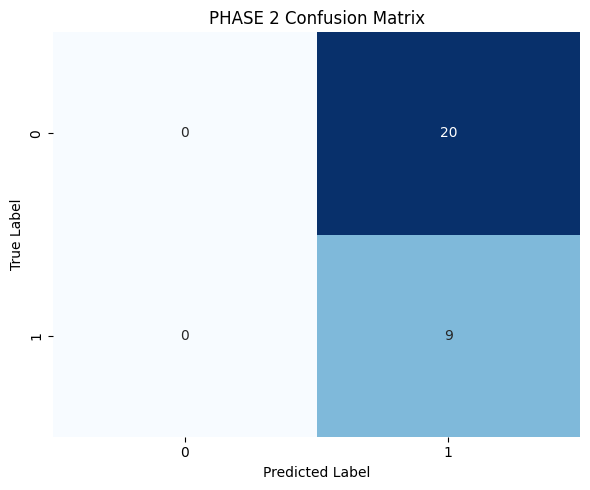


------------------------------------------------------------
TRAINING FOR PHASE 3
------------------------------------------------------------
Original Shape: (141, 777)
Class Distribution: [99 42]

Shape After Variance Threshold: (141, 8)
Shape After SelectKBest: (141, 8)

Probability Range:
Min: 0.2051822488249379
Max: 0.3676429377583265
Mean: 0.2853888006717074

Predicted Distribution:
[ 6 23]

Actual Distribution:
[20  9]

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.20      0.31        20
           1       0.30      0.78      0.44         9

    accuracy                           0.38        29
   macro avg       0.49      0.49      0.37        29
weighted avg       0.55      0.38      0.35        29

Precision Score: 0.3043
Recall Score: 0.7778
F1 Score: 0.4375
ROC-AUC Score: 0.5444

Confusion Matrix:
[[ 4 16]
 [ 2  7]]


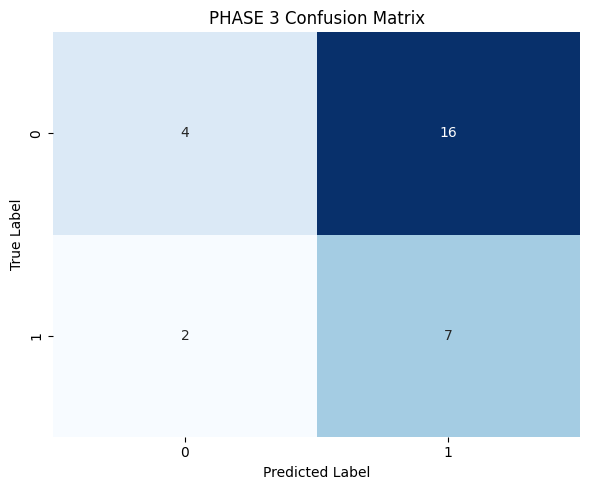


------------------------------------------------------------
FINAL ROC-AUC SCORES
------------------------------------------------------------
Phase 1 ROC-AUC: 0.5111
Phase 1 Precision: 0.3200
Phase 1 Recall: 0.8889
Phase 1 F1 Score: 0.4706

Phase 2 ROC-AUC: 0.4167
Phase 2 Precision: 0.3103
Phase 2 Recall: 1.0000
Phase 2 F1 Score: 0.4737

Phase 3 ROC-AUC: 0.5444
Phase 3 Precision: 0.3043
Phase 3 Recall: 0.7778
Phase 3 F1 Score: 0.4375


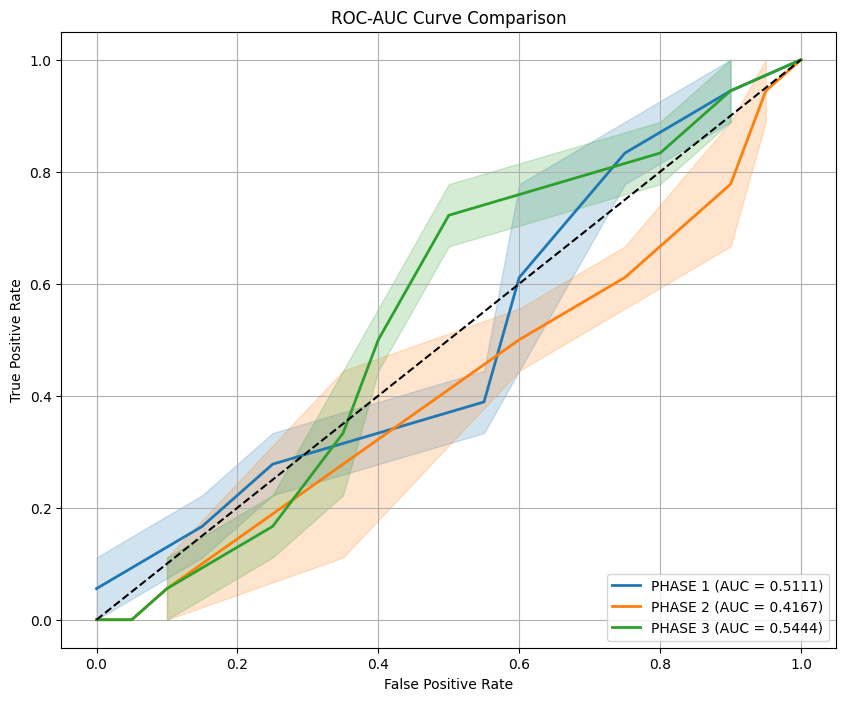

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.feature_selection import (
    VarianceThreshold,
    SelectKBest,
    mutual_info_classif
)

from sklearn.svm import SVC

from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_curve
)

# load dataset

df = pd.read_csv("../../data/text_features_phasewise.csv")

print("-" * 60)
print("DATASET INFORMATION")
print("-" * 60)

print("Dataset Shape:", df.shape)

# normalize phase column

df["phase"] = (
    df["phase"]
    .astype(str)
    .str.lower()
    .str.strip()
)

print("\nAvailable Phases:")
print(df["phase"].unique())

# remove non-feature columns

remove_cols = [
    "participant_id",
    "phase",
    "label"
]

feature_cols = [
    col for col in df.columns
    if col not in remove_cols
]

print("\nTotal Features:", len(feature_cols))

# store roc data

roc_data = {}

# training function

def train_phase_model(df_phase, phase_name):

    print("\n" + "-" * 60)
    print(f"TRAINING FOR {phase_name}")
    print("-" * 60)

    # drop missing values

    df_phase = df_phase.dropna()

    # features & labels

    X = df_phase[feature_cols]

    y = df_phase["label"].values

    print("Original Shape:", X.shape)

    print("Class Distribution:", np.bincount(y))

    # remove low variance features

    variance_selector = VarianceThreshold(
        threshold=0.001
    )

    X = variance_selector.fit_transform(X)

    print("\nShape After Variance Threshold:", X.shape)

    # feature selection

    kbest_selector = SelectKBest(
        score_func=mutual_info_classif,
        k=min(160, X.shape[1])
    )

    X = kbest_selector.fit_transform(X, y)

    print("Shape After SelectKBest:", X.shape)

    # train test split

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        stratify=y,
        random_state=42
    )

    # feature scaling

    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)

    X_test = scaler.transform(X_test)

    # svm model

    model = SVC(

        kernel="linear",

        probability=True,

        class_weight="balanced",

        C=0.35,

        random_state=42
    )

    # train model

    model.fit(X_train, y_train)

    # predict probabilities

    y_prob = model.predict_proba(X_test)[:, 1]

    # debug probability range

    print("\nProbability Range:")
    print("Min:", np.min(y_prob))
    print("Max:", np.max(y_prob))
    print("Mean:", np.mean(y_prob))

    # optimized threshold

    THRESHOLD = 0.25

    y_pred = (y_prob > THRESHOLD).astype(int)

    # results

    print("\nPredicted Distribution:")
    print(np.bincount(y_pred))

    print("\nActual Distribution:")
    print(np.bincount(y_test))

    # classification report

    print("\nClassification Report:")

    print(classification_report(
        y_test,
        y_pred,
        zero_division=0
    ))

    # precision score

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    print("Precision Score:", round(precision, 4))

    # recall score

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    print("Recall Score:", round(recall, 4))

    # f1 score

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    print("F1 Score:", round(f1, 4))

    # roc-auc

    roc = roc_auc_score(y_test, y_prob)

    print("ROC-AUC Score:", round(roc, 4))

    # confusion matrix

    cm = confusion_matrix(y_test, y_pred)

    print("\nConfusion Matrix:")
    print(cm)

    # draw confusion matrix

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False
    )

    plt.title(f"{phase_name} Confusion Matrix")

    plt.xlabel("Predicted Label")

    plt.ylabel("True Label")

    plt.tight_layout()

    plt.show()

    # roc curve

    fpr, tpr, _ = roc_curve(
        y_test,
        y_prob
    )

    roc_data[phase_name] = {
        "fpr": fpr,
        "tpr": tpr,
        "auc": roc
    }

    return model, roc, precision, recall, f1

# filter phase-wise data

df_p1 = df[df["phase"] == "phase1"]

df_p2 = df[df["phase"] == "phase2"]

df_p3 = df[df["phase"] == "phase3"]

# train models

model_p1, roc_p1, prec_p1, rec_p1, f1_p1 = train_phase_model(
    df_p1,
    "PHASE 1"
)

model_p2, roc_p2, prec_p2, rec_p2, f1_p2 = train_phase_model(
    df_p2,
    "PHASE 2"
)

model_p3, roc_p3, prec_p3, rec_p3, f1_p3 = train_phase_model(
    df_p3,
    "PHASE 3"
)

# final summary

print("\n" + "-" * 60)
print("FINAL ROC-AUC SCORES")
print("-" * 60)

print(f"Phase 1 ROC-AUC: {roc_p1:.4f}")
print(f"Phase 1 Precision: {prec_p1:.4f}")
print(f"Phase 1 Recall: {rec_p1:.4f}")
print(f"Phase 1 F1 Score: {f1_p1:.4f}")

print()

print(f"Phase 2 ROC-AUC: {roc_p2:.4f}")
print(f"Phase 2 Precision: {prec_p2:.4f}")
print(f"Phase 2 Recall: {rec_p2:.4f}")
print(f"Phase 2 F1 Score: {f1_p2:.4f}")

print()

print(f"Phase 3 ROC-AUC: {roc_p3:.4f}")
print(f"Phase 3 Precision: {prec_p3:.4f}")
print(f"Phase 3 Recall: {rec_p3:.4f}")
print(f"Phase 3 F1 Score: {f1_p3:.4f}")

# final roc curve

plt.figure(figsize=(10, 8))

for phase_name, values in roc_data.items():

    sns.lineplot(
        x=values["fpr"],
        y=values["tpr"],
        linewidth=2,
        label=f"{phase_name} (AUC = {values['auc']:.4f})"
    )

sns.lineplot(
    x=[0, 1],
    y=[0, 1],
    linestyle="--",
    color="black"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC-AUC Curve Comparison")

plt.legend(loc="lower right")

plt.grid(True)

plt.show()

SVM 5 folds

------------------------------------------------------------
DATASET INFORMATION
------------------------------------------------------------
Dataset Shape: (423, 780)

Available Phases:
<StringArray>
['phase1', 'phase2', 'phase3']
Length: 3, dtype: str

Total Features: 777

------------------------------------------------------------
TRAINING FOR PHASE 1
------------------------------------------------------------
Original Shape: (141, 777)
Class Distribution: [99 42]
Shape After Variance Threshold: (141, 8)

----- Fold 1 -----
Fold ROC-AUC: 0.7389

----- Fold 2 -----
Fold ROC-AUC: 0.625

----- Fold 3 -----
Fold ROC-AUC: 0.2688

----- Fold 4 -----
Fold ROC-AUC: 0.5875

----- Fold 5 -----
Fold ROC-AUC: 0.4971

------------------------------------------------------------
FINAL RESULTS FOR PHASE 1
------------------------------------------------------------

Fold ROC-AUC Scores:
[0.7389 0.625  0.2688 0.5875 0.4971]

Mean Fold ROC-AUC:
0.5434

Overall ROC-AUC:
0.5842

Classification Repor

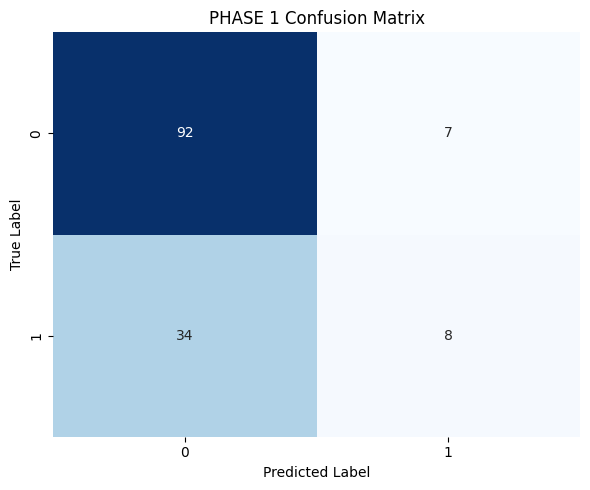


------------------------------------------------------------
TRAINING FOR PHASE 2
------------------------------------------------------------
Original Shape: (141, 777)
Class Distribution: [99 42]
Shape After Variance Threshold: (141, 8)

----- Fold 1 -----
Fold ROC-AUC: 0.5333

----- Fold 2 -----
Fold ROC-AUC: 0.4

----- Fold 3 -----
Fold ROC-AUC: 0.5562

----- Fold 4 -----
Fold ROC-AUC: 0.525

----- Fold 5 -----
Fold ROC-AUC: 0.4386

------------------------------------------------------------
FINAL RESULTS FOR PHASE 2
------------------------------------------------------------

Fold ROC-AUC Scores:
[0.5333 0.4    0.5562 0.525  0.4386]

Mean Fold ROC-AUC:
0.4906

Overall ROC-AUC:
0.4805

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.89      0.78        99
           1       0.27      0.10      0.14        42

    accuracy                           0.65       141
   macro avg       0.48      0.49      0.46       141
wei

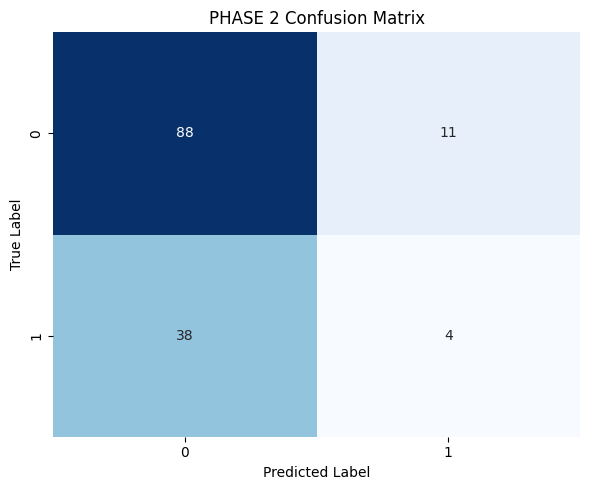


------------------------------------------------------------
TRAINING FOR PHASE 3
------------------------------------------------------------
Original Shape: (141, 777)
Class Distribution: [99 42]
Shape After Variance Threshold: (141, 8)

----- Fold 1 -----
Fold ROC-AUC: 0.5667

----- Fold 2 -----
Fold ROC-AUC: 0.3938

----- Fold 3 -----
Fold ROC-AUC: 0.5312

----- Fold 4 -----
Fold ROC-AUC: 0.45

----- Fold 5 -----
Fold ROC-AUC: 0.538

------------------------------------------------------------
FINAL RESULTS FOR PHASE 3
------------------------------------------------------------

Fold ROC-AUC Scores:
[0.5667 0.3938 0.5312 0.45   0.538 ]

Mean Fold ROC-AUC:
0.4959

Overall ROC-AUC:
0.481

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.82      0.74        99
           1       0.14      0.07      0.10        42

    accuracy                           0.60       141
   macro avg       0.41      0.44      0.42       141
wei

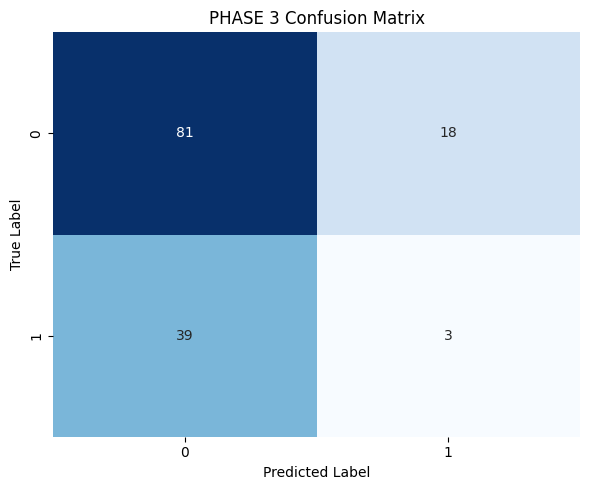


------------------------------------------------------------
FINAL ROC-AUC SCORES
------------------------------------------------------------
Phase 1 ROC-AUC: 0.5842
Phase 1 Precision: 0.5333
Phase 1 Recall: 0.1905
Phase 1 F1 Score: 0.2807

Phase 2 ROC-AUC: 0.4805
Phase 2 Precision: 0.2667
Phase 2 Recall: 0.0952
Phase 2 F1 Score: 0.1404

Phase 3 ROC-AUC: 0.4810
Phase 3 Precision: 0.1429
Phase 3 Recall: 0.0714
Phase 3 F1 Score: 0.0952


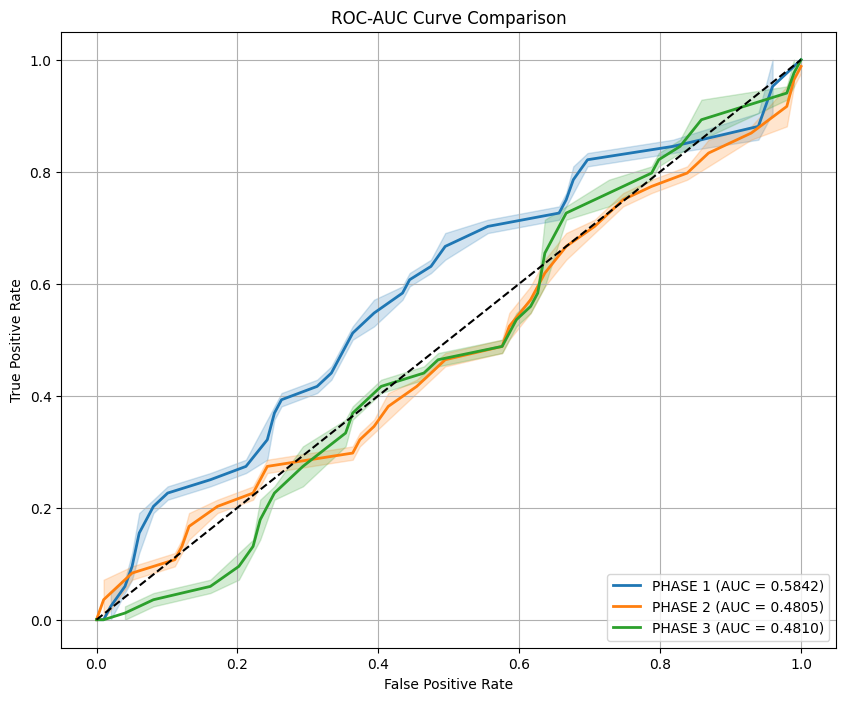

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold

from sklearn.svm import SVC

from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_curve
)

# load dataset
df = pd.read_csv("../../data/text_features_phasewise.csv")

print("-" * 60)
print("DATASET INFORMATION")
print("-" * 60)

print("Dataset Shape:", df.shape)

# normalize phase column
df["phase"] = df["phase"].astype(str).str.lower().str.strip()

print("\nAvailable Phases:")
print(df["phase"].unique())

# remove non-feature columns
remove_cols = [
    "participant_id",
    "phase",
    "label"
]

feature_cols = [col for col in df.columns if col not in remove_cols]

print("\nTotal Features:", len(feature_cols))

# store roc data
roc_data = {}

# training function
def train_phase_model(df_phase, phase_name):

    print("\n" + "-" * 60)
    print(f"TRAINING FOR {phase_name}")
    print("-" * 60)

    # drop missing values
    df_phase = df_phase.dropna()

    # features & labels
    X = df_phase[feature_cols]
    y = df_phase["label"].values

    print("Original Shape:", X.shape)
    print("Class Distribution:", np.bincount(y))

    # remove low variance features
    selector = VarianceThreshold(
        threshold=0.001
    )

    X = selector.fit_transform(X)

    print("Shape After Variance Threshold:", X.shape)

    # 5-fold stratified cv
    skf = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    # store predictions
    all_probs = np.zeros(len(y))
    all_preds = np.zeros(len(y))

    fold_aucs = []

    # train each fold
    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):

        print(f"\n----- Fold {fold} -----")

        X_train, X_test = X[train_idx], X[test_idx]

        y_train, y_test = y[train_idx], y[test_idx]

        # feature scaling
        scaler = StandardScaler()

        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        # svm model
        model = SVC(

            kernel="linear",

            probability=True,

            class_weight="balanced",

            C=0.5,

            random_state=42
        )

        # train model
        model.fit(X_train, y_train)

        # predict
        y_prob = model.predict_proba(X_test)[:, 1]

        THRESHOLD = 0.35

        y_pred = (y_prob > THRESHOLD).astype(int)

        # store predictions
        all_probs[test_idx] = y_prob
        all_preds[test_idx] = y_pred

        # fold roc-auc
        fold_auc = roc_auc_score(y_test, y_prob)

        fold_aucs.append(fold_auc)

        print("Fold ROC-AUC:", round(fold_auc, 4))

    # final results
    overall_auc = roc_auc_score(y, all_probs)

    print("\n" + "-" * 60)
    print(f"FINAL RESULTS FOR {phase_name}")
    print("-" * 60)

    print("\nFold ROC-AUC Scores:")
    print(np.round(fold_aucs, 4))

    print("\nMean Fold ROC-AUC:")
    print(round(np.mean(fold_aucs), 4))

    print("\nOverall ROC-AUC:")
    print(round(overall_auc, 4))

    # classification report
    print("\nClassification Report:")
    print(classification_report(
        y,
        all_preds,
        zero_division=0
    ))

    # precision score
    precision = precision_score(
        y,
        all_preds,
        zero_division=0
    )

    print("Precision Score:", round(precision, 4))

    # recall score
    recall = recall_score(
        y,
        all_preds,
        zero_division=0
    )

    print("Recall Score:", round(recall, 4))

    # f1 score
    f1 = f1_score(
        y,
        all_preds,
        zero_division=0
    )

    print("F1 Score:", round(f1, 4))

    # confusion matrix
    cm = confusion_matrix(y, all_preds)

    print("\nConfusion Matrix:")
    print(cm)

    # draw confusion matrix
    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False
    )

    plt.title(f"{phase_name} Confusion Matrix")

    plt.xlabel("Predicted Label")

    plt.ylabel("True Label")

    plt.tight_layout()

    plt.show()

    # roc curve values
    fpr, tpr, _ = roc_curve(y, all_probs)

    roc_data[phase_name] = {
        "fpr": fpr,
        "tpr": tpr,
        "auc": overall_auc
    }

    return overall_auc, precision, recall, f1

# filter data phase-wise
df_p1 = df[df["phase"] == "phase1"]

df_p2 = df[df["phase"] == "phase2"]

df_p3 = df[df["phase"] == "phase3"]

# train models
roc_p1, prec_p1, rec_p1, f1_p1 = train_phase_model(
    df_p1,
    "PHASE 1"
)

roc_p2, prec_p2, rec_p2, f1_p2 = train_phase_model(
    df_p2,
    "PHASE 2"
)

roc_p3, prec_p3, rec_p3, f1_p3 = train_phase_model(
    df_p3,
    "PHASE 3"
)

# final summary
print("\n" + "-" * 60)
print("FINAL ROC-AUC SCORES")
print("-" * 60)

print(f"Phase 1 ROC-AUC: {roc_p1:.4f}")
print(f"Phase 1 Precision: {prec_p1:.4f}")
print(f"Phase 1 Recall: {rec_p1:.4f}")
print(f"Phase 1 F1 Score: {f1_p1:.4f}")

print()

print(f"Phase 2 ROC-AUC: {roc_p2:.4f}")
print(f"Phase 2 Precision: {prec_p2:.4f}")
print(f"Phase 2 Recall: {rec_p2:.4f}")
print(f"Phase 2 F1 Score: {f1_p2:.4f}")

print()

print(f"Phase 3 ROC-AUC: {roc_p3:.4f}")
print(f"Phase 3 Precision: {prec_p3:.4f}")
print(f"Phase 3 Recall: {rec_p3:.4f}")
print(f"Phase 3 F1 Score: {f1_p3:.4f}")

# final roc auc curve
plt.figure(figsize=(10, 8))

for phase_name, values in roc_data.items():

    sns.lineplot(
        x=values["fpr"],
        y=values["tpr"],
        linewidth=2,
        label=f"{phase_name} (AUC = {values['auc']:.4f})"
    )

sns.lineplot(
    x=[0, 1],
    y=[0, 1],
    linestyle="--",
    color="black"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC-AUC Curve Comparison")

plt.legend(loc="lower right")

plt.grid(True)

plt.show()

SVM 10 folds

------------------------------------------------------------
DATASET INFORMATION
------------------------------------------------------------
Dataset Shape: (423, 780)

Available Phases:
<StringArray>
['phase1', 'phase2', 'phase3']
Length: 3, dtype: str

Total Features: 777

------------------------------------------------------------
TRAINING FOR PHASE 1
------------------------------------------------------------
Original Shape: (141, 777)
Class Distribution: [99 42]
Shape After Variance Threshold: (141, 8)

----- Fold 1 -----
Fold ROC-AUC: 0.74

----- Fold 2 -----
Fold ROC-AUC: 0.725

----- Fold 3 -----
Fold ROC-AUC: 0.5

----- Fold 4 -----
Fold ROC-AUC: 0.25

----- Fold 5 -----
Fold ROC-AUC: 0.725

----- Fold 6 -----
Fold ROC-AUC: 0.75

----- Fold 7 -----
Fold ROC-AUC: 0.55

----- Fold 8 -----
Fold ROC-AUC: 0.625

----- Fold 9 -----
Fold ROC-AUC: 0.3

----- Fold 10 -----
Fold ROC-AUC: 0.4667

------------------------------------------------------------
FINAL RESULTS FOR PHASE 1
---

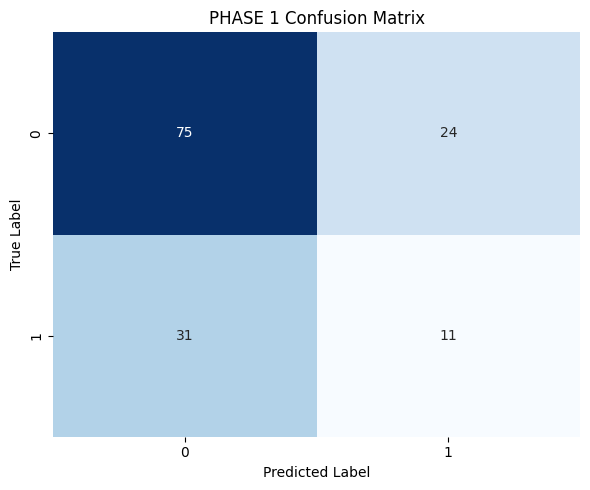


------------------------------------------------------------
TRAINING FOR PHASE 2
------------------------------------------------------------
Original Shape: (141, 777)
Class Distribution: [99 42]
Shape After Variance Threshold: (141, 8)

----- Fold 1 -----
Fold ROC-AUC: 0.4

----- Fold 2 -----
Fold ROC-AUC: 0.4

----- Fold 3 -----
Fold ROC-AUC: 0.35

----- Fold 4 -----
Fold ROC-AUC: 0.3

----- Fold 5 -----
Fold ROC-AUC: 0.65

----- Fold 6 -----
Fold ROC-AUC: 0.6

----- Fold 7 -----
Fold ROC-AUC: 0.35

----- Fold 8 -----
Fold ROC-AUC: 0.45

----- Fold 9 -----
Fold ROC-AUC: 0.3

----- Fold 10 -----
Fold ROC-AUC: 0.3111

------------------------------------------------------------
FINAL RESULTS FOR PHASE 2
------------------------------------------------------------

Fold ROC-AUC Scores:
[0.4    0.4    0.35   0.3    0.65   0.6    0.35   0.45   0.3    0.3111]

Mean Fold ROC-AUC:
0.4111

Overall ROC-AUC:
0.4375

Classification Report:
              precision    recall  f1-score   support

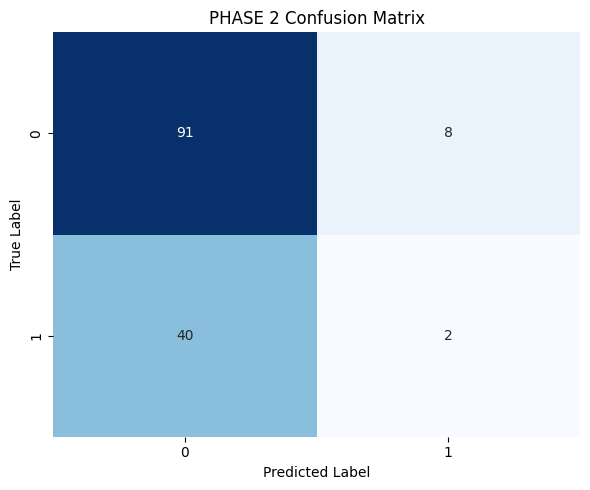


------------------------------------------------------------
TRAINING FOR PHASE 3
------------------------------------------------------------
Original Shape: (141, 777)
Class Distribution: [99 42]
Shape After Variance Threshold: (141, 8)

----- Fold 1 -----
Fold ROC-AUC: 0.52

----- Fold 2 -----
Fold ROC-AUC: 0.625

----- Fold 3 -----
Fold ROC-AUC: 0.475

----- Fold 4 -----
Fold ROC-AUC: 0.175

----- Fold 5 -----
Fold ROC-AUC: 0.6

----- Fold 6 -----
Fold ROC-AUC: 0.5

----- Fold 7 -----
Fold ROC-AUC: 0.65

----- Fold 8 -----
Fold ROC-AUC: 0.425

----- Fold 9 -----
Fold ROC-AUC: 0.55

----- Fold 10 -----
Fold ROC-AUC: 0.6

------------------------------------------------------------
FINAL RESULTS FOR PHASE 3
------------------------------------------------------------

Fold ROC-AUC Scores:
[0.52  0.625 0.475 0.175 0.6   0.5   0.65  0.425 0.55  0.6  ]

Mean Fold ROC-AUC:
0.512

Overall ROC-AUC:
0.5113

Classification Report:
              precision    recall  f1-score   support

     

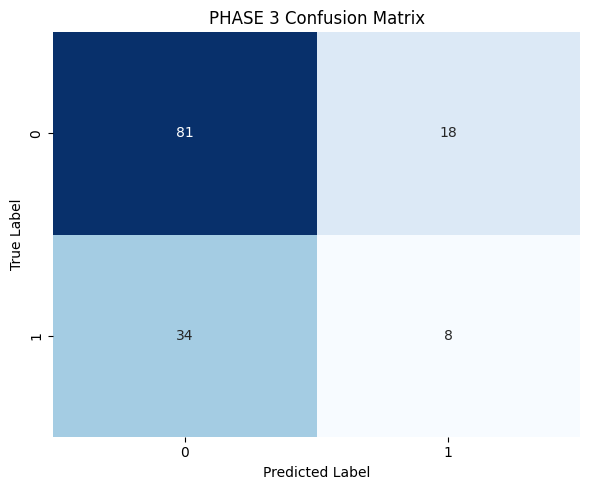


------------------------------------------------------------
FINAL ROC-AUC SCORES
------------------------------------------------------------
Phase 1 ROC-AUC: 0.5435
Phase 1 Precision: 0.3143
Phase 1 Recall: 0.2619
Phase 1 F1 Score: 0.2857

Phase 2 ROC-AUC: 0.4375
Phase 2 Precision: 0.2000
Phase 2 Recall: 0.0476
Phase 2 F1 Score: 0.0769

Phase 3 ROC-AUC: 0.5113
Phase 3 Precision: 0.3077
Phase 3 Recall: 0.1905
Phase 3 F1 Score: 0.2353


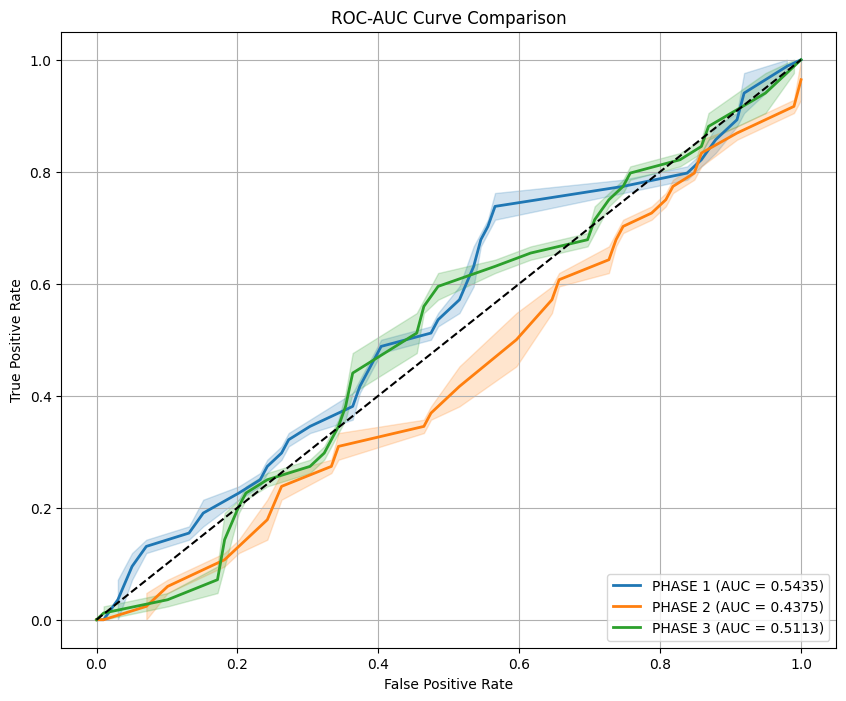

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold

from sklearn.svm import SVC

from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_curve
)

# load dataset
df = pd.read_csv("../../data/text_features_phasewise.csv")

print("-" * 60)
print("DATASET INFORMATION")
print("-" * 60)

print("Dataset Shape:", df.shape)

# normalize phase column
df["phase"] = df["phase"].astype(str).str.lower().str.strip()

print("\nAvailable Phases:")
print(df["phase"].unique())

# remove non-feature columns
remove_cols = [
    "participant_id",
    "phase",
    "label"
]

feature_cols = [col for col in df.columns if col not in remove_cols]

print("\nTotal Features:", len(feature_cols))

# store roc data
roc_data = {}

# training function
def train_phase_model(df_phase, phase_name):

    print("\n" + "-" * 60)
    print(f"TRAINING FOR {phase_name}")
    print("-" * 60)

    # drop missing values
    df_phase = df_phase.dropna()

    # features & labels
    X = df_phase[feature_cols]
    y = df_phase["label"].values

    print("Original Shape:", X.shape)
    print("Class Distribution:", np.bincount(y))

    # remove low variance features
    selector = VarianceThreshold(
        threshold=0.001
    )

    X = selector.fit_transform(X)

    print("Shape After Variance Threshold:", X.shape)

    # 10-fold stratified cv
    skf = StratifiedKFold(
        n_splits=10,
        shuffle=True,
        random_state=42
    )

    # store predictions
    all_probs = np.zeros(len(y))
    all_preds = np.zeros(len(y))

    fold_aucs = []

    # train each fold
    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):

        print(f"\n----- Fold {fold} -----")

        X_train, X_test = X[train_idx], X[test_idx]

        y_train, y_test = y[train_idx], y[test_idx]

        # feature scaling
        scaler = StandardScaler()

        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        # svm model
        model = SVC(

            kernel="linear",

            probability=True,

            class_weight="balanced",

            C=0.5,

            random_state=42
        )

        # train model
        model.fit(X_train, y_train)

        # predict
        y_prob = model.predict_proba(X_test)[:, 1]

        THRESHOLD = 0.35

        y_pred = (y_prob > THRESHOLD).astype(int)

        # store predictions
        all_probs[test_idx] = y_prob
        all_preds[test_idx] = y_pred

        # fold roc-auc
        fold_auc = roc_auc_score(y_test, y_prob)

        fold_aucs.append(fold_auc)

        print("Fold ROC-AUC:", round(fold_auc, 4))

    # final results
    overall_auc = roc_auc_score(y, all_probs)

    print("\n" + "-" * 60)
    print(f"FINAL RESULTS FOR {phase_name}")
    print("-" * 60)

    print("\nFold ROC-AUC Scores:")
    print(np.round(fold_aucs, 4))

    print("\nMean Fold ROC-AUC:")
    print(round(np.mean(fold_aucs), 4))

    print("\nOverall ROC-AUC:")
    print(round(overall_auc, 4))

    # classification report
    print("\nClassification Report:")
    print(classification_report(
        y,
        all_preds,
        zero_division=0
    ))

    # precision score
    precision = precision_score(
        y,
        all_preds,
        zero_division=0
    )

    print("Precision Score:", round(precision, 4))

    # recall score
    recall = recall_score(
        y,
        all_preds,
        zero_division=0
    )

    print("Recall Score:", round(recall, 4))

    # f1 score
    f1 = f1_score(
        y,
        all_preds,
        zero_division=0
    )

    print("F1 Score:", round(f1, 4))

    # confusion matrix
    cm = confusion_matrix(y, all_preds)

    print("\nConfusion Matrix:")
    print(cm)

    # draw confusion matrix
    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False
    )

    plt.title(f"{phase_name} Confusion Matrix")

    plt.xlabel("Predicted Label")

    plt.ylabel("True Label")

    plt.tight_layout()

    plt.show()

    # roc curve values
    fpr, tpr, _ = roc_curve(y, all_probs)

    roc_data[phase_name] = {
        "fpr": fpr,
        "tpr": tpr,
        "auc": overall_auc
    }

    return overall_auc, precision, recall, f1

# filter data phase-wise
df_p1 = df[df["phase"] == "phase1"]

df_p2 = df[df["phase"] == "phase2"]

df_p3 = df[df["phase"] == "phase3"]

# train models
roc_p1, prec_p1, rec_p1, f1_p1 = train_phase_model(
    df_p1,
    "PHASE 1"
)

roc_p2, prec_p2, rec_p2, f1_p2 = train_phase_model(
    df_p2,
    "PHASE 2"
)

roc_p3, prec_p3, rec_p3, f1_p3 = train_phase_model(
    df_p3,
    "PHASE 3"
)

# final summary
print("\n" + "-" * 60)
print("FINAL ROC-AUC SCORES")
print("-" * 60)

print(f"Phase 1 ROC-AUC: {roc_p1:.4f}")
print(f"Phase 1 Precision: {prec_p1:.4f}")
print(f"Phase 1 Recall: {rec_p1:.4f}")
print(f"Phase 1 F1 Score: {f1_p1:.4f}")

print()

print(f"Phase 2 ROC-AUC: {roc_p2:.4f}")
print(f"Phase 2 Precision: {prec_p2:.4f}")
print(f"Phase 2 Recall: {rec_p2:.4f}")
print(f"Phase 2 F1 Score: {f1_p2:.4f}")

print()

print(f"Phase 3 ROC-AUC: {roc_p3:.4f}")
print(f"Phase 3 Precision: {prec_p3:.4f}")
print(f"Phase 3 Recall: {rec_p3:.4f}")
print(f"Phase 3 F1 Score: {f1_p3:.4f}")

# final roc auc curve
plt.figure(figsize=(10, 8))

for phase_name, values in roc_data.items():

    sns.lineplot(
        x=values["fpr"],
        y=values["tpr"],
        linewidth=2,
        label=f"{phase_name} (AUC = {values['auc']:.4f})"
    )

sns.lineplot(
    x=[0, 1],
    y=[0, 1],
    linestyle="--",
    color="black"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC-AUC Curve Comparison")

plt.legend(loc="lower right")

plt.grid(True)

plt.show()

Logistic Regression

------------------------------------------------------------
DATASET INFORMATION
------------------------------------------------------------
Dataset Shape: (423, 780)

Available Phases:
<StringArray>
['phase1', 'phase2', 'phase3']
Length: 3, dtype: str

Total Features: 777

------------------------------------------------------------
TRAINING FOR PHASE 1
------------------------------------------------------------
Original Shape: (141, 777)
Class Distribution: [99 42]

Shape After Variance Threshold: (141, 9)
Shape After SelectKBest: (141, 9)

Predicted Distribution:
[ 8 21]

Actual Distribution:
[20  9]

Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.25      0.36        20
           1       0.29      0.67      0.40         9

    accuracy                           0.38        29
   macro avg       0.46      0.46      0.38        29
weighted avg       0.52      0.38      0.37        29

Precision Score: 0.2857
Recall Score

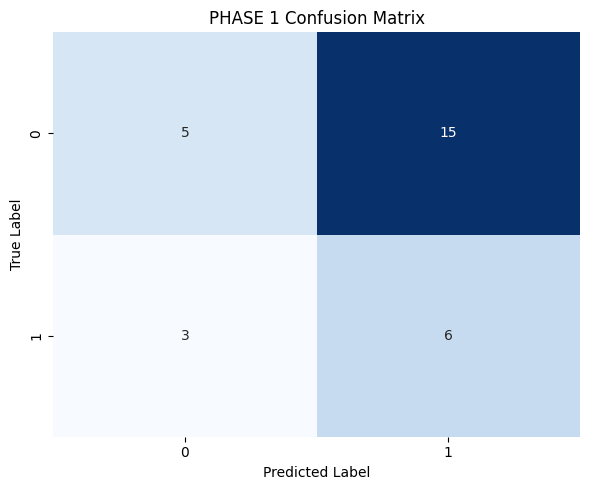


------------------------------------------------------------
TRAINING FOR PHASE 2
------------------------------------------------------------
Original Shape: (141, 777)
Class Distribution: [99 42]

Shape After Variance Threshold: (141, 8)
Shape After SelectKBest: (141, 8)

Predicted Distribution:
[ 3 26]

Actual Distribution:
[20  9]

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.10      0.17        20
           1       0.31      0.89      0.46         9

    accuracy                           0.34        29
   macro avg       0.49      0.49      0.32        29
weighted avg       0.56      0.34      0.26        29

Precision Score: 0.3077
Recall Score: 0.8889
F1 Score: 0.4571
ROC-AUC Score: 0.45

Confusion Matrix:
[[ 2 18]
 [ 1  8]]


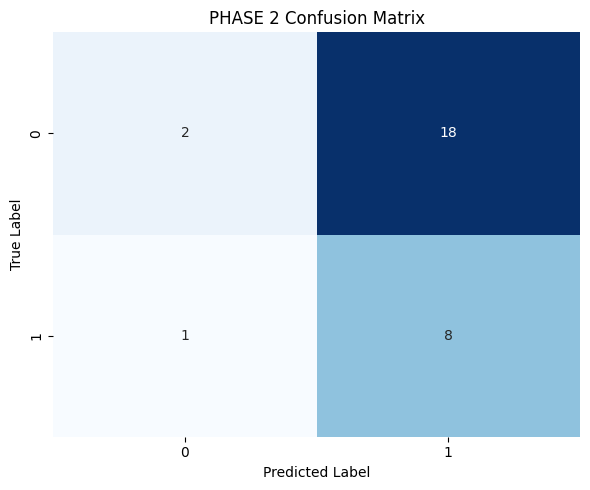


------------------------------------------------------------
TRAINING FOR PHASE 3
------------------------------------------------------------
Original Shape: (141, 777)
Class Distribution: [99 42]

Shape After Variance Threshold: (141, 9)
Shape After SelectKBest: (141, 9)

Predicted Distribution:
[ 2 27]

Actual Distribution:
[20  9]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.10      0.18        20
           1       0.33      1.00      0.50         9

    accuracy                           0.38        29
   macro avg       0.67      0.55      0.34        29
weighted avg       0.79      0.38      0.28        29

Precision Score: 0.3333
Recall Score: 1.0
F1 Score: 0.5
ROC-AUC Score: 0.4389

Confusion Matrix:
[[ 2 18]
 [ 0  9]]


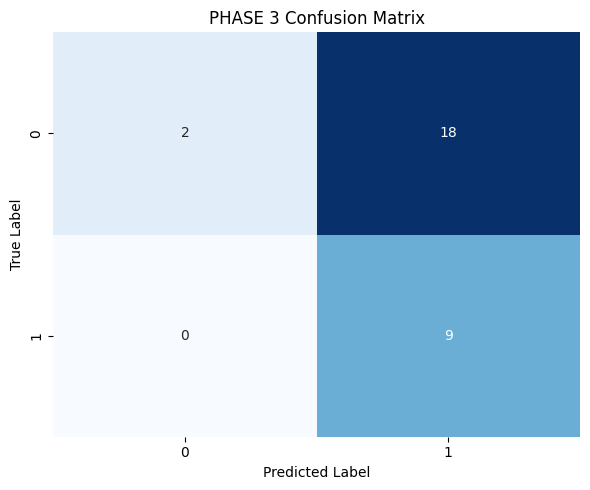


------------------------------------------------------------
FINAL ROC-AUC SCORES
------------------------------------------------------------
Phase 1 ROC-AUC: 0.5556
Phase 1 Precision: 0.2857
Phase 1 Recall: 0.6667
Phase 1 F1 Score: 0.4000

Phase 2 ROC-AUC: 0.4500
Phase 2 Precision: 0.3077
Phase 2 Recall: 0.8889
Phase 2 F1 Score: 0.4571

Phase 3 ROC-AUC: 0.4389
Phase 3 Precision: 0.3333
Phase 3 Recall: 1.0000
Phase 3 F1 Score: 0.5000


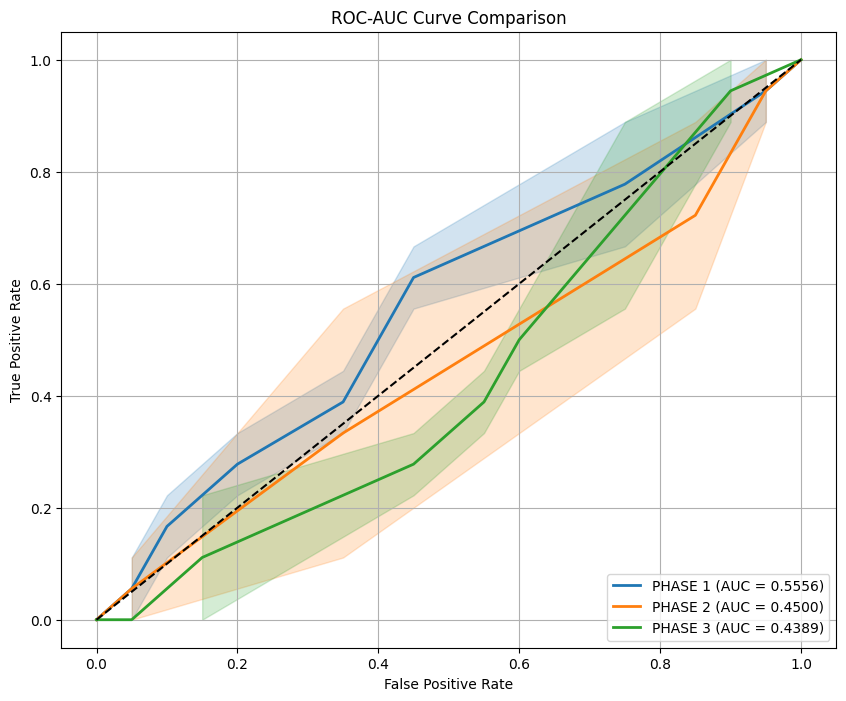

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import (
    VarianceThreshold,
    SelectKBest,
    mutual_info_classif
)

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_curve
)

# load dataset
df = pd.read_csv("../../data/text_features_phasewise.csv")

print("-" * 60)
print("DATASET INFORMATION")
print("-" * 60)

print("Dataset Shape:", df.shape)

# normalize phase column
df["phase"] = df["phase"].astype(str).str.lower().str.strip()

print("\nAvailable Phases:")
print(df["phase"].unique())

# remove non-feature columns
remove_cols = [
    "participant_id",
    "phase",
    "label"
]

feature_cols = [
    col for col in df.columns
    if col not in remove_cols
]

print("\nTotal Features:", len(feature_cols))

# store roc data
roc_data = {}

# training function
def train_phase_model(df_phase, phase_name):

    print("\n" + "-" * 60)
    print(f"TRAINING FOR {phase_name}")
    print("-" * 60)

    # drop missing values
    df_phase = df_phase.dropna()

    # features & labels
    X = df_phase[feature_cols]
    y = df_phase["label"].values

    print("Original Shape:", X.shape)
    print("Class Distribution:", np.bincount(y))

    # remove low variance features
    variance_selector = VarianceThreshold(
        threshold=0.0005
    )

    X = variance_selector.fit_transform(X)

    print("\nShape After Variance Threshold:", X.shape)

    # select best features
    kbest_selector = SelectKBest(
        score_func=mutual_info_classif,
        k=min(120, X.shape[1])
    )

    X = kbest_selector.fit_transform(X, y)

    print("Shape After SelectKBest:", X.shape)

    # train test split
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        stratify=y,
        random_state=42
    )

    # feature scaling
    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # tuned logistic regression
    model = LogisticRegression(

        # stronger regularization tuning
        C=0.3,

        # handles imbalance
        class_weight="balanced",

        # better convergence
        solver="liblinear",

        # more iterations
        max_iter=1000,

        random_state=42
    )

    # train model
    model.fit(X_train, y_train)

    # predict probabilities
    y_prob = model.predict_proba(X_test)[:, 1]

    # threshold
    THRESHOLD = 0.35

    y_pred = (y_prob > THRESHOLD).astype(int)

    print("\nPredicted Distribution:")
    print(np.bincount(y_pred))

    print("\nActual Distribution:")
    print(np.bincount(y_test))

    # classification report
    print("\nClassification Report:")
    print(classification_report(
        y_test,
        y_pred,
        zero_division=0
    ))

    # precision score
    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    print("Precision Score:", round(precision, 4))

    # recall score
    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    print("Recall Score:", round(recall, 4))

    # f1 score
    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    print("F1 Score:", round(f1, 4))

    # roc-auc
    roc = roc_auc_score(y_test, y_prob)

    print("ROC-AUC Score:", round(roc, 4))

    # confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    print("\nConfusion Matrix:")
    print(cm)

    # draw confusion matrix
    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False
    )

    plt.title(f"{phase_name} Confusion Matrix")

    plt.xlabel("Predicted Label")

    plt.ylabel("True Label")

    plt.tight_layout()

    plt.show()

    # roc curve values
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    roc_data[phase_name] = {
        "fpr": fpr,
        "tpr": tpr,
        "auc": roc
    }

    return model, roc, precision, recall, f1

# filter data phase-wise
df_p1 = df[df["phase"] == "phase1"]

df_p2 = df[df["phase"] == "phase2"]

df_p3 = df[df["phase"] == "phase3"]

# train models
model_p1, roc_p1, prec_p1, rec_p1, f1_p1 = train_phase_model(
    df_p1,
    "PHASE 1"
)

model_p2, roc_p2, prec_p2, rec_p2, f1_p2 = train_phase_model(
    df_p2,
    "PHASE 2"
)

model_p3, roc_p3, prec_p3, rec_p3, f1_p3 = train_phase_model(
    df_p3,
    "PHASE 3"
)

# final summary
print("\n" + "-" * 60)
print("FINAL ROC-AUC SCORES")
print("-" * 60)

print(f"Phase 1 ROC-AUC: {roc_p1:.4f}")
print(f"Phase 1 Precision: {prec_p1:.4f}")
print(f"Phase 1 Recall: {rec_p1:.4f}")
print(f"Phase 1 F1 Score: {f1_p1:.4f}")

print()

print(f"Phase 2 ROC-AUC: {roc_p2:.4f}")
print(f"Phase 2 Precision: {prec_p2:.4f}")
print(f"Phase 2 Recall: {rec_p2:.4f}")
print(f"Phase 2 F1 Score: {f1_p2:.4f}")

print()

print(f"Phase 3 ROC-AUC: {roc_p3:.4f}")
print(f"Phase 3 Precision: {prec_p3:.4f}")
print(f"Phase 3 Recall: {rec_p3:.4f}")
print(f"Phase 3 F1 Score: {f1_p3:.4f}")

# final roc auc curve
plt.figure(figsize=(10, 8))

for phase_name, values in roc_data.items():

    sns.lineplot(
        x=values["fpr"],
        y=values["tpr"],
        linewidth=2,
        label=f"{phase_name} (AUC = {values['auc']:.4f})"
    )

sns.lineplot(
    x=[0, 1],
    y=[0, 1],
    linestyle="--",
    color="black"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC-AUC Curve Comparison")

plt.legend(loc="lower right")

plt.grid(True)

plt.show()

Logistic Regression 5 folds

------------------------------------------------------------
DATASET INFORMATION
------------------------------------------------------------
Dataset Shape: (423, 780)

Available Phases:
<StringArray>
['phase1', 'phase2', 'phase3']
Length: 3, dtype: str

Total Features: 777

------------------------------------------------------------
TRAINING FOR PHASE 1
------------------------------------------------------------
Original Shape: (141, 777)
Class Distribution: [99 42]

Shape After Variance Threshold: (141, 9)
Shape After SelectKBest: (141, 9)

----- Fold 1 -----
Fold ROC-AUC: 0.5389

----- Fold 2 -----
Fold ROC-AUC: 0.6188

----- Fold 3 -----
Fold ROC-AUC: 0.525

----- Fold 4 -----
Fold ROC-AUC: 0.6875

----- Fold 5 -----
Fold ROC-AUC: 0.6491

------------------------------------------------------------
FINAL RESULTS FOR PHASE 1
------------------------------------------------------------

Fold ROC-AUC Scores:
[0.5389 0.6188 0.525  0.6875 0.6491]

Mean Fold ROC-AUC:
0.6039

Overall RO

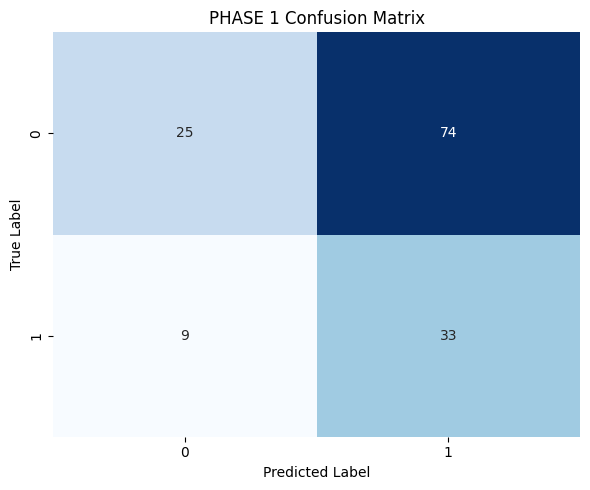


------------------------------------------------------------
TRAINING FOR PHASE 2
------------------------------------------------------------
Original Shape: (141, 777)
Class Distribution: [99 42]

Shape After Variance Threshold: (141, 8)
Shape After SelectKBest: (141, 8)

----- Fold 1 -----
Fold ROC-AUC: 0.4444

----- Fold 2 -----
Fold ROC-AUC: 0.5875

----- Fold 3 -----
Fold ROC-AUC: 0.4438

----- Fold 4 -----
Fold ROC-AUC: 0.4625

----- Fold 5 -----
Fold ROC-AUC: 0.5205

------------------------------------------------------------
FINAL RESULTS FOR PHASE 2
------------------------------------------------------------

Fold ROC-AUC Scores:
[0.4444 0.5875 0.4438 0.4625 0.5205]

Mean Fold ROC-AUC:
0.4917

Overall ROC-AUC:
0.5005

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.04      0.08        99
           1       0.30      0.95      0.45        42

    accuracy                           0.31       141
   macro avg      

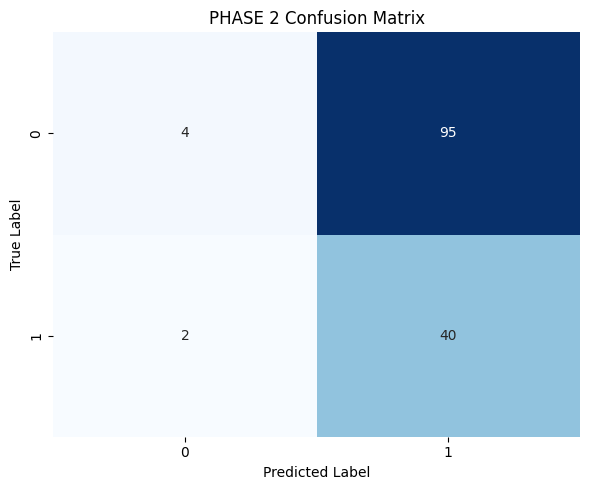


------------------------------------------------------------
TRAINING FOR PHASE 3
------------------------------------------------------------
Original Shape: (141, 777)
Class Distribution: [99 42]

Shape After Variance Threshold: (141, 9)
Shape After SelectKBest: (141, 9)

----- Fold 1 -----
Fold ROC-AUC: 0.4278

----- Fold 2 -----
Fold ROC-AUC: 0.6063

----- Fold 3 -----
Fold ROC-AUC: 0.4375

----- Fold 4 -----
Fold ROC-AUC: 0.5125

----- Fold 5 -----
Fold ROC-AUC: 0.4269

------------------------------------------------------------
FINAL RESULTS FOR PHASE 3
------------------------------------------------------------

Fold ROC-AUC Scores:
[0.4278 0.6063 0.4375 0.5125 0.4269]

Mean Fold ROC-AUC:
0.4822

Overall ROC-AUC:
0.4615

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.06      0.11        99
           1       0.30      0.93      0.45        42

    accuracy                           0.32       141
   macro avg      

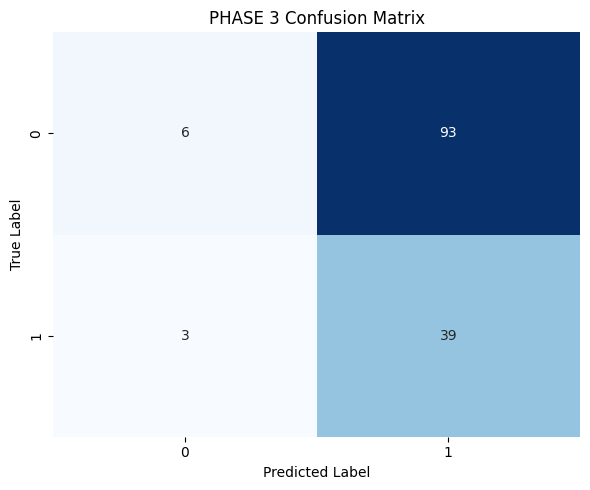


------------------------------------------------------------
FINAL ROC-AUC SCORES
------------------------------------------------------------
Phase 1 ROC-AUC: 0.5890
Phase 1 Precision: 0.3084
Phase 1 Recall: 0.7857
Phase 1 F1 Score: 0.4430

Phase 2 ROC-AUC: 0.5005
Phase 2 Precision: 0.2963
Phase 2 Recall: 0.9524
Phase 2 F1 Score: 0.4520

Phase 3 ROC-AUC: 0.4615
Phase 3 Precision: 0.2955
Phase 3 Recall: 0.9286
Phase 3 F1 Score: 0.4483


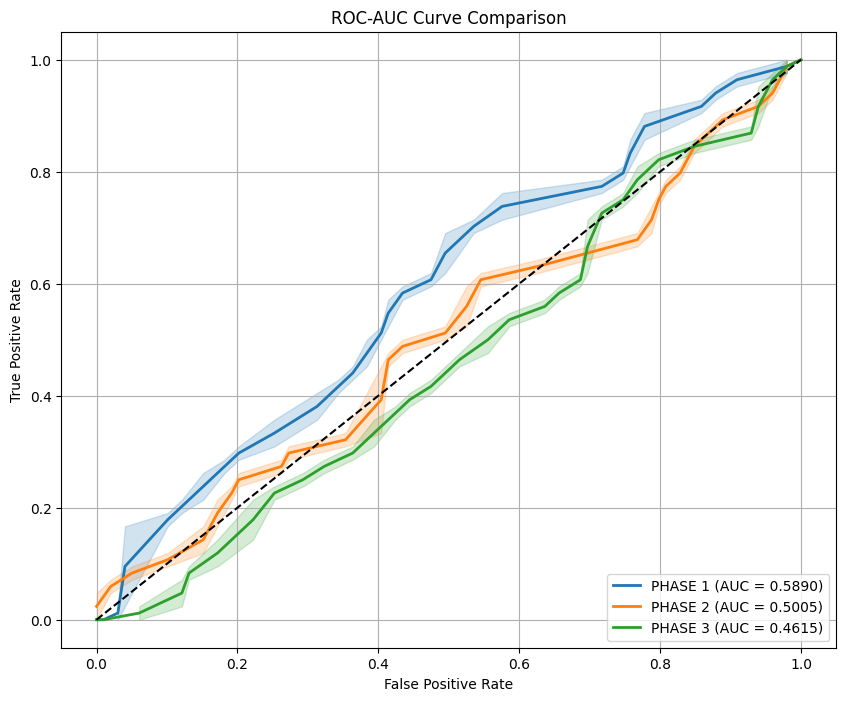

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler

from sklearn.feature_selection import (
    VarianceThreshold,
    SelectKBest,
    mutual_info_classif
)

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_curve
)

# load dataset
df = pd.read_csv("../../data/text_features_phasewise.csv")

print("-" * 60)
print("DATASET INFORMATION")
print("-" * 60)

print("Dataset Shape:", df.shape)

# normalize phase column
df["phase"] = df["phase"].astype(str).str.lower().str.strip()

print("\nAvailable Phases:")
print(df["phase"].unique())

# remove non-feature columns
remove_cols = [
    "participant_id",
    "phase",
    "label"
]

feature_cols = [
    col for col in df.columns
    if col not in remove_cols
]

print("\nTotal Features:", len(feature_cols))

# store roc data
roc_data = {}

# training function
def train_phase_model(df_phase, phase_name):

    print("\n" + "-" * 60)
    print(f"TRAINING FOR {phase_name}")
    print("-" * 60)

    # drop missing values
    df_phase = df_phase.dropna()

    # features & labels
    X = df_phase[feature_cols]
    y = df_phase["label"].values

    print("Original Shape:", X.shape)
    print("Class Distribution:", np.bincount(y))

    # remove low variance features
    variance_selector = VarianceThreshold(
        threshold=0.0005
    )

    X = variance_selector.fit_transform(X)

    print("\nShape After Variance Threshold:", X.shape)

    # select best features
    kbest_selector = SelectKBest(
        score_func=mutual_info_classif,
        k=min(120, X.shape[1])
    )

    X = kbest_selector.fit_transform(X, y)

    print("Shape After SelectKBest:", X.shape)

    # 5-fold stratified cv
    skf = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    # store predictions
    all_probs = np.zeros(len(y))
    all_preds = np.zeros(len(y))

    fold_aucs = []

    # train each fold
    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):

        print(f"\n----- Fold {fold} -----")

        X_train, X_test = X[train_idx], X[test_idx]

        y_train, y_test = y[train_idx], y[test_idx]

        # feature scaling
        scaler = StandardScaler()

        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        # logistic regression model
        model = LogisticRegression(

            # better generalization
            C=0.3,

            # handle imbalance
            class_weight="balanced",

            # stable solver
            solver="liblinear",

            # better convergence
            max_iter=1000,

            random_state=42
        )

        # train model
        model.fit(X_train, y_train)

        # predict
        y_prob = model.predict_proba(X_test)[:, 1]

        THRESHOLD = 0.35

        y_pred = (y_prob > THRESHOLD).astype(int)

        # store predictions
        all_probs[test_idx] = y_prob
        all_preds[test_idx] = y_pred

        # fold roc-auc
        fold_auc = roc_auc_score(y_test, y_prob)

        fold_aucs.append(fold_auc)

        print("Fold ROC-AUC:", round(fold_auc, 4))

    # final results
    overall_auc = roc_auc_score(y, all_probs)

    print("\n" + "-" * 60)
    print(f"FINAL RESULTS FOR {phase_name}")
    print("-" * 60)

    print("\nFold ROC-AUC Scores:")
    print(np.round(fold_aucs, 4))

    print("\nMean Fold ROC-AUC:")
    print(round(np.mean(fold_aucs), 4))

    print("\nOverall ROC-AUC:")
    print(round(overall_auc, 4))

    # classification report
    print("\nClassification Report:")
    print(classification_report(
        y,
        all_preds,
        zero_division=0
    ))

    # precision score
    precision = precision_score(
        y,
        all_preds,
        zero_division=0
    )

    print("Precision Score:", round(precision, 4))

    # recall score
    recall = recall_score(
        y,
        all_preds,
        zero_division=0
    )

    print("Recall Score:", round(recall, 4))

    # f1 score
    f1 = f1_score(
        y,
        all_preds,
        zero_division=0
    )

    print("F1 Score:", round(f1, 4))

    # confusion matrix
    cm = confusion_matrix(y, all_preds)

    print("\nConfusion Matrix:")
    print(cm)

    # draw confusion matrix
    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False
    )

    plt.title(f"{phase_name} Confusion Matrix")

    plt.xlabel("Predicted Label")

    plt.ylabel("True Label")

    plt.tight_layout()

    plt.show()

    # roc curve values
    fpr, tpr, _ = roc_curve(y, all_probs)

    roc_data[phase_name] = {
        "fpr": fpr,
        "tpr": tpr,
        "auc": overall_auc
    }

    return overall_auc, precision, recall, f1

# filter data phase-wise
df_p1 = df[df["phase"] == "phase1"]

df_p2 = df[df["phase"] == "phase2"]

df_p3 = df[df["phase"] == "phase3"]

# train models
roc_p1, prec_p1, rec_p1, f1_p1 = train_phase_model(
    df_p1,
    "PHASE 1"
)

roc_p2, prec_p2, rec_p2, f1_p2 = train_phase_model(
    df_p2,
    "PHASE 2"
)

roc_p3, prec_p3, rec_p3, f1_p3 = train_phase_model(
    df_p3,
    "PHASE 3"
)

# final summary
print("\n" + "-" * 60)
print("FINAL ROC-AUC SCORES")
print("-" * 60)

print(f"Phase 1 ROC-AUC: {roc_p1:.4f}")
print(f"Phase 1 Precision: {prec_p1:.4f}")
print(f"Phase 1 Recall: {rec_p1:.4f}")
print(f"Phase 1 F1 Score: {f1_p1:.4f}")

print()

print(f"Phase 2 ROC-AUC: {roc_p2:.4f}")
print(f"Phase 2 Precision: {prec_p2:.4f}")
print(f"Phase 2 Recall: {rec_p2:.4f}")
print(f"Phase 2 F1 Score: {f1_p2:.4f}")

print()

print(f"Phase 3 ROC-AUC: {roc_p3:.4f}")
print(f"Phase 3 Precision: {prec_p3:.4f}")
print(f"Phase 3 Recall: {rec_p3:.4f}")
print(f"Phase 3 F1 Score: {f1_p3:.4f}")

# final roc auc curve
plt.figure(figsize=(10, 8))

for phase_name, values in roc_data.items():

    sns.lineplot(
        x=values["fpr"],
        y=values["tpr"],
        linewidth=2,
        label=f"{phase_name} (AUC = {values['auc']:.4f})"
    )

sns.lineplot(
    x=[0, 1],
    y=[0, 1],
    linestyle="--",
    color="black"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC-AUC Curve Comparison")

plt.legend(loc="lower right")

plt.grid(True)

plt.show()

Logistic Regression 10 folds

------------------------------------------------------------
DATASET INFORMATION
------------------------------------------------------------
Dataset Shape: (423, 780)

Available Phases:
<StringArray>
['phase1', 'phase2', 'phase3']
Length: 3, dtype: str

Total Features: 777

------------------------------------------------------------
TRAINING FOR PHASE 1
------------------------------------------------------------
Original Shape: (141, 777)
Class Distribution: [99 42]

Shape After Variance Threshold: (141, 9)
Shape After SelectKBest: (141, 9)

----- Fold 1 -----
Fold ROC-AUC: 0.48

----- Fold 2 -----
Fold ROC-AUC: 0.575

----- Fold 3 -----
Fold ROC-AUC: 0.65

----- Fold 4 -----
Fold ROC-AUC: 0.8

----- Fold 5 -----
Fold ROC-AUC: 0.55

----- Fold 6 -----
Fold ROC-AUC: 0.5

----- Fold 7 -----
Fold ROC-AUC: 0.75

----- Fold 8 -----
Fold ROC-AUC: 0.625

----- Fold 9 -----
Fold ROC-AUC: 0.625

----- Fold 10 -----
Fold ROC-AUC: 0.6

----------------------------------------------------------

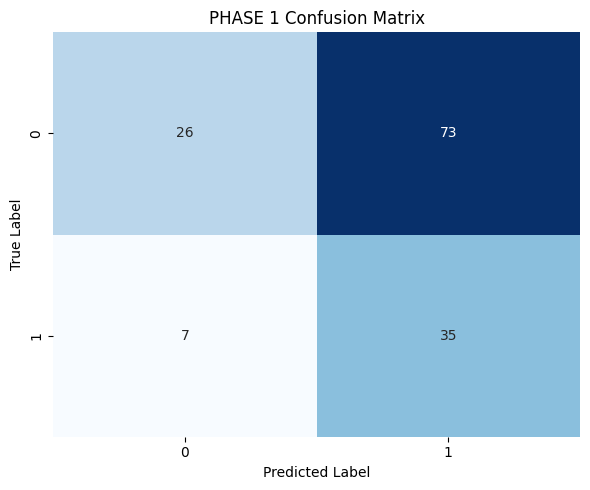


------------------------------------------------------------
TRAINING FOR PHASE 2
------------------------------------------------------------
Original Shape: (141, 777)
Class Distribution: [99 42]

Shape After Variance Threshold: (141, 8)
Shape After SelectKBest: (141, 8)

----- Fold 1 -----
Fold ROC-AUC: 0.3

----- Fold 2 -----
Fold ROC-AUC: 0.6

----- Fold 3 -----
Fold ROC-AUC: 0.45

----- Fold 4 -----
Fold ROC-AUC: 0.75

----- Fold 5 -----
Fold ROC-AUC: 0.475

----- Fold 6 -----
Fold ROC-AUC: 0.4

----- Fold 7 -----
Fold ROC-AUC: 0.325

----- Fold 8 -----
Fold ROC-AUC: 0.7

----- Fold 9 -----
Fold ROC-AUC: 0.65

----- Fold 10 -----
Fold ROC-AUC: 0.3333

------------------------------------------------------------
FINAL RESULTS FOR PHASE 2
------------------------------------------------------------

Fold ROC-AUC Scores:
[0.3    0.6    0.45   0.75   0.475  0.4    0.325  0.7    0.65   0.3333]

Mean Fold ROC-AUC:
0.4983

Overall ROC-AUC:
0.488

Classification Report:
              pr

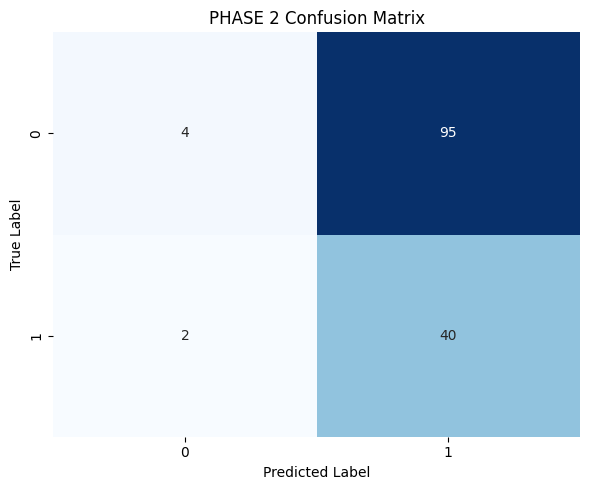


------------------------------------------------------------
TRAINING FOR PHASE 3
------------------------------------------------------------
Original Shape: (141, 777)
Class Distribution: [99 42]

Shape After Variance Threshold: (141, 9)
Shape After SelectKBest: (141, 9)

----- Fold 1 -----
Fold ROC-AUC: 0.4

----- Fold 2 -----
Fold ROC-AUC: 0.425

----- Fold 3 -----
Fold ROC-AUC: 0.525

----- Fold 4 -----
Fold ROC-AUC: 0.85

----- Fold 5 -----
Fold ROC-AUC: 0.3

----- Fold 6 -----
Fold ROC-AUC: 0.325

----- Fold 7 -----
Fold ROC-AUC: 0.325

----- Fold 8 -----
Fold ROC-AUC: 0.6

----- Fold 9 -----
Fold ROC-AUC: 0.425

----- Fold 10 -----
Fold ROC-AUC: 0.4222

------------------------------------------------------------
FINAL RESULTS FOR PHASE 3
------------------------------------------------------------

Fold ROC-AUC Scores:
[0.4    0.425  0.525  0.85   0.3    0.325  0.325  0.6    0.425  0.4222]

Mean Fold ROC-AUC:
0.4597

Overall ROC-AUC:
0.4649

Classification Report:
           

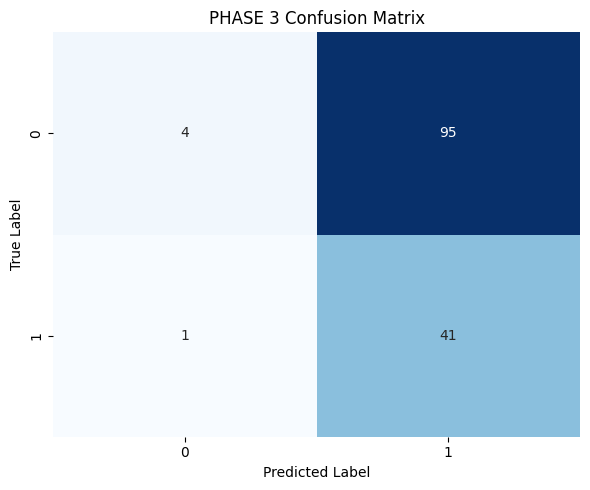


------------------------------------------------------------
FINAL ROC-AUC SCORES
------------------------------------------------------------
Phase 1 ROC-AUC: 0.6178
Phase 1 Precision: 0.3241
Phase 1 Recall: 0.8333
Phase 1 F1 Score: 0.4667

Phase 2 ROC-AUC: 0.4880
Phase 2 Precision: 0.2963
Phase 2 Recall: 0.9524
Phase 2 F1 Score: 0.4520

Phase 3 ROC-AUC: 0.4649
Phase 3 Precision: 0.3015
Phase 3 Recall: 0.9762
Phase 3 F1 Score: 0.4607


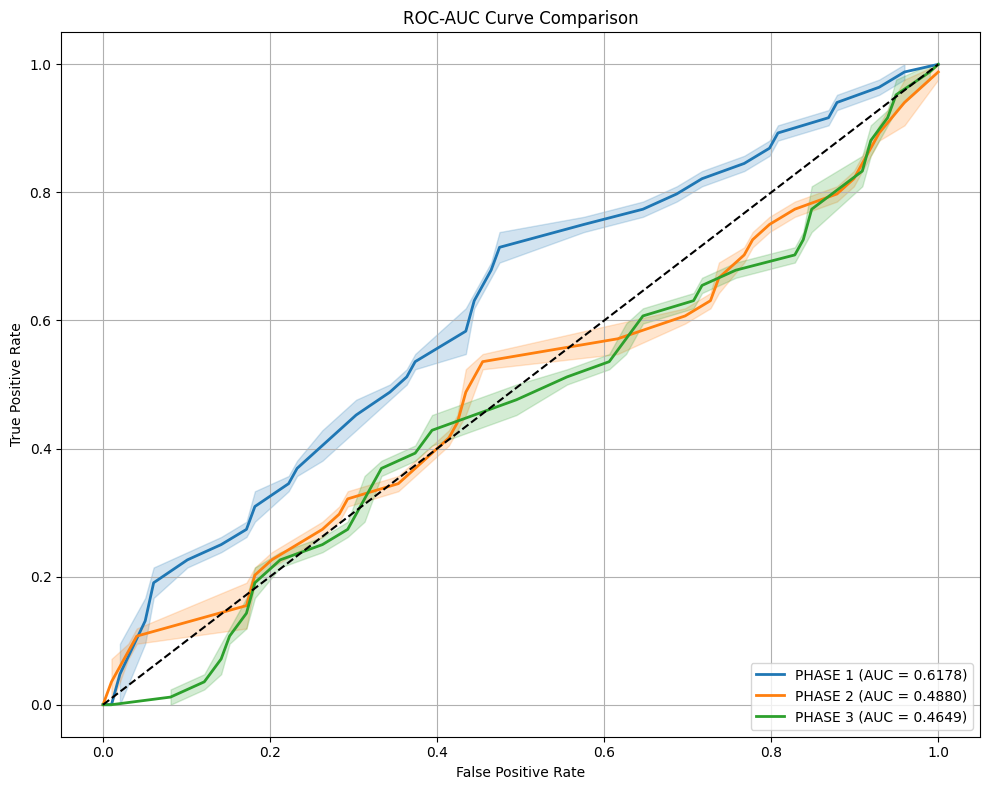

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler

from sklearn.feature_selection import (
    VarianceThreshold,
    SelectKBest,
    mutual_info_classif
)

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_curve
)

# load dataset
df = pd.read_csv("../../data/text_features_phasewise.csv")

print("-" * 60)
print("DATASET INFORMATION")
print("-" * 60)

print("Dataset Shape:", df.shape)

# normalize phase column
df["phase"] = df["phase"].astype(str).str.lower().str.strip()

print("\nAvailable Phases:")
print(df["phase"].unique())

# remove non-feature columns
remove_cols = [
    "participant_id",
    "phase",
    "label"
]

feature_cols = [
    col for col in df.columns
    if col not in remove_cols
]

print("\nTotal Features:", len(feature_cols))

# store roc curve data
roc_data = {}

# training function
def train_phase_model(df_phase, phase_name):

    print("\n" + "-" * 60)
    print(f"TRAINING FOR {phase_name}")
    print("-" * 60)

    # drop missing values
    df_phase = df_phase.dropna()

    # features & labels
    X = df_phase[feature_cols]
    y = df_phase["label"].values

    print("Original Shape:", X.shape)
    print("Class Distribution:", np.bincount(y))

    # remove low variance features
    variance_selector = VarianceThreshold(
        threshold=0.0005
    )

    X = variance_selector.fit_transform(X)

    print("\nShape After Variance Threshold:", X.shape)

    # select best features
    kbest_selector = SelectKBest(
        score_func=mutual_info_classif,
        k=min(120, X.shape[1])
    )

    X = kbest_selector.fit_transform(X, y)

    print("Shape After SelectKBest:", X.shape)

    # 10-fold stratified cv
    skf = StratifiedKFold(
        n_splits=10,
        shuffle=True,
        random_state=42
    )

    # store predictions
    all_probs = np.zeros(len(y))
    all_preds = np.zeros(len(y))

    fold_aucs = []

    # train each fold
    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):

        print(f"\n----- Fold {fold} -----")

        X_train, X_test = X[train_idx], X[test_idx]

        y_train, y_test = y[train_idx], y[test_idx]

        # feature scaling
        scaler = StandardScaler()

        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        # logistic regression model
        model = LogisticRegression(

            # better generalization
            C=0.3,

            # handle imbalance
            class_weight="balanced",

            # stable solver
            solver="liblinear",

            # better convergence
            max_iter=1000,

            random_state=42
        )

        # train model
        model.fit(X_train, y_train)

        # predict probabilities
        y_prob = model.predict_proba(X_test)[:, 1]

        # threshold
        THRESHOLD = 0.35

        y_pred = (y_prob > THRESHOLD).astype(int)

        # store predictions
        all_probs[test_idx] = y_prob
        all_preds[test_idx] = y_pred

        # fold roc-auc
        fold_auc = roc_auc_score(y_test, y_prob)

        fold_aucs.append(fold_auc)

        print("Fold ROC-AUC:", round(fold_auc, 4))

    # overall roc-auc
    overall_auc = roc_auc_score(y, all_probs)

    print("\n" + "-" * 60)
    print(f"FINAL RESULTS FOR {phase_name}")
    print("-" * 60)

    print("\nFold ROC-AUC Scores:")
    print(np.round(fold_aucs, 4))

    print("\nMean Fold ROC-AUC:")
    print(round(np.mean(fold_aucs), 4))

    print("\nOverall ROC-AUC:")
    print(round(overall_auc, 4))

    # classification report
    print("\nClassification Report:")
    print(classification_report(
        y,
        all_preds,
        zero_division=0
    ))

    # precision
    precision = precision_score(
        y,
        all_preds,
        zero_division=0
    )

    print("Precision Score:", round(precision, 4))

    # recall
    recall = recall_score(
        y,
        all_preds,
        zero_division=0
    )

    print("Recall Score:", round(recall, 4))

    # f1 score
    f1 = f1_score(
        y,
        all_preds,
        zero_division=0
    )

    print("F1 Score:", round(f1, 4))

    # confusion matrix
    cm = confusion_matrix(y, all_preds)

    print("\nConfusion Matrix:")
    print(cm)

    # plot confusion matrix
    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False
    )

    plt.title(f"{phase_name} Confusion Matrix")

    plt.xlabel("Predicted Label")

    plt.ylabel("True Label")

    plt.tight_layout()

    plt.show()

    # roc curve
    fpr, tpr, _ = roc_curve(y, all_probs)

    roc_data[phase_name] = {
        "fpr": fpr,
        "tpr": tpr,
        "auc": overall_auc
    }

    return overall_auc, precision, recall, f1

# filter data phase-wise
df_p1 = df[df["phase"] == "phase1"]

df_p2 = df[df["phase"] == "phase2"]

df_p3 = df[df["phase"] == "phase3"]

# train models
roc_p1, prec_p1, rec_p1, f1_p1 = train_phase_model(
    df_p1,
    "PHASE 1"
)

roc_p2, prec_p2, rec_p2, f1_p2 = train_phase_model(
    df_p2,
    "PHASE 2"
)

roc_p3, prec_p3, rec_p3, f1_p3 = train_phase_model(
    df_p3,
    "PHASE 3"
)

# final summary
print("\n" + "-" * 60)
print("FINAL ROC-AUC SCORES")
print("-" * 60)

print(f"Phase 1 ROC-AUC: {roc_p1:.4f}")
print(f"Phase 1 Precision: {prec_p1:.4f}")
print(f"Phase 1 Recall: {rec_p1:.4f}")
print(f"Phase 1 F1 Score: {f1_p1:.4f}")

print()

print(f"Phase 2 ROC-AUC: {roc_p2:.4f}")
print(f"Phase 2 Precision: {prec_p2:.4f}")
print(f"Phase 2 Recall: {rec_p2:.4f}")
print(f"Phase 2 F1 Score: {f1_p2:.4f}")

print()

print(f"Phase 3 ROC-AUC: {roc_p3:.4f}")
print(f"Phase 3 Precision: {prec_p3:.4f}")
print(f"Phase 3 Recall: {rec_p3:.4f}")
print(f"Phase 3 F1 Score: {f1_p3:.4f}")

# combined roc curve
plt.figure(figsize=(10, 8))

for phase_name, values in roc_data.items():

    sns.lineplot(
        x=values["fpr"],
        y=values["tpr"],
        linewidth=2,
        label=f"{phase_name} (AUC = {values['auc']:.4f})"
    )

# random baseline
sns.lineplot(
    x=[0, 1],
    y=[0, 1],
    linestyle="--",
    color="black"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC-AUC Curve Comparison")

plt.legend(loc="lower right")

plt.grid(True)

plt.tight_layout()

plt.show()

CatBoost

------------------------------------------------------------
DATASET INFORMATION
------------------------------------------------------------
Dataset Shape: (423, 780)

Available Phases:
<StringArray>
['phase1', 'phase2', 'phase3']
Length: 3, dtype: str

Total Features: 777

------------------------------------------------------------
TRAINING FOR PHASE 1
------------------------------------------------------------
Original Shape: (141, 777)
Class Distribution: [99 42]

Shape After Variance Threshold: (141, 771)
Shape After SelectKBest: (141, 180)
Class Weights: [1, np.float64(2.393939393939394)]

Predicted Distribution:
[19 10]

Actual Distribution:
[20  9]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.85      0.87        20
           1       0.70      0.78      0.74         9

    accuracy                           0.83        29
   macro avg       0.80      0.81      0.80        29
weighted avg       0.83      0.83    

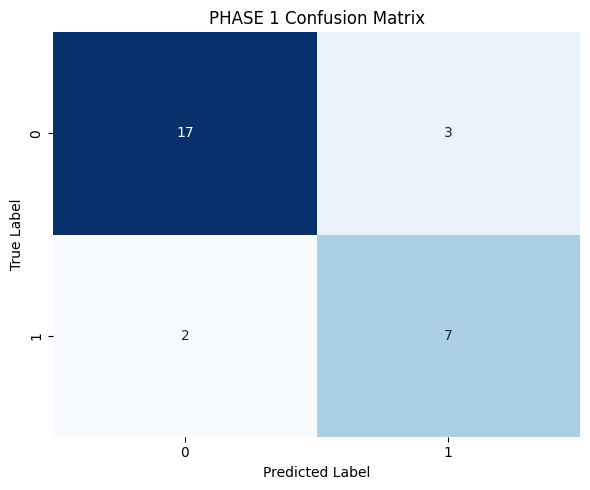


------------------------------------------------------------
TRAINING FOR PHASE 2
------------------------------------------------------------
Original Shape: (141, 777)
Class Distribution: [99 42]

Shape After Variance Threshold: (141, 770)
Shape After SelectKBest: (141, 180)
Class Weights: [1, np.float64(2.393939393939394)]

Predicted Distribution:
[20  9]

Actual Distribution:
[20  9]

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.75      0.75        20
           1       0.44      0.44      0.44         9

    accuracy                           0.66        29
   macro avg       0.60      0.60      0.60        29
weighted avg       0.66      0.66      0.66        29

Precision Score: 0.4444
Recall Score: 0.4444
F1 Score: 0.4444
ROC-AUC Score: 0.7222

Confusion Matrix:
[[15  5]
 [ 5  4]]


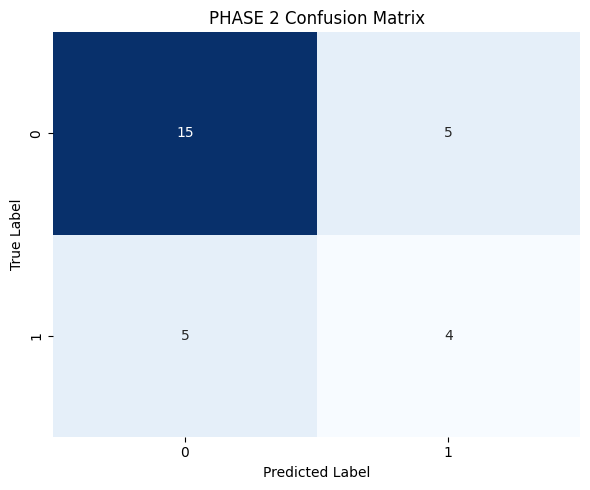


------------------------------------------------------------
TRAINING FOR PHASE 3
------------------------------------------------------------
Original Shape: (141, 777)
Class Distribution: [99 42]

Shape After Variance Threshold: (141, 771)
Shape After SelectKBest: (141, 180)
Class Weights: [1, np.float64(2.393939393939394)]

Predicted Distribution:
[20  9]

Actual Distribution:
[20  9]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.85      0.85        20
           1       0.67      0.67      0.67         9

    accuracy                           0.79        29
   macro avg       0.76      0.76      0.76        29
weighted avg       0.79      0.79      0.79        29

Precision Score: 0.6667
Recall Score: 0.6667
F1 Score: 0.6667
ROC-AUC Score: 0.7111

Confusion Matrix:
[[17  3]
 [ 3  6]]


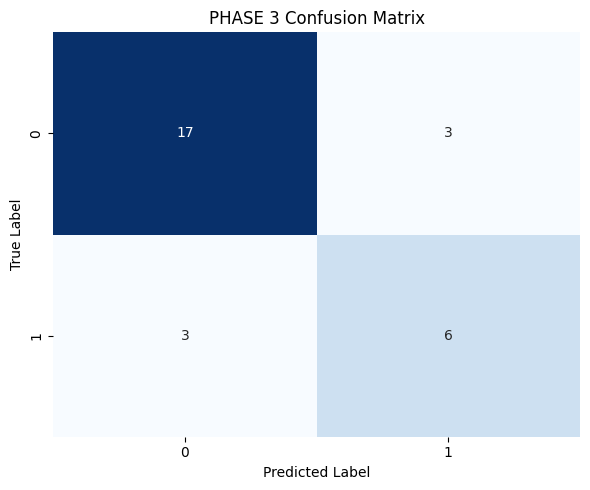


------------------------------------------------------------
FINAL ROC-AUC SCORES
------------------------------------------------------------
Phase 1 ROC-AUC: 0.8556
Phase 1 Precision: 0.7000
Phase 1 Recall: 0.7778
Phase 1 F1 Score: 0.7368

Phase 2 ROC-AUC: 0.7222
Phase 2 Precision: 0.4444
Phase 2 Recall: 0.4444
Phase 2 F1 Score: 0.4444

Phase 3 ROC-AUC: 0.7111
Phase 3 Precision: 0.6667
Phase 3 Recall: 0.6667
Phase 3 F1 Score: 0.6667


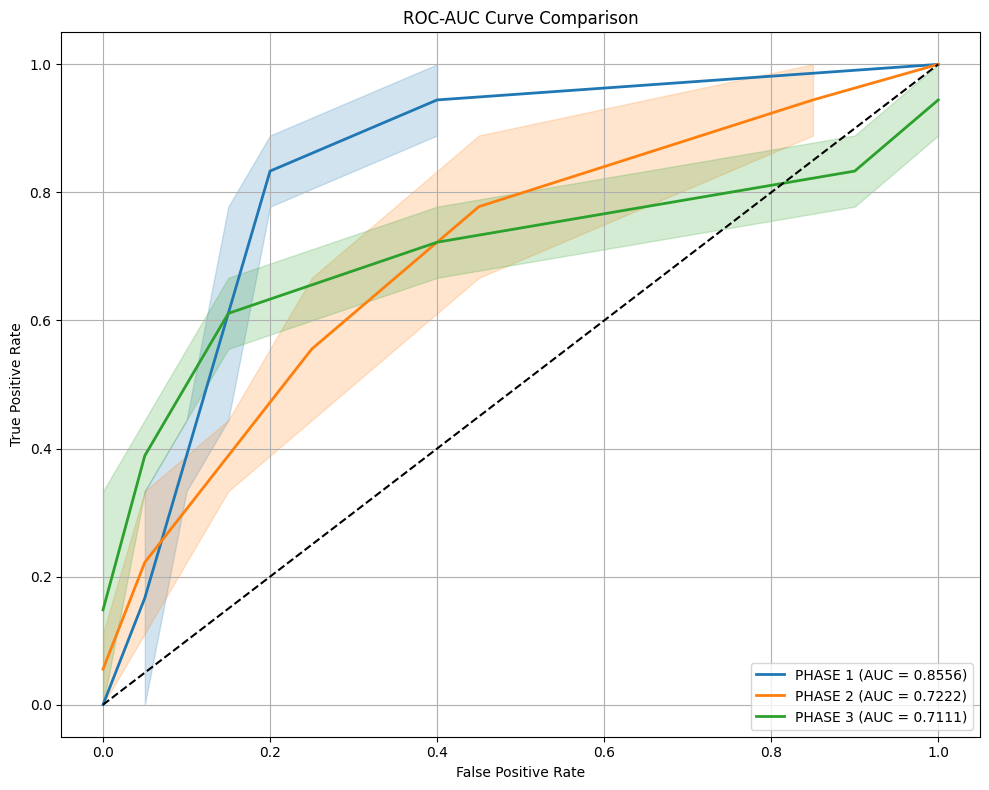

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.feature_selection import (
    VarianceThreshold,
    SelectKBest,
    mutual_info_classif
)

from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_curve
)

from catboost import CatBoostClassifier

# load dataset
df = pd.read_csv("../../data/text_features_phasewise.csv")

print("-" * 60)
print("DATASET INFORMATION")
print("-" * 60)

print("Dataset Shape:", df.shape)

# normalize phase column
df["phase"] = df["phase"].astype(str).str.lower().str.strip()

print("\nAvailable Phases:")
print(df["phase"].unique())

# remove non-feature columns
remove_cols = [
    "participant_id",
    "phase",
    "label"
]

feature_cols = [
    col for col in df.columns
    if col not in remove_cols
]

print("\nTotal Features:", len(feature_cols))

# store roc data
roc_data = {}

# training function
def train_phase_model(df_phase, phase_name):

    print("\n" + "-" * 60)
    print(f"TRAINING FOR {phase_name}")
    print("-" * 60)

    # drop missing values
    df_phase = df_phase.dropna()

    # features & labels
    X = df_phase[feature_cols]
    y = df_phase["label"].values

    print("Original Shape:", X.shape)
    print("Class Distribution:", np.bincount(y))

    # remove low variance features
    variance_selector = VarianceThreshold(
        threshold=0.00001
    )

    X = variance_selector.fit_transform(X)

    print("\nShape After Variance Threshold:", X.shape)

    # select important features
    kbest_selector = SelectKBest(
        score_func=mutual_info_classif,
        k=min(180, X.shape[1])
    )

    X = kbest_selector.fit_transform(X, y)

    print("Shape After SelectKBest:", X.shape)

    # train test split
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        stratify=y,
        random_state=42
    )

    # feature scaling
    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # handle class imbalance
    neg = np.sum(y_train == 0)
    pos = np.sum(y_train == 1)

    class_weights = [
        1,
        neg / pos
    ]

    print("Class Weights:", class_weights)

    # stable catboost model
    model = CatBoostClassifier(

        # core
        loss_function="Logloss",
        eval_metric="AUC",

        # simpler trees
        iterations=400,

        # lower depth
        depth=4,

        # moderate learning
        learning_rate=0.03,

        # stronger regularization
        l2_leaf_reg=8,

        # slight randomness
        random_strength=1,

        # better generalization
        bootstrap_type="Bernoulli",
        subsample=0.8,

        # handle imbalance
        class_weights=class_weights,

        # stable growth
        grow_policy="SymmetricTree",

        random_seed=42,

        verbose=0
    )

    # train model
    model.fit(
        X_train,
        y_train
    )

    # predict probabilities
    y_prob = model.predict_proba(X_test)[:, 1]

    # threshold
    THRESHOLD = 0.35

    y_pred = (y_prob > THRESHOLD).astype(int)

    print("\nPredicted Distribution:")
    print(np.bincount(y_pred))

    print("\nActual Distribution:")
    print(np.bincount(y_test))

    # classification report
    print("\nClassification Report:")
    print(classification_report(
        y_test,
        y_pred,
        zero_division=0
    ))

    # precision
    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    print("Precision Score:", round(precision, 4))

    # recall
    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    print("Recall Score:", round(recall, 4))

    # f1 score
    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    print("F1 Score:", round(f1, 4))

    # roc-auc
    roc = roc_auc_score(y_test, y_prob)

    print("ROC-AUC Score:", round(roc, 4))

    # confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    print("\nConfusion Matrix:")
    print(cm)

    # plot confusion matrix
    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False
    )

    plt.title(f"{phase_name} Confusion Matrix")

    plt.xlabel("Predicted Label")

    plt.ylabel("True Label")

    plt.tight_layout()

    plt.show()

    # roc curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    roc_data[phase_name] = {
        "fpr": fpr,
        "tpr": tpr,
        "auc": roc
    }

    return model, roc, precision, recall, f1

# filter data phase-wise
df_p1 = df[df["phase"] == "phase1"]

df_p2 = df[df["phase"] == "phase2"]

df_p3 = df[df["phase"] == "phase3"]

# train models
model_p1, roc_p1, prec_p1, rec_p1, f1_p1 = train_phase_model(
    df_p1,
    "PHASE 1"
)

model_p2, roc_p2, prec_p2, rec_p2, f1_p2 = train_phase_model(
    df_p2,
    "PHASE 2"
)

model_p3, roc_p3, prec_p3, rec_p3, f1_p3 = train_phase_model(
    df_p3,
    "PHASE 3"
)

# final summary
print("\n" + "-" * 60)
print("FINAL ROC-AUC SCORES")
print("-" * 60)

print(f"Phase 1 ROC-AUC: {roc_p1:.4f}")
print(f"Phase 1 Precision: {prec_p1:.4f}")
print(f"Phase 1 Recall: {rec_p1:.4f}")
print(f"Phase 1 F1 Score: {f1_p1:.4f}")

print()

print(f"Phase 2 ROC-AUC: {roc_p2:.4f}")
print(f"Phase 2 Precision: {prec_p2:.4f}")
print(f"Phase 2 Recall: {rec_p2:.4f}")
print(f"Phase 2 F1 Score: {f1_p2:.4f}")

print()

print(f"Phase 3 ROC-AUC: {roc_p3:.4f}")
print(f"Phase 3 Precision: {prec_p3:.4f}")
print(f"Phase 3 Recall: {rec_p3:.4f}")
print(f"Phase 3 F1 Score: {f1_p3:.4f}")

# combined roc curve
plt.figure(figsize=(10, 8))

for phase_name, values in roc_data.items():

    sns.lineplot(
        x=values["fpr"],
        y=values["tpr"],
        linewidth=2,
        label=f"{phase_name} (AUC = {values['auc']:.4f})"
    )

# random baseline
sns.lineplot(
    x=[0, 1],
    y=[0, 1],
    linestyle="--",
    color="black"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC-AUC Curve Comparison")

plt.legend(loc="lower right")

plt.grid(True)

plt.tight_layout()

plt.show()

CatBoost 5 folds

------------------------------------------------------------
DATASET INFORMATION
------------------------------------------------------------
Dataset Shape: (423, 780)

Available Phases:
<StringArray>
['phase1', 'phase2', 'phase3']
Length: 3, dtype: str

Total Features: 777

------------------------------------------------------------
TRAINING FOR PHASE 1
------------------------------------------------------------
Original Shape: (141, 777)
Class Distribution: [99 42]

Shape After Variance Threshold: (141, 771)
Shape After SelectKBest: (141, 180)

----- Fold 1 -----
Fold ROC-AUC: 0.5889

----- Fold 2 -----
Fold ROC-AUC: 0.8375

----- Fold 3 -----
Fold ROC-AUC: 0.9062

----- Fold 4 -----
Fold ROC-AUC: 0.8688

----- Fold 5 -----
Fold ROC-AUC: 0.8713

------------------------------------------------------------
FINAL RESULTS FOR PHASE 1
------------------------------------------------------------

Fold ROC-AUC Scores:
[0.5889 0.8375 0.9062 0.8688 0.8713]

Mean Fold ROC-AUC:
0.8145

Overa

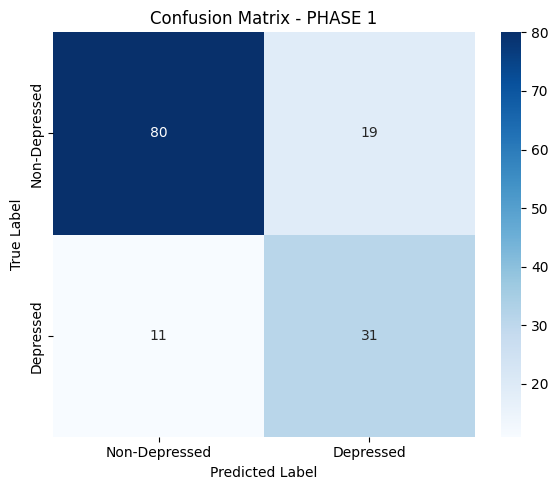


------------------------------------------------------------
TRAINING FOR PHASE 2
------------------------------------------------------------
Original Shape: (141, 777)
Class Distribution: [99 42]

Shape After Variance Threshold: (141, 770)
Shape After SelectKBest: (141, 180)

----- Fold 1 -----
Fold ROC-AUC: 0.7556

----- Fold 2 -----
Fold ROC-AUC: 0.6875

----- Fold 3 -----
Fold ROC-AUC: 0.7562

----- Fold 4 -----
Fold ROC-AUC: 0.8375

----- Fold 5 -----
Fold ROC-AUC: 0.7018

------------------------------------------------------------
FINAL RESULTS FOR PHASE 2
------------------------------------------------------------

Fold ROC-AUC Scores:
[0.7556 0.6875 0.7562 0.8375 0.7018]

Mean Fold ROC-AUC:
0.7477

Overall ROC-AUC:
0.7504

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.80      0.81        99
           1       0.55      0.57      0.56        42

    accuracy                           0.73       141
   macro avg  

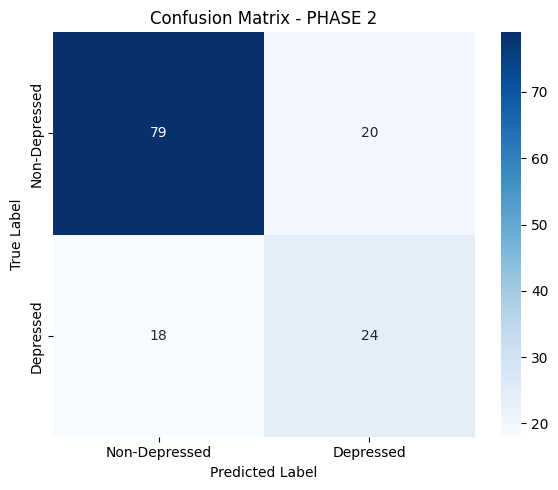


------------------------------------------------------------
TRAINING FOR PHASE 3
------------------------------------------------------------
Original Shape: (141, 777)
Class Distribution: [99 42]

Shape After Variance Threshold: (141, 771)
Shape After SelectKBest: (141, 180)

----- Fold 1 -----
Fold ROC-AUC: 0.7278

----- Fold 2 -----
Fold ROC-AUC: 0.6

----- Fold 3 -----
Fold ROC-AUC: 0.7063

----- Fold 4 -----
Fold ROC-AUC: 0.7

----- Fold 5 -----
Fold ROC-AUC: 0.6199

------------------------------------------------------------
FINAL RESULTS FOR PHASE 3
------------------------------------------------------------

Fold ROC-AUC Scores:
[0.7278 0.6    0.7062 0.7    0.6199]

Mean Fold ROC-AUC:
0.6708

Overall ROC-AUC:
0.672

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.75      0.76        99
           1       0.46      0.50      0.48        42

    accuracy                           0.67       141
   macro avg       0.

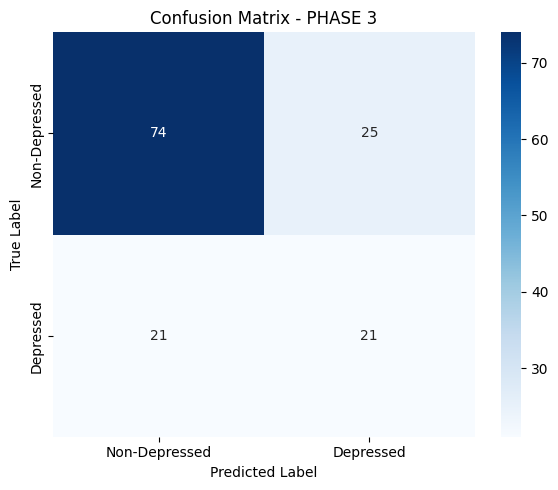


------------------------------------------------------------
FINAL ROC-AUC SCORES
------------------------------------------------------------
Phase 1 ROC-AUC: 0.8107
Phase 1 Precision: 0.6200
Phase 1 Recall: 0.7381
Phase 1 F1 Score: 0.6739

Phase 2 ROC-AUC: 0.7504
Phase 2 Precision: 0.5455
Phase 2 Recall: 0.5714
Phase 2 F1 Score: 0.5581

Phase 3 ROC-AUC: 0.6720
Phase 3 Precision: 0.4565
Phase 3 Recall: 0.5000
Phase 3 F1 Score: 0.4773


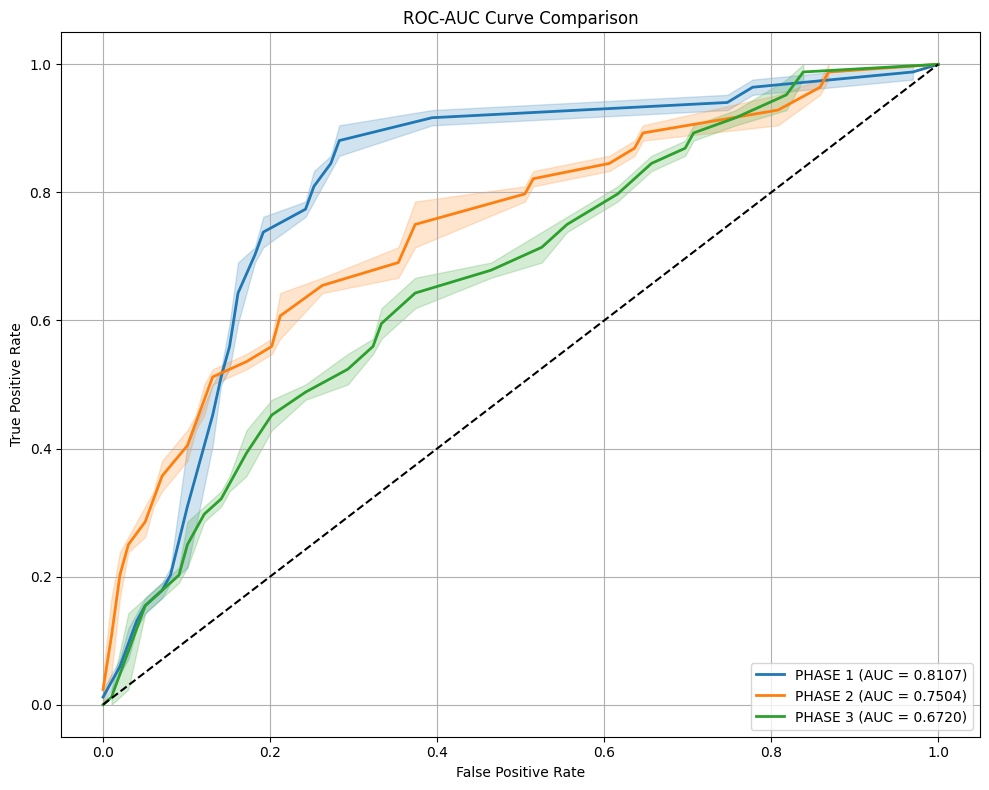

In [14]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler

from sklearn.feature_selection import (
    VarianceThreshold,
    SelectKBest,
    mutual_info_classif
)

from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_curve
)

from catboost import CatBoostClassifier

# load dataset
df = pd.read_csv("../../data/text_features_phasewise.csv")

print("-" * 60)
print("DATASET INFORMATION")
print("-" * 60)

print("Dataset Shape:", df.shape)

# normalize phase column
df["phase"] = df["phase"].astype(str).str.lower().str.strip()

print("\nAvailable Phases:")
print(df["phase"].unique())

# remove non-feature columns
remove_cols = [
    "participant_id",
    "phase",
    "label"
]

feature_cols = [
    col for col in df.columns
    if col not in remove_cols
]

print("\nTotal Features:", len(feature_cols))

# store roc curve data
roc_data = {}

# training function
def train_phase_model(df_phase, phase_name):

    print("\n" + "-" * 60)
    print(f"TRAINING FOR {phase_name}")
    print("-" * 60)

    # drop missing values
    df_phase = df_phase.dropna()

    # features & labels
    X = df_phase[feature_cols]
    y = df_phase["label"].values

    print("Original Shape:", X.shape)
    print("Class Distribution:", np.bincount(y))

    # remove low variance features
    variance_selector = VarianceThreshold(
        threshold=0.00001
    )

    X = variance_selector.fit_transform(X)

    print("\nShape After Variance Threshold:", X.shape)

    # select important features
    kbest_selector = SelectKBest(
        score_func=mutual_info_classif,
        k=min(180, X.shape[1])
    )

    X = kbest_selector.fit_transform(X, y)

    print("Shape After SelectKBest:", X.shape)

    # 5-fold stratified cv
    skf = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    # store predictions
    all_probs = np.zeros(len(y))
    all_preds = np.zeros(len(y))

    fold_aucs = []

    # train each fold
    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):

        print(f"\n----- Fold {fold} -----")

        X_train, X_test = X[train_idx], X[test_idx]

        y_train, y_test = y[train_idx], y[test_idx]

        # feature scaling
        scaler = StandardScaler()

        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        # handle class imbalance
        neg = np.sum(y_train == 0)
        pos = np.sum(y_train == 1)

        class_weights = [
            1,
            neg / pos
        ]

        # stable catboost model
        model = CatBoostClassifier(

            # core
            loss_function="Logloss",
            eval_metric="AUC",

            # stable boosting
            iterations=400,

            # small depth
            depth=4,

            # moderate learning
            learning_rate=0.03,

            # stronger regularization
            l2_leaf_reg=8,

            # controlled randomness
            random_strength=1,

            # better generalization
            bootstrap_type="Bernoulli",
            subsample=0.8,

            # imbalance handling
            class_weights=class_weights,

            # stable growth
            grow_policy="SymmetricTree",

            random_seed=42,

            verbose=0
        )

        # train model
        model.fit(
            X_train,
            y_train
        )

        # predict probabilities
        y_prob = model.predict_proba(X_test)[:, 1]

        # threshold
        THRESHOLD = 0.35

        y_pred = (y_prob > THRESHOLD).astype(int)

        # store predictions
        all_probs[test_idx] = y_prob
        all_preds[test_idx] = y_pred

        # fold roc-auc
        fold_auc = roc_auc_score(y_test, y_prob)

        fold_aucs.append(fold_auc)

        print("Fold ROC-AUC:", round(fold_auc, 4))

    # overall roc-auc
    overall_auc = roc_auc_score(y, all_probs)

    print("\n" + "-" * 60)
    print(f"FINAL RESULTS FOR {phase_name}")
    print("-" * 60)

    print("\nFold ROC-AUC Scores:")
    print(np.round(fold_aucs, 4))

    print("\nMean Fold ROC-AUC:")
    print(round(np.mean(fold_aucs), 4))

    print("\nOverall ROC-AUC:")
    print(round(overall_auc, 4))

    # classification report
    print("\nClassification Report:")
    print(classification_report(
        y,
        all_preds,
        zero_division=0
    ))

    # precision
    precision = precision_score(
        y,
        all_preds,
        zero_division=0
    )

    print("Precision Score:", round(precision, 4))

    # recall
    recall = recall_score(
        y,
        all_preds,
        zero_division=0
    )

    print("Recall Score:", round(recall, 4))

    # f1 score
    f1 = f1_score(
        y,
        all_preds,
        zero_division=0
    )

    print("F1 Score:", round(f1, 4))

    # confusion matrix
    cm = confusion_matrix(y, all_preds)

    print("\nConfusion Matrix:")
    print(cm)

    # plot confusion matrix
    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Non-Depressed", "Depressed"],
        yticklabels=["Non-Depressed", "Depressed"]
    )

    plt.title(f"Confusion Matrix - {phase_name}")

    plt.xlabel("Predicted Label")

    plt.ylabel("True Label")

    plt.tight_layout()

    plt.show()

    # roc curve values
    fpr, tpr, _ = roc_curve(y, all_probs)

    roc_data[phase_name] = {
        "fpr": fpr,
        "tpr": tpr,
        "auc": overall_auc
    }

    return overall_auc, precision, recall, f1

# filter data phase-wise
df_p1 = df[df["phase"] == "phase1"]

df_p2 = df[df["phase"] == "phase2"]

df_p3 = df[df["phase"] == "phase3"]

# train models
roc_p1, prec_p1, rec_p1, f1_p1 = train_phase_model(
    df_p1,
    "PHASE 1"
)

roc_p2, prec_p2, rec_p2, f1_p2 = train_phase_model(
    df_p2,
    "PHASE 2"
)

roc_p3, prec_p3, rec_p3, f1_p3 = train_phase_model(
    df_p3,
    "PHASE 3"
)

# final summary
print("\n" + "-" * 60)
print("FINAL ROC-AUC SCORES")
print("-" * 60)

print(f"Phase 1 ROC-AUC: {roc_p1:.4f}")
print(f"Phase 1 Precision: {prec_p1:.4f}")
print(f"Phase 1 Recall: {rec_p1:.4f}")
print(f"Phase 1 F1 Score: {f1_p1:.4f}")

print()

print(f"Phase 2 ROC-AUC: {roc_p2:.4f}")
print(f"Phase 2 Precision: {prec_p2:.4f}")
print(f"Phase 2 Recall: {rec_p2:.4f}")
print(f"Phase 2 F1 Score: {f1_p2:.4f}")

print()

print(f"Phase 3 ROC-AUC: {roc_p3:.4f}")
print(f"Phase 3 Precision: {prec_p3:.4f}")
print(f"Phase 3 Recall: {rec_p3:.4f}")
print(f"Phase 3 F1 Score: {f1_p3:.4f}")

# combined roc curve
plt.figure(figsize=(10, 8))

for phase_name, values in roc_data.items():

    sns.lineplot(
        x=values["fpr"],
        y=values["tpr"],
        linewidth=2,
        label=f"{phase_name} (AUC = {values['auc']:.4f})"
    )

# random baseline
sns.lineplot(
    x=[0, 1],
    y=[0, 1],
    linestyle="--",
    color="black"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC-AUC Curve Comparison")

plt.legend(loc="lower right")

plt.grid(True)

plt.tight_layout()

plt.show()

Catoost 10 folds

------------------------------------------------------------
DATASET INFORMATION
------------------------------------------------------------
Dataset Shape: (423, 780)

Available Phases:
<StringArray>
['phase1', 'phase2', 'phase3']
Length: 3, dtype: str

Total Features: 777

------------------------------------------------------------
TRAINING FOR PHASE 1
------------------------------------------------------------
Original Shape: (141, 777)
Class Distribution: [99 42]

Shape After Variance Threshold: (141, 771)
Shape After SelectKBest: (141, 180)

----- Fold 1 -----
Fold ROC-AUC: 0.42

----- Fold 2 -----
Fold ROC-AUC: 0.8

----- Fold 3 -----
Fold ROC-AUC: 0.85

----- Fold 4 -----
Fold ROC-AUC: 1.0

----- Fold 5 -----
Fold ROC-AUC: 0.925

----- Fold 6 -----
Fold ROC-AUC: 0.825

----- Fold 7 -----
Fold ROC-AUC: 0.875

----- Fold 8 -----
Fold ROC-AUC: 0.95

----- Fold 9 -----
Fold ROC-AUC: 0.9

----- Fold 10 -----
Fold ROC-AUC: 0.8667

----------------------------------------------------

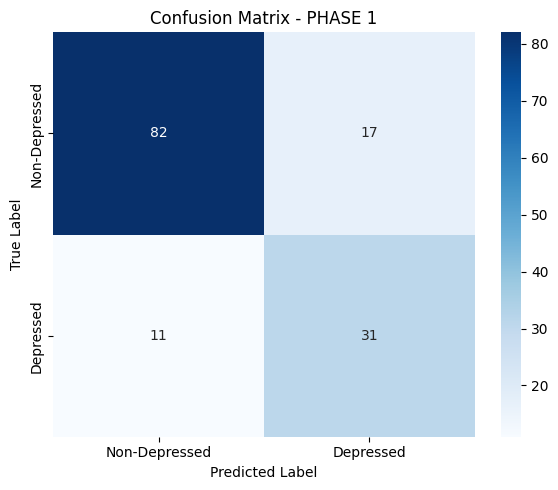


------------------------------------------------------------
TRAINING FOR PHASE 2
------------------------------------------------------------
Original Shape: (141, 777)
Class Distribution: [99 42]

Shape After Variance Threshold: (141, 770)
Shape After SelectKBest: (141, 180)

----- Fold 1 -----
Fold ROC-AUC: 0.88

----- Fold 2 -----
Fold ROC-AUC: 0.875

----- Fold 3 -----
Fold ROC-AUC: 0.675

----- Fold 4 -----
Fold ROC-AUC: 0.65

----- Fold 5 -----
Fold ROC-AUC: 0.975

----- Fold 6 -----
Fold ROC-AUC: 0.75

----- Fold 7 -----
Fold ROC-AUC: 0.775

----- Fold 8 -----
Fold ROC-AUC: 0.875

----- Fold 9 -----
Fold ROC-AUC: 0.7

----- Fold 10 -----
Fold ROC-AUC: 0.8667

------------------------------------------------------------
FINAL RESULTS FOR PHASE 2
------------------------------------------------------------

Fold ROC-AUC Scores:
[0.88   0.875  0.675  0.65   0.975  0.75   0.775  0.875  0.7    0.8667]

Mean Fold ROC-AUC:
0.8022

Overall ROC-AUC:
0.786

Classification Report:
      

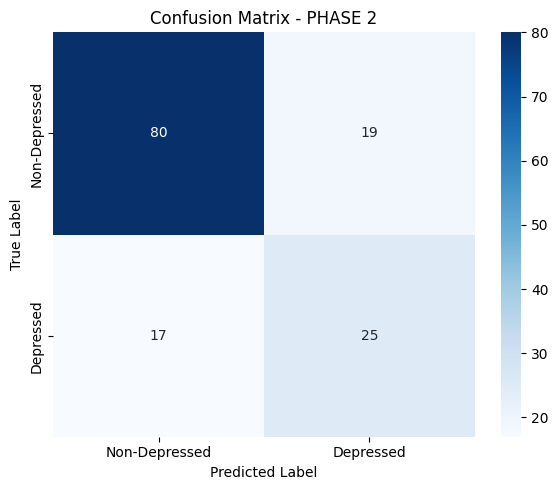


------------------------------------------------------------
TRAINING FOR PHASE 3
------------------------------------------------------------
Original Shape: (141, 777)
Class Distribution: [99 42]

Shape After Variance Threshold: (141, 771)
Shape After SelectKBest: (141, 180)

----- Fold 1 -----
Fold ROC-AUC: 0.6

----- Fold 2 -----
Fold ROC-AUC: 0.975

----- Fold 3 -----
Fold ROC-AUC: 0.55

----- Fold 4 -----
Fold ROC-AUC: 0.425

----- Fold 5 -----
Fold ROC-AUC: 0.675

----- Fold 6 -----
Fold ROC-AUC: 0.575

----- Fold 7 -----
Fold ROC-AUC: 0.675

----- Fold 8 -----
Fold ROC-AUC: 0.9

----- Fold 9 -----
Fold ROC-AUC: 0.575

----- Fold 10 -----
Fold ROC-AUC: 0.5778

------------------------------------------------------------
FINAL RESULTS FOR PHASE 3
------------------------------------------------------------

Fold ROC-AUC Scores:
[0.6    0.975  0.55   0.425  0.675  0.575  0.675  0.9    0.575  0.5778]

Mean Fold ROC-AUC:
0.6528

Overall ROC-AUC:
0.6515

Classification Report:
     

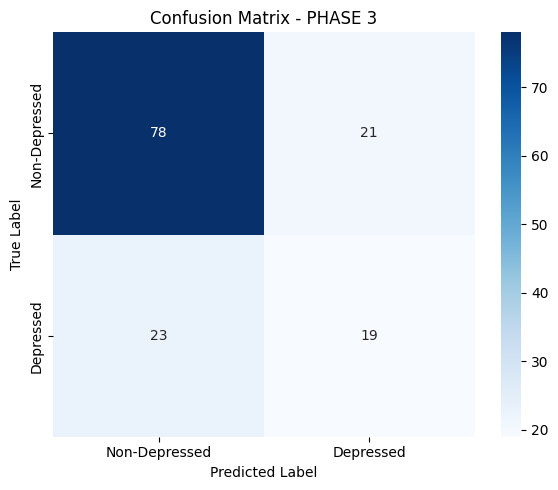


------------------------------------------------------------
FINAL ROC-AUC SCORES
------------------------------------------------------------
Phase 1 ROC-AUC: 0.8391
Phase 1 Precision: 0.6458
Phase 1 Recall: 0.7381
Phase 1 F1 Score: 0.6889

Phase 2 ROC-AUC: 0.7860
Phase 2 Precision: 0.5682
Phase 2 Recall: 0.5952
Phase 2 F1 Score: 0.5814

Phase 3 ROC-AUC: 0.6515
Phase 3 Precision: 0.4750
Phase 3 Recall: 0.4524
Phase 3 F1 Score: 0.4634


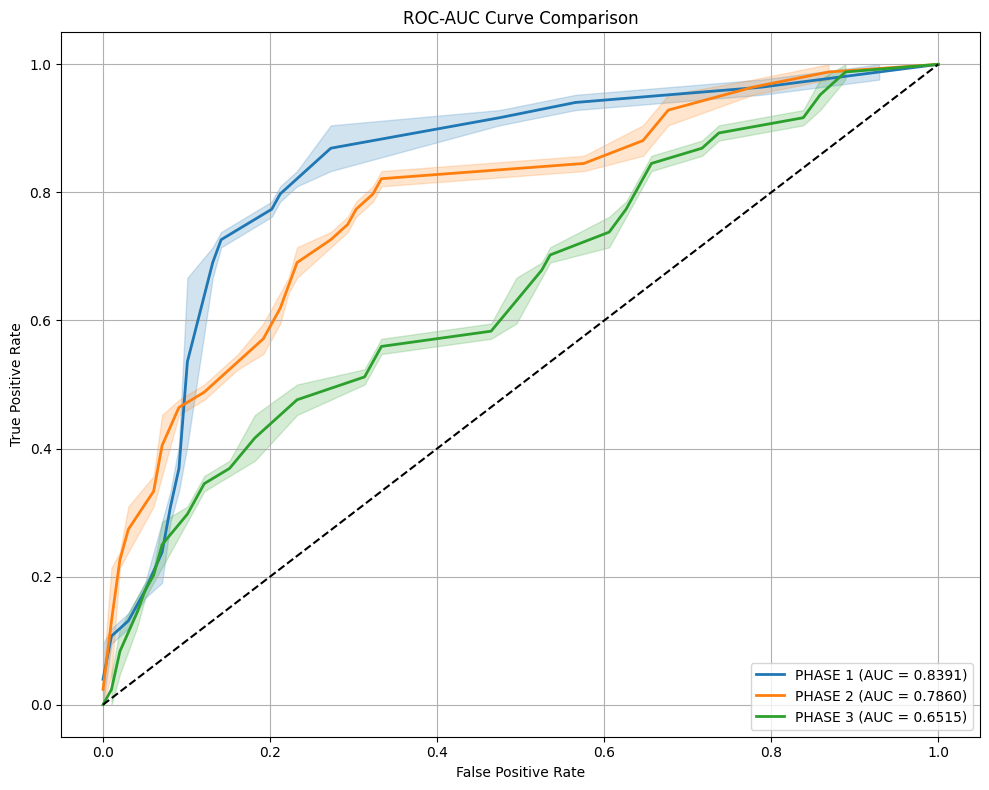

In [15]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler

from sklearn.feature_selection import (
    VarianceThreshold,
    SelectKBest,
    mutual_info_classif
)

from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_curve
)

from catboost import CatBoostClassifier

# load dataset
df = pd.read_csv("../../data/text_features_phasewise.csv")

print("-" * 60)
print("DATASET INFORMATION")
print("-" * 60)

print("Dataset Shape:", df.shape)

# normalize phase column
df["phase"] = df["phase"].astype(str).str.lower().str.strip()

print("\nAvailable Phases:")
print(df["phase"].unique())

# remove non-feature columns
remove_cols = [
    "participant_id",
    "phase",
    "label"
]

feature_cols = [
    col for col in df.columns
    if col not in remove_cols
]

print("\nTotal Features:", len(feature_cols))

# store roc curve data
roc_data = {}

# training function
def train_phase_model(df_phase, phase_name):

    print("\n" + "-" * 60)
    print(f"TRAINING FOR {phase_name}")
    print("-" * 60)

    # drop missing values
    df_phase = df_phase.dropna()

    # features & labels
    X = df_phase[feature_cols]
    y = df_phase["label"].values

    print("Original Shape:", X.shape)
    print("Class Distribution:", np.bincount(y))

    # remove low variance features
    variance_selector = VarianceThreshold(
        threshold=0.00001
    )

    X = variance_selector.fit_transform(X)

    print("\nShape After Variance Threshold:", X.shape)

    # select important features
    kbest_selector = SelectKBest(
        score_func=mutual_info_classif,
        k=min(180, X.shape[1])
    )

    X = kbest_selector.fit_transform(X, y)

    print("Shape After SelectKBest:", X.shape)

    # 10-fold stratified cv
    skf = StratifiedKFold(
        n_splits=10,
        shuffle=True,
        random_state=42
    )

    # store predictions
    all_probs = np.zeros(len(y))
    all_preds = np.zeros(len(y))

    fold_aucs = []

    # train each fold
    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):

        print(f"\n----- Fold {fold} -----")

        X_train, X_test = X[train_idx], X[test_idx]

        y_train, y_test = y[train_idx], y[test_idx]

        # feature scaling
        scaler = StandardScaler()

        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        # handle class imbalance
        neg = np.sum(y_train == 0)
        pos = np.sum(y_train == 1)

        class_weights = [
            1,
            neg / pos
        ]

        # stable catboost model
        model = CatBoostClassifier(

            # core
            loss_function="Logloss",
            eval_metric="AUC",

            # stable boosting
            iterations=400,

            # small depth
            depth=4,

            # moderate learning
            learning_rate=0.03,

            # stronger regularization
            l2_leaf_reg=8,

            # controlled randomness
            random_strength=1,

            # better generalization
            bootstrap_type="Bernoulli",
            subsample=0.8,

            # imbalance handling
            class_weights=class_weights,

            # stable growth
            grow_policy="SymmetricTree",

            random_seed=42,

            verbose=0
        )

        # train model
        model.fit(
            X_train,
            y_train
        )

        # predict probabilities
        y_prob = model.predict_proba(X_test)[:, 1]

        # threshold
        THRESHOLD = 0.35

        y_pred = (y_prob > THRESHOLD).astype(int)

        # store predictions
        all_probs[test_idx] = y_prob
        all_preds[test_idx] = y_pred

        # fold roc-auc
        fold_auc = roc_auc_score(y_test, y_prob)

        fold_aucs.append(fold_auc)

        print("Fold ROC-AUC:", round(fold_auc, 4))

    # overall roc-auc
    overall_auc = roc_auc_score(y, all_probs)

    print("\n" + "-" * 60)
    print(f"FINAL RESULTS FOR {phase_name}")
    print("-" * 60)

    print("\nFold ROC-AUC Scores:")
    print(np.round(fold_aucs, 4))

    print("\nMean Fold ROC-AUC:")
    print(round(np.mean(fold_aucs), 4))

    print("\nOverall ROC-AUC:")
    print(round(overall_auc, 4))

    # classification report
    print("\nClassification Report:")
    print(classification_report(
        y,
        all_preds,
        zero_division=0
    ))

    # precision
    precision = precision_score(
        y,
        all_preds,
        zero_division=0
    )

    print("Precision Score:", round(precision, 4))

    # recall
    recall = recall_score(
        y,
        all_preds,
        zero_division=0
    )

    print("Recall Score:", round(recall, 4))

    # f1 score
    f1 = f1_score(
        y,
        all_preds,
        zero_division=0
    )

    print("F1 Score:", round(f1, 4))

    # confusion matrix
    cm = confusion_matrix(y, all_preds)

    print("\nConfusion Matrix:")
    print(cm)

    # plot confusion matrix
    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Non-Depressed", "Depressed"],
        yticklabels=["Non-Depressed", "Depressed"]
    )

    plt.title(f"Confusion Matrix - {phase_name}")

    plt.xlabel("Predicted Label")

    plt.ylabel("True Label")

    plt.tight_layout()

    plt.show()

    # roc curve values
    fpr, tpr, _ = roc_curve(y, all_probs)

    roc_data[phase_name] = {
        "fpr": fpr,
        "tpr": tpr,
        "auc": overall_auc
    }

    return overall_auc, precision, recall, f1

# filter data phase-wise
df_p1 = df[df["phase"] == "phase1"]

df_p2 = df[df["phase"] == "phase2"]

df_p3 = df[df["phase"] == "phase3"]

# train models
roc_p1, prec_p1, rec_p1, f1_p1 = train_phase_model(
    df_p1,
    "PHASE 1"
)

roc_p2, prec_p2, rec_p2, f1_p2 = train_phase_model(
    df_p2,
    "PHASE 2"
)

roc_p3, prec_p3, rec_p3, f1_p3 = train_phase_model(
    df_p3,
    "PHASE 3"
)

# final summary
print("\n" + "-" * 60)
print("FINAL ROC-AUC SCORES")
print("-" * 60)

print(f"Phase 1 ROC-AUC: {roc_p1:.4f}")
print(f"Phase 1 Precision: {prec_p1:.4f}")
print(f"Phase 1 Recall: {rec_p1:.4f}")
print(f"Phase 1 F1 Score: {f1_p1:.4f}")

print()

print(f"Phase 2 ROC-AUC: {roc_p2:.4f}")
print(f"Phase 2 Precision: {prec_p2:.4f}")
print(f"Phase 2 Recall: {rec_p2:.4f}")
print(f"Phase 2 F1 Score: {f1_p2:.4f}")

print()

print(f"Phase 3 ROC-AUC: {roc_p3:.4f}")
print(f"Phase 3 Precision: {prec_p3:.4f}")
print(f"Phase 3 Recall: {rec_p3:.4f}")
print(f"Phase 3 F1 Score: {f1_p3:.4f}")

# combined roc curve
plt.figure(figsize=(10, 8))

for phase_name, values in roc_data.items():

    sns.lineplot(
        x=values["fpr"],
        y=values["tpr"],
        linewidth=2,
        label=f"{phase_name} (AUC = {values['auc']:.4f})"
    )

# random baseline
sns.lineplot(
    x=[0, 1],
    y=[0, 1],
    linestyle="--",
    color="black"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC-AUC Curve Comparison")

plt.legend(loc="lower right")

plt.grid(True)

plt.tight_layout()

plt.show()

FNN

------------------------------------------------------------
DEVICE INFO
------------------------------------------------------------
Using Device: cuda
GPU: NVIDIA GeForce RTX 3050 Laptop GPU

Dataset Shape: (423, 780)

Available Phases:
<StringArray>
['phase1', 'phase2', 'phase3']
Length: 3, dtype: str

Total Features: 777

------------------------------------------------------------
TRAINING FOR PHASE 1
------------------------------------------------------------
Original Shape: (141, 777)
Class Distribution: [99 42]

Shape After Variance Threshold: (141, 771)
Shape After SelectKBest: (141, 220)

----- Fold 1 -----
Fold [1] Epoch [1/70] Loss: 1.0294 AUC: 0.6000
Fold [1] Epoch [2/70] Loss: 1.0130 AUC: 0.6200
Fold [1] Epoch [3/70] Loss: 0.9314 AUC: 0.6200
Fold [1] Epoch [4/70] Loss: 1.0209 AUC: 0.5600
Fold [1] Epoch [5/70] Loss: 0.9642 AUC: 0.5400
Fold [1] Epoch [6/70] Loss: 0.9093 AUC: 0.5000
Fold [1] Epoch [7/70] Loss: 0.9319 AUC: 0.5400
Fold [1] Epoch [8/70] Loss: 0.8760 AUC: 0.500

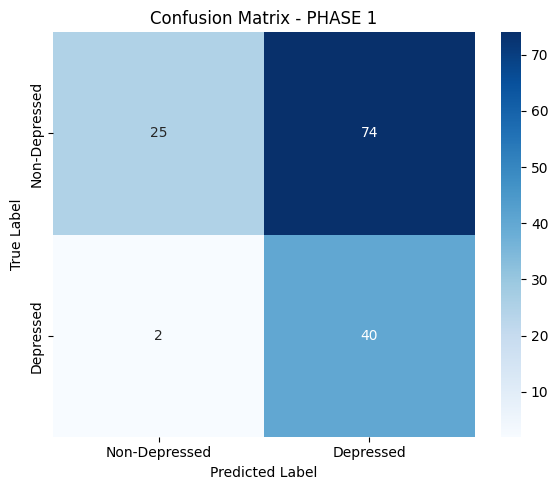


------------------------------------------------------------
TRAINING FOR PHASE 2
------------------------------------------------------------
Original Shape: (141, 777)
Class Distribution: [99 42]

Shape After Variance Threshold: (141, 770)
Shape After SelectKBest: (141, 220)

----- Fold 1 -----
Fold [1] Epoch [1/70] Loss: 0.9912 AUC: 0.5400
Fold [1] Epoch [2/70] Loss: 1.0209 AUC: 0.6000
Fold [1] Epoch [3/70] Loss: 0.9716 AUC: 0.5000
Fold [1] Epoch [4/70] Loss: 1.0332 AUC: 0.5400
Fold [1] Epoch [5/70] Loss: 0.9693 AUC: 0.5800
Fold [1] Epoch [6/70] Loss: 0.9267 AUC: 0.6000
Fold [1] Epoch [7/70] Loss: 0.9742 AUC: 0.6400
Fold [1] Epoch [8/70] Loss: 0.9146 AUC: 0.5800
Fold [1] Epoch [9/70] Loss: 0.9199 AUC: 0.6200
Fold [1] Epoch [10/70] Loss: 0.9014 AUC: 0.5600
Fold [1] Epoch [11/70] Loss: 0.9193 AUC: 0.5800
Fold [1] Epoch [12/70] Loss: 0.8884 AUC: 0.6000
Fold [1] Epoch [13/70] Loss: 0.8367 AUC: 0.6600
Fold [1] Epoch [14/70] Loss: 0.8042 AUC: 0.6200
Fold [1] Epoch [15/70] Loss: 0.8482 AU

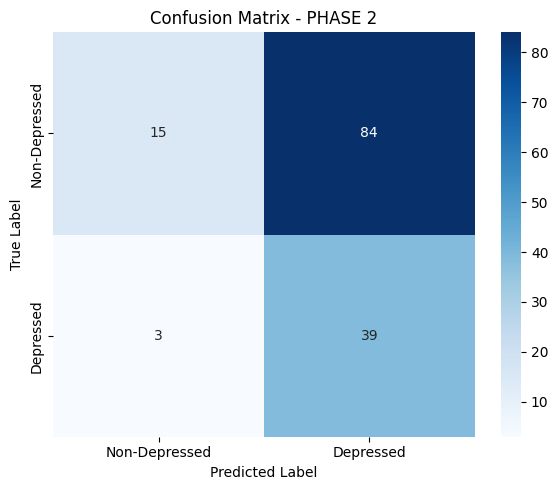


------------------------------------------------------------
TRAINING FOR PHASE 3
------------------------------------------------------------
Original Shape: (141, 777)
Class Distribution: [99 42]

Shape After Variance Threshold: (141, 771)
Shape After SelectKBest: (141, 220)

----- Fold 1 -----
Fold [1] Epoch [1/70] Loss: 1.0000 AUC: 0.5800
Fold [1] Epoch [2/70] Loss: 0.9790 AUC: 0.5800
Fold [1] Epoch [3/70] Loss: 1.0375 AUC: 0.5200
Fold [1] Epoch [4/70] Loss: 0.9669 AUC: 0.5600
Fold [1] Epoch [5/70] Loss: 0.9899 AUC: 0.6000
Fold [1] Epoch [6/70] Loss: 0.9881 AUC: 0.5800
Fold [1] Epoch [7/70] Loss: 0.9338 AUC: 0.6200
Fold [1] Epoch [8/70] Loss: 0.9744 AUC: 0.6000
Fold [1] Epoch [9/70] Loss: 0.9046 AUC: 0.6000
Fold [1] Epoch [10/70] Loss: 0.9429 AUC: 0.6000
Fold [1] Epoch [11/70] Loss: 0.8666 AUC: 0.5400
Fold [1] Epoch [12/70] Loss: 0.8586 AUC: 0.5600
Fold [1] Epoch [13/70] Loss: 0.7958 AUC: 0.5400
Fold [1] Epoch [14/70] Loss: 0.8008 AUC: 0.5800
Fold [1] Epoch [15/70] Loss: 0.8463 AU

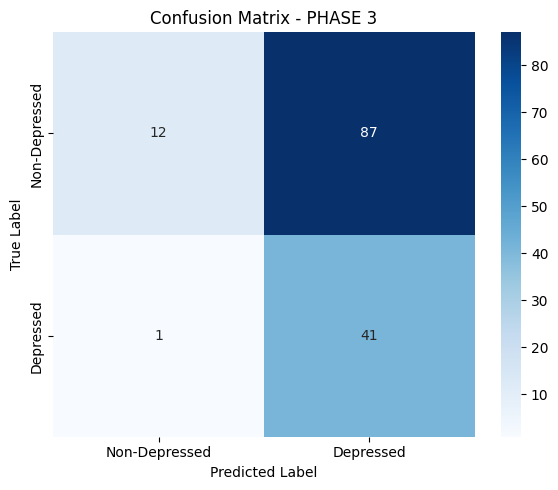


------------------------------------------------------------
FINAL ROC-AUC SCORES
------------------------------------------------------------
Phase 1 ROC-AUC: 0.8001
Phase 1 Precision: 0.3509
Phase 1 Recall: 0.9524
Phase 1 F1 Score: 0.5128

Phase 2 ROC-AUC: 0.7506
Phase 2 Precision: 0.3171
Phase 2 Recall: 0.9286
Phase 2 F1 Score: 0.4727

Phase 3 ROC-AUC: 0.7429
Phase 3 Precision: 0.3203
Phase 3 Recall: 0.9762
Phase 3 F1 Score: 0.4824


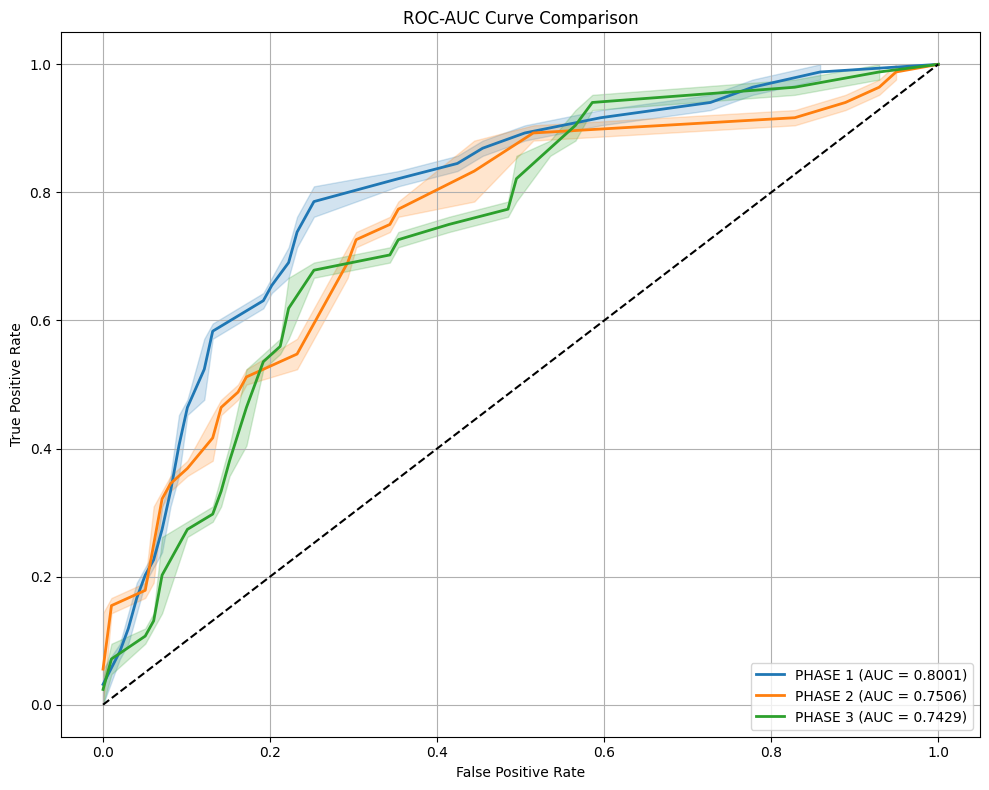

In [16]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn

import matplotlib.pyplot as plt
import seaborn as sns

from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler

from sklearn.feature_selection import (
    VarianceThreshold,
    SelectKBest,
    mutual_info_classif
)

from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_curve
)

# gpu setup

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("-" * 60)
print("DEVICE INFO")
print("-" * 60)

print("Using Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# load dataset

df = pd.read_csv("../../data/text_features_phasewise.csv")

df["phase"] = (
    df["phase"]
    .astype(str)
    .str.lower()
    .str.strip()
)

print("\nDataset Shape:", df.shape)

print("\nAvailable Phases:")
print(df["phase"].unique())

# remove non-feature columns

remove_cols = [
    "participant_id",
    "phase",
    "label"
]

feature_cols = [
    col for col in df.columns
    if col not in remove_cols
]

print("\nTotal Features:", len(feature_cols))

# store roc curve data

roc_data = {}

# custom dataset

class DepressionDataset(Dataset):

    def __init__(self, X, y):

        self.X = torch.tensor(
            X,
            dtype=torch.float32
        )

        self.y = torch.tensor(
            y,
            dtype=torch.float32
        )

    def __len__(self):

        return len(self.X)

    def __getitem__(self, idx):

        return self.X[idx], self.y[idx]

# deep neural network

class DepressionDNN(nn.Module):

    def __init__(self, input_dim):

        super(DepressionDNN, self).__init__()

        self.network = nn.Sequential(

            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.45),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.40),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.35),

            nn.Linear(64, 1)
        )

    def forward(self, x):

        return self.network(x).squeeze()

# training function

def train_phase_model(df_phase, phase_name):

    print("\n" + "-" * 60)
    print(f"TRAINING FOR {phase_name}")
    print("-" * 60)

    # remove missing values

    df_phase = df_phase.dropna()

    # features & labels

    X = df_phase[feature_cols]
    y = df_phase["label"].values

    print("Original Shape:", X.shape)

    print("Class Distribution:", np.bincount(y))

    # variance threshold

    variance_selector = VarianceThreshold(
        threshold=0.00001
    )

    X = variance_selector.fit_transform(X)

    print("\nShape After Variance Threshold:", X.shape)

    # select important features

    kbest_selector = SelectKBest(
        score_func=mutual_info_classif,
        k=min(220, X.shape[1])
    )

    X = kbest_selector.fit_transform(X, y)

    print("Shape After SelectKBest:", X.shape)

    # 10-fold stratified cross validation

    skf = StratifiedKFold(
        n_splits=10,
        shuffle=True,
        random_state=42
    )

    # store predictions

    all_probs = np.zeros(len(y))
    all_preds = np.zeros(len(y))

    fold_aucs = []

    # fold training

    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):

        print(f"\n----- Fold {fold} -----")

        X_train, X_test = X[train_idx], X[test_idx]

        y_train, y_test = y[train_idx], y[test_idx]

        # feature scaling

        scaler = StandardScaler()

        X_train = scaler.fit_transform(X_train)

        X_test = scaler.transform(X_test)

        # datasets

        train_dataset = DepressionDataset(
            X_train,
            y_train
        )

        test_dataset = DepressionDataset(
            X_test,
            y_test
        )

        # dataloaders

        train_loader = DataLoader(
            train_dataset,
            batch_size=8,
            shuffle=True
        )

        test_loader = DataLoader(
            test_dataset,
            batch_size=8,
            shuffle=False
        )

        # model

        model = DepressionDNN(
            input_dim=X_train.shape[1]
        ).to(device)

        # class weighting

        class_counts = np.bincount(y_train)

        pos_weight = torch.tensor(
            class_counts[0] / class_counts[1],
            dtype=torch.float32
        ).to(device)

        # loss function

        criterion = nn.BCEWithLogitsLoss(
            pos_weight=pos_weight
        )

        # optimizer

        optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=0.00015,
            weight_decay=1e-3
        )

        # scheduler

        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=70
        )

        # training

        EPOCHS = 70

        best_auc = 0

        best_fold_probs = None

        for epoch in range(EPOCHS):

            model.train()

            total_loss = 0

            for X_batch, y_batch in train_loader:

                X_batch = X_batch.to(device)

                y_batch = y_batch.to(device)

                optimizer.zero_grad()

                outputs = model(X_batch)

                loss = criterion(
                    outputs,
                    y_batch
                )

                loss.backward()

                torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    max_norm=1.0
                )

                optimizer.step()

                total_loss += loss.item()

            scheduler.step()

            # validation

            model.eval()

            val_probs = []

            with torch.no_grad():

                for X_batch, _ in test_loader:

                    X_batch = X_batch.to(device)

                    outputs = model(X_batch)

                    probs = torch.sigmoid(outputs)

                    probs = probs.cpu().numpy()

                    val_probs.extend(probs)

            val_auc = roc_auc_score(
                y_test,
                val_probs
            )

            if val_auc > best_auc:

                best_auc = val_auc

                best_fold_probs = np.array(val_probs)

            avg_loss = total_loss / len(train_loader)

            print(
                f"Fold [{fold}] "
                f"Epoch [{epoch+1}/{EPOCHS}] "
                f"Loss: {avg_loss:.4f} "
                f"AUC: {val_auc:.4f}"
            )

        # final predictions for fold

        THRESHOLD = 0.36

        y_pred = (
            best_fold_probs > THRESHOLD
        ).astype(int)

        # store predictions

        all_probs[test_idx] = best_fold_probs

        all_preds[test_idx] = y_pred

        # fold auc

        fold_auc = roc_auc_score(
            y_test,
            best_fold_probs
        )

        fold_aucs.append(fold_auc)

        print(
            f"Best Fold ROC-AUC: "
            f"{round(fold_auc, 4)}"
        )

    # overall metrics

    overall_auc = roc_auc_score(
        y,
        all_probs
    )

    print("\n" + "-" * 60)
    print(f"FINAL RESULTS FOR {phase_name}")
    print("-" * 60)

    print("\nFold ROC-AUC Scores:")

    print(np.round(fold_aucs, 4))

    print("\nMean Fold ROC-AUC:")

    print(round(np.mean(fold_aucs), 4))

    print("\nOverall ROC-AUC:")

    print(round(overall_auc, 4))

    # classification report

    print("\nClassification Report:")

    print(classification_report(
        y,
        all_preds,
        zero_division=0
    ))

    # precision

    precision = precision_score(
        y,
        all_preds,
        zero_division=0
    )

    print("Precision Score:", round(precision, 4))

    # recall

    recall = recall_score(
        y,
        all_preds,
        zero_division=0
    )

    print("Recall Score:", round(recall, 4))

    # f1 score

    f1 = f1_score(
        y,
        all_preds,
        zero_division=0
    )

    print("F1 Score:", round(f1, 4))

    # confusion matrix

    cm = confusion_matrix(
        y,
        all_preds
    )

    print("\nConfusion Matrix:")

    print(cm)

    # plot confusion matrix

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=[
            "Non-Depressed",
            "Depressed"
        ],
        yticklabels=[
            "Non-Depressed",
            "Depressed"
        ]
    )

    plt.title(
        f"Confusion Matrix - {phase_name}"
    )

    plt.xlabel("Predicted Label")

    plt.ylabel("True Label")

    plt.tight_layout()

    plt.show()

    # roc curve

    fpr, tpr, _ = roc_curve(
        y,
        all_probs
    )

    roc_data[phase_name] = {
        "fpr": fpr,
        "tpr": tpr,
        "auc": overall_auc
    }

    return (
        overall_auc,
        precision,
        recall,
        f1
    )

# phase-wise data

df_p1 = df[df["phase"] == "phase1"]

df_p2 = df[df["phase"] == "phase2"]

df_p3 = df[df["phase"] == "phase3"]

# train models

roc_p1, prec_p1, rec_p1, f1_p1 = train_phase_model(
    df_p1,
    "PHASE 1"
)

roc_p2, prec_p2, rec_p2, f1_p2 = train_phase_model(
    df_p2,
    "PHASE 2"
)

roc_p3, prec_p3, rec_p3, f1_p3 = train_phase_model(
    df_p3,
    "PHASE 3"
)

# final summary

print("\n" + "-" * 60)
print("FINAL ROC-AUC SCORES")
print("-" * 60)

print(f"Phase 1 ROC-AUC: {roc_p1:.4f}")
print(f"Phase 1 Precision: {prec_p1:.4f}")
print(f"Phase 1 Recall: {rec_p1:.4f}")
print(f"Phase 1 F1 Score: {f1_p1:.4f}")

print()

print(f"Phase 2 ROC-AUC: {roc_p2:.4f}")
print(f"Phase 2 Precision: {prec_p2:.4f}")
print(f"Phase 2 Recall: {rec_p2:.4f}")
print(f"Phase 2 F1 Score: {f1_p2:.4f}")

print()

print(f"Phase 3 ROC-AUC: {roc_p3:.4f}")
print(f"Phase 3 Precision: {prec_p3:.4f}")
print(f"Phase 3 Recall: {rec_p3:.4f}")
print(f"Phase 3 F1 Score: {f1_p3:.4f}")

# combined roc curve

plt.figure(figsize=(10, 8))

for phase_name, values in roc_data.items():

    sns.lineplot(
        x=values["fpr"],
        y=values["tpr"],
        linewidth=2,
        label=(
            f"{phase_name} "
            f"(AUC = {values['auc']:.4f})"
        )
    )

# random baseline

sns.lineplot(
    x=[0, 1],
    y=[0, 1],
    linestyle="--",
    color="black"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC-AUC Curve Comparison")

plt.legend(loc="lower right")

plt.grid(True)

plt.tight_layout()

plt.show()